In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': .25, 'axes.spines.top': False, 'axes.spines.right': False})

UP  = 'uploads/'
OUT = 'outputs/'


KLADR = {77: 'Москва', 50: 'Московская область', 78: 'Санкт-Петербург', 16: 'Республика Татарстан',
         66: 'Свердловская область', 54: 'Новосибирская область', 47: 'Ленинградская область',
         52: 'Нижегородская область', 23: 'Краснодарский край', 63: 'Самарская область',
         74: 'Челябинская область', 42: 'Кемеровская область', 72: 'Тюменская область',
         2: 'Республика Башкортостан', 24: 'Красноярский край', 55: 'Омская область'}

WIN_START, WIN_END = '2026-04-01', '2026-08-31'   # рабочее окно
CRISIS_MONTHS = [6, 7, 8]                          # период кризиса

In [12]:
clients = pd.read_csv(UP + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(UP + 'fines_2026.csv',              sep=';', decimal=',')
fuel    = pd.read_csv(UP + 'fuel_transaction.csv',        sep=';', decimal=',')

fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
fuel['order_datetime']     = pd.to_datetime(fuel.order_datetime)
clients['sub_date']        = pd.to_datetime(clients.subscription_creation_date)

print('Таблица 1 — клиенты/авто :', clients.shape)
print('Таблица 2 — штрафы 2026  :', fines.shape)
print('Таблица 3 — заправки     :', fuel.shape)

Таблица 1 — клиенты/авто : (28237, 21)
Таблица 2 — штрафы 2026  : (77978, 7)
Таблица 3 — заправки     : (379699, 5)


In [3]:
def profile(df, name):
    rows = []
    for c in df.columns:
        s = df[c]
        rows.append({'таблица': name, 'поле': c, 'тип': str(s.dtype),
                     'пропусков': int(s.isna().sum()),
                     '% пропусков': round(s.isna().mean() * 100, 2),
                     'уникальных': s.nunique()})
    return pd.DataFrame(rows)

prof = pd.concat([profile(clients, 'clients'), profile(fines, 'fines'), profile(fuel, 'fuel')])
display(prof[prof['пропусков'] > 0])
print('Полей без пропусков:', (prof['пропусков'] == 0).sum(), 'из', len(prof))

,таблица,поле,тип,пропусков,% пропусков,уникальных
1,clients,gender,object,29,0.15,2
2,clients,age_type_code,object,2,0.01,4
3,clients,auto_document_id,object,1,0.01,19326
4,clients,auto_mark,object,1,0.01,125
5,clients,auto_year,float64,1,0.01,45
6,clients,engine_type,object,3,0.02,1257
7,clients,price,float64,434,2.24,3817
8,clients,color,object,945,4.87,363
9,clients,kladr_code,float64,1,0.01,16
10,clients,april_2025_fines,float64,1,0.01,30


Полей без пропусков: 5 из 33


**Вывод по пропускам.** Пропуски есть только в таблице 1 и только в описательных признаках автомобиля:
цвет, цена .
В ключевых для исследования полях (даты, объёмы, цены топлива, суммы и даты штрафов) пропусков нет — значит,
строки **удалять не нужно**: `price` и `color` войдут в модель как контрольные переменные с отдельной категорией «не указано».

In [4]:
num = clients[['auto_year', 'price', 'april_2025_fines', 'may_2025_fines', 'jun_2025_fines',
               'jul_2025_fines', 'aug_2025_fines', 'fines_last_12_month', 'fines_last_36_month']]
display(num.describe().T.round(1))

cat = pd.concat([clients.gender.value_counts(dropna=False).rename('n').to_frame().assign(поле='gender'),
                 clients.age_type_code.value_counts(dropna=False).rename('n').to_frame().assign(поле='age_type_code')])
display(cat)

,count,mean,std,min,25%,50%,75%,max
auto_year,19397.0,2015.6,6.3,1982.0,2011.0,2016.0,2021.0,2026.0
price,18964.0,2156474.8,1405930.8,300000.0,1169192.0,1886667.0,2760625.0,25242000.0
april_2025_fines,19397.0,0.7,1.9,0.0,0.0,0.0,1.0,84.0
may_2025_fines,19397.0,1.0,2.4,0.0,0.0,0.0,1.0,77.0
jun_2025_fines,19397.0,1.0,2.2,0.0,0.0,0.0,1.0,50.0
jul_2025_fines,19397.0,1.0,2.7,0.0,0.0,0.0,1.0,161.0
aug_2025_fines,19397.0,0.9,2.0,0.0,0.0,0.0,1.0,42.0
fines_last_12_month,19397.0,14.0,24.0,0.0,3.0,7.0,15.0,791.0
fines_last_36_month,19397.0,20.4,33.7,0.0,4.0,10.0,23.0,994.0


,n,поле
M,15940,gender
F,3429,gender
NaN,29,gender
A20,11261,age_type_code
A40,7585,age_type_code
A60,487,age_type_code
A00,63,age_type_code
NaN,2,age_type_code


,count,mean,std,min,25%,50%,75%,max
auto_year,19397.0,2015.6,6.3,1982.0,2011.0,2016.0,2021.0,2026.0
price,18964.0,2156474.8,1405930.8,300000.0,1169192.0,1886667.0,2760625.0,25242000.0
april_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,8.0
may_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,4.0
jun_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,10.0
jul_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,5.0
aug_2026_fines,19398.0,0.0,0.2,0.0,0.0,0.0,0.0,4.0
fines_last_12_month,19397.0,14.0,24.0,0.0,3.0,7.0,15.0,791.0
fines_last_36_month,19397.0,20.4,33.7,0.0,4.0,10.0,23.0,994.0


,n,поле
M,15940,gender
F,3429,gender
NaN,29,gender
A20,11261,age_type_code
A40,7585,age_type_code
A60,487,age_type_code
A00,63,age_type_code
NaN,2,age_type_code


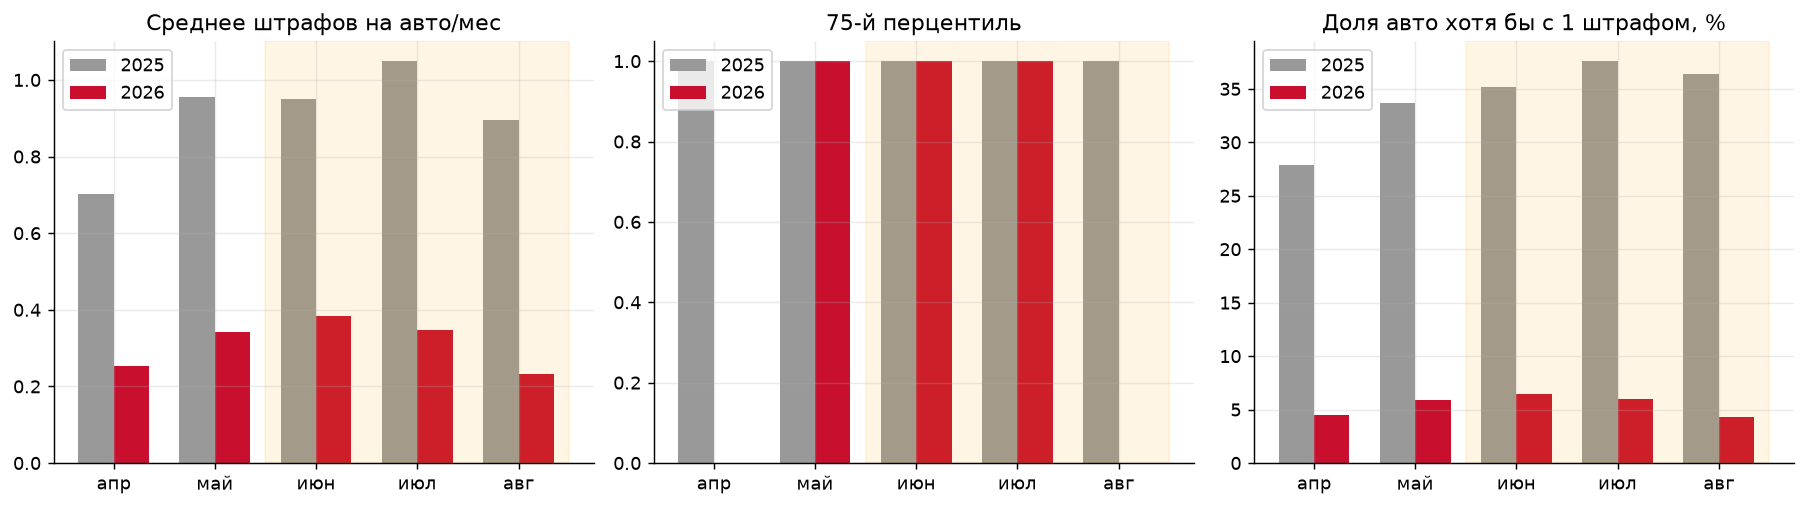

In [7]:
# --- помесячные штрафы 2026 на уровне авто (аналог april_2025_fines ... aug_2025_fines)
mm = {4: 'april', 5: 'may', 6: 'jun', 7: 'jul', 8: 'aug'}
cols26 = [f'{v}_2026_fines' for v in mm.values()]

m26 = (fines[fines.bill_offence_date.dt.month.between(4, 8)]
       .assign(month=lambda d: d.bill_offence_date.dt.month.map(mm))
       .pivot_table(index='auto_document_id', columns='month', values='bill_id', aggfunc='size', fill_value=0)
       .reindex(columns=list(mm.values()), fill_value=0))
m26.columns = cols26

clients2 = clients.set_index('auto_document_id').join(m26).reset_index()
clients2[cols26] = clients2[cols26].fillna(0)

# --- таблица 1: числовые признаки 2026 (тот же формат, что и для 2025)
num26 = clients2[['auto_year', 'price'] + cols26 + ['fines_last_12_month', 'fines_last_36_month']]
display(num26.describe().T.round(1))

# --- таблица 2: категориальные (тот же клиентский состав, что и в 2025)
cat26 = pd.concat([
    clients2.gender.value_counts(dropna=False).rename('n').to_frame().assign(поле='gender'),
    clients2.age_type_code.value_counts(dropna=False).rename('n').to_frame().assign(поле='age_type_code')])
display(cat26)

# --- сравнение 2025 vs 2026
import numpy as np, matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})

cols25 = [f'{v}_2025_fines' for v in mm.values()]
c = clients.set_index('auto_document_id')[cols25].join(m26)
mn = ['апр', 'май', 'июн', 'июл', 'авг']

mean25, mean26 = c[cols25].mean().values, c[cols26].mean().values
p75_25, p75_26 = c[cols25].quantile(.75).values, c[cols26].quantile(.75).values
share25, share26 = (c[cols25] > 0).mean().values * 100, (c[cols26] > 0).mean().values * 100

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
x = np.arange(5); w = .35
for a, v25, v26, title in [(ax[0], mean25, mean26, 'Среднее штрафов на авто/мес'),
                           (ax[1], p75_25, p75_26, '75-й перцентиль'),
                           (ax[2], share25, share26, 'Доля авто хотя бы с 1 штрафом, %')]:
    a.bar(x - w/2, v25, w, label='2025', color='#999')
    a.bar(x + w/2, v26, w, label='2026', color='#C8102E')
    a.set_xticks(x); a.set_xticklabels(mn); a.set_title(title); a.legend()
    a.axvspan(1.5, 4.5, color='orange', alpha=.1)
plt.tight_layout(); plt.show()

=== Числовые признаки 2026 ===


,count,mean,std,min,25%,50%,75%,max
auto_year,19397.0,2015.6,6.3,1982.0,2011.0,2016.0,2021.0,2026.0
price,18964.0,2156474.8,1405930.8,300000.0,1169192.0,1886667.0,2760625.0,25242000.0
april_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,8.0
may_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,4.0
jun_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,10.0
jul_2026_fines,19398.0,0.1,0.3,0.0,0.0,0.0,0.0,5.0
aug_2026_fines,19398.0,0.0,0.2,0.0,0.0,0.0,0.0,4.0
fines_last_12_month,19397.0,14.0,24.0,0.0,3.0,7.0,15.0,791.0
fines_last_36_month,19397.0,20.4,33.7,0.0,4.0,10.0,23.0,994.0



=== Категориальные признаки ===


,n,поле
M,15940,gender
F,3429,gender
NaN,29,gender
A20,11261,age_type_code
A40,7585,age_type_code
A60,487,age_type_code
A00,63,age_type_code
NaN,2,age_type_code


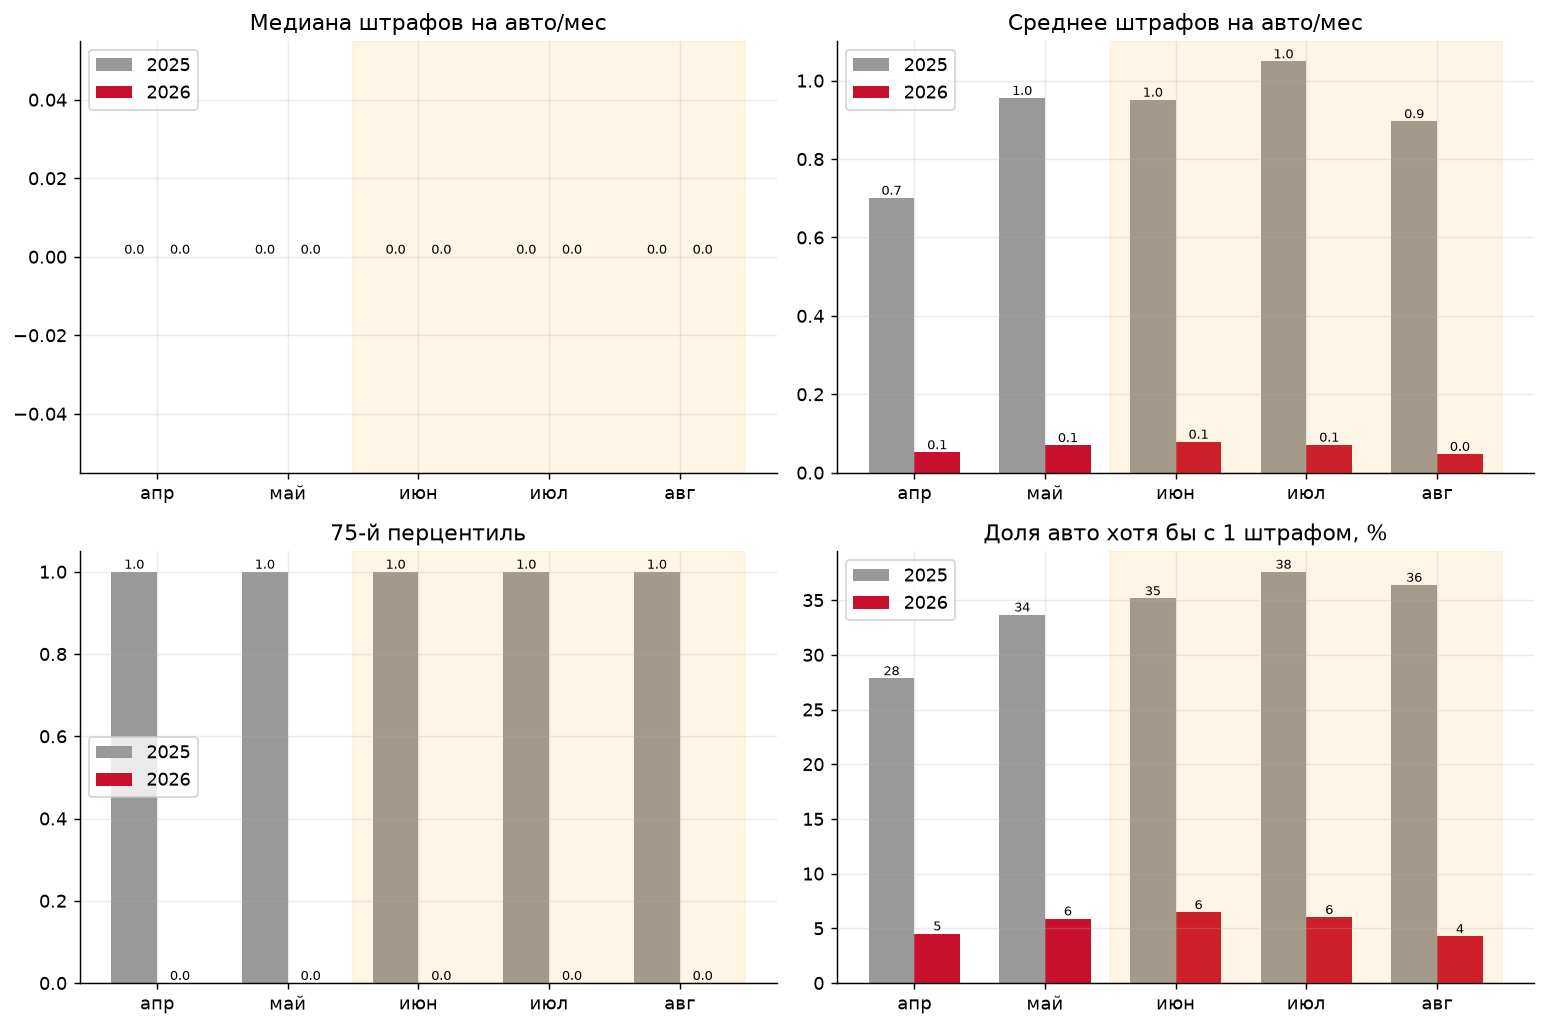

Медиана 2025: {'апр': np.float64(0.0), 'май': np.float64(0.0), 'июн': np.float64(0.0), 'июл': np.float64(0.0), 'авг': np.float64(0.0)}
Медиана 2026: {'апр': np.float64(0.0), 'май': np.float64(0.0), 'июн': np.float64(0.0), 'июл': np.float64(0.0), 'авг': np.float64(0.0)}


In [11]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})

# ---------- 1. Штрафы 2026 по каждой машине, помесячно (та же логика, что и april_2025_fines...) ----------
mm = {4: 'april', 5: 'may', 6: 'jun', 7: 'jul', 8: 'aug'}
cols26 = [f'{v}_2026_fines' for v in mm.values()]
cols25 = [f'{v}_2025_fines' for v in mm.values()]

m26 = (fines[fines.bill_offence_date.dt.month.between(4, 8)]
       .assign(month=lambda d: d.bill_offence_date.dt.month.map(mm))
       .pivot_table(index='auto_document_id', columns='month',
                    values='bill_id', aggfunc='size', fill_value=0)
       .reindex(columns=list(mm.values()), fill_value=0))
m26.columns = cols26
m26 = m26.reset_index()

clients2 = clients.merge(m26, on='auto_document_id', how='left')
clients2[cols26] = clients2[cols26].fillna(0)

# ---------- 2. Таблица числовых признаков 2026 (аналог таблицы по 2025) ----------
num26 = clients2[['auto_year', 'price'] + cols26 + ['fines_last_12_month', 'fines_last_36_month']]
print('=== Числовые признаки 2026 ===')
display(num26.describe().T.round(1))

# ---------- 3. Категориальные признаки ----------
cat26 = pd.concat([
    clients2.gender.value_counts(dropna=False).rename('n').to_frame().assign(поле='gender'),
    clients2.age_type_code.value_counts(dropna=False).rename('n').to_frame().assign(поле='age_type_code')])
print('\n=== Категориальные признаки ===')
display(cat26)

# ---------- 4. Сравнение 2025 vs 2026 ----------
c = clients2.set_index('auto_document_id')[cols25 + cols26]
mn = ['апр', 'май', 'июн', 'июл', 'авг']

median25, median26 = c[cols25].median().values, c[cols26].median().values
mean25,   mean26   = c[cols25].mean().values,   c[cols26].mean().values
p75_25,   p75_26   = c[cols25].quantile(.75).values, c[cols26].quantile(.75).values
share25,  share26  = (c[cols25] > 0).mean().values * 100, (c[cols26] > 0).mean().values * 100

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
x = np.arange(5); w = .35
panels = [(ax[0, 0], median25, median26, 'Медиана штрафов на авто/мес'),
          (ax[0, 1], mean25,   mean26,   'Среднее штрафов на авто/мес'),
          (ax[1, 0], p75_25,   p75_26,   '75-й перцентиль'),
          (ax[1, 1], share25,  share26,  'Доля авто хотя бы с 1 штрафом, %')]
for a, v25, v26, title in panels:
    a.bar(x - w/2, v25, w, label='2025', color='#999')
    a.bar(x + w/2, v26, w, label='2026', color='#C8102E')
    a.set_xticks(x); a.set_xticklabels(mn); a.set_title(title); a.legend()
    a.axvspan(1.5, 4.5, color='orange', alpha=.1)
    for i, (vv25, vv26) in enumerate(zip(v25, v26)):
        a.annotate(f'{vv25:.1f}' if title != 'Доля авто хотя бы с 1 штрафом, %' else f'{vv25:.0f}',
                   (i - w/2, vv25), ha='center', va='bottom', fontsize=7)
        a.annotate(f'{vv26:.1f}' if title != 'Доля авто хотя бы с 1 штрафом, %' else f'{vv26:.0f}',
                   (i + w/2, vv26), ha='center', va='bottom', fontsize=7)

plt.tight_layout(); plt.show()

print('Медиана 2025:', dict(zip(mn, median25)))
print('Медиана 2026:', dict(zip(mn, median26)))

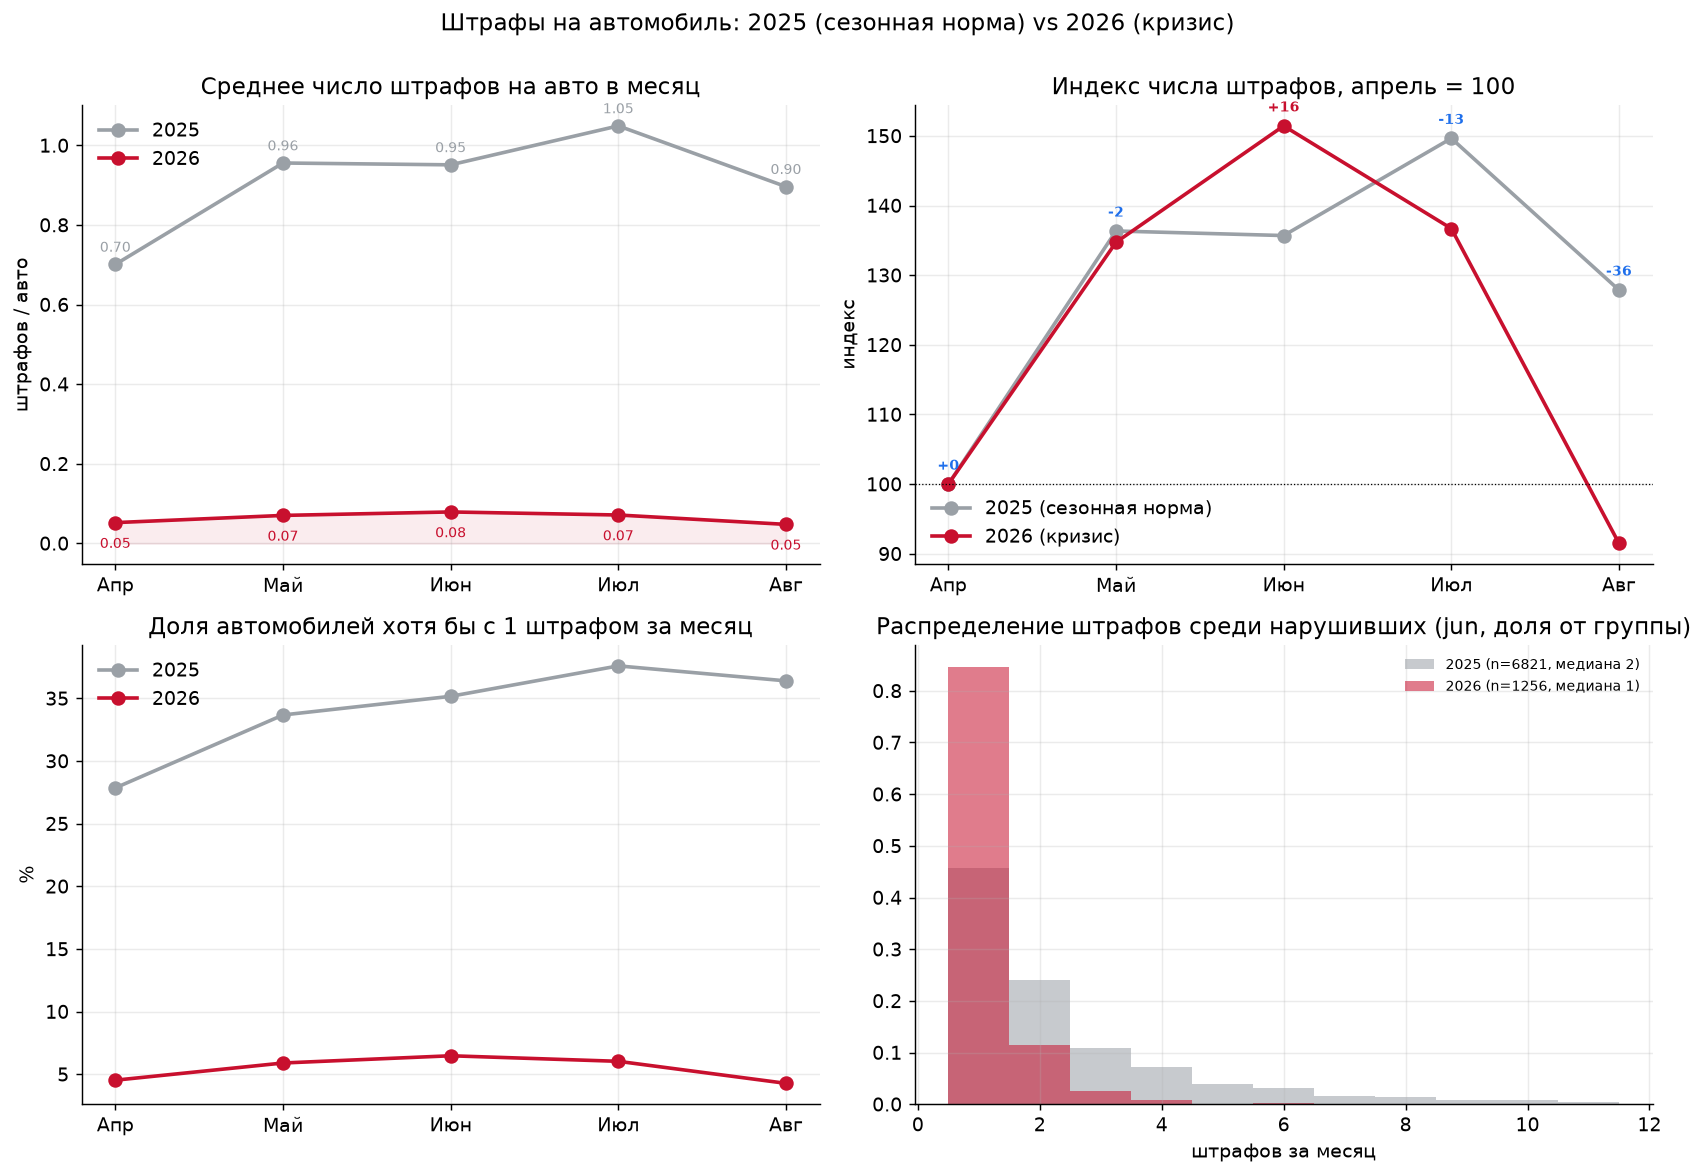

Индекс 2025 (апр=100): {'Апр': np.float64(100.0), 'Май': np.float64(136.3), 'Июн': np.float64(135.7), 'Июл': np.float64(149.6), 'Авг': np.float64(127.9)}
Индекс 2026 (апр=100): {'Апр': np.float64(100.0), 'Май': np.float64(134.7), 'Июн': np.float64(151.4), 'Июл': np.float64(136.7), 'Авг': np.float64(91.5)}
Отклонение 2026 от сезонной нормы 2025, п.п.: {'Апр': np.float64(0.0), 'Май': np.float64(-1.6), 'Июн': np.float64(15.7), 'Июл': np.float64(-13.0), 'Авг': np.float64(-36.4)}


период                                              до кризиса (апр-май)  кризис (июн-авг)  разница_пп
offence_short_statement                                                                               
Превышение скорости на 20-40 км/ч                                  80.41             80.06       -0.35
Не пристегнут ремень безопасности                                   5.14              5.07       -0.06
Нарушение разметки                                                  3.84              3.40       -0.44
Превышение скорости на 40-60 км/ч                                   2.12              1.96       -0.16
Использование телефона за рулем                                     1.41              1.74        0.33
Движение по выделенной полосе                                       0.88              1.41        0.53
Пересечение стоп-линии                                              0.85              1.09        0.24
Проезд на красный сигнал светофора                                  1.30 

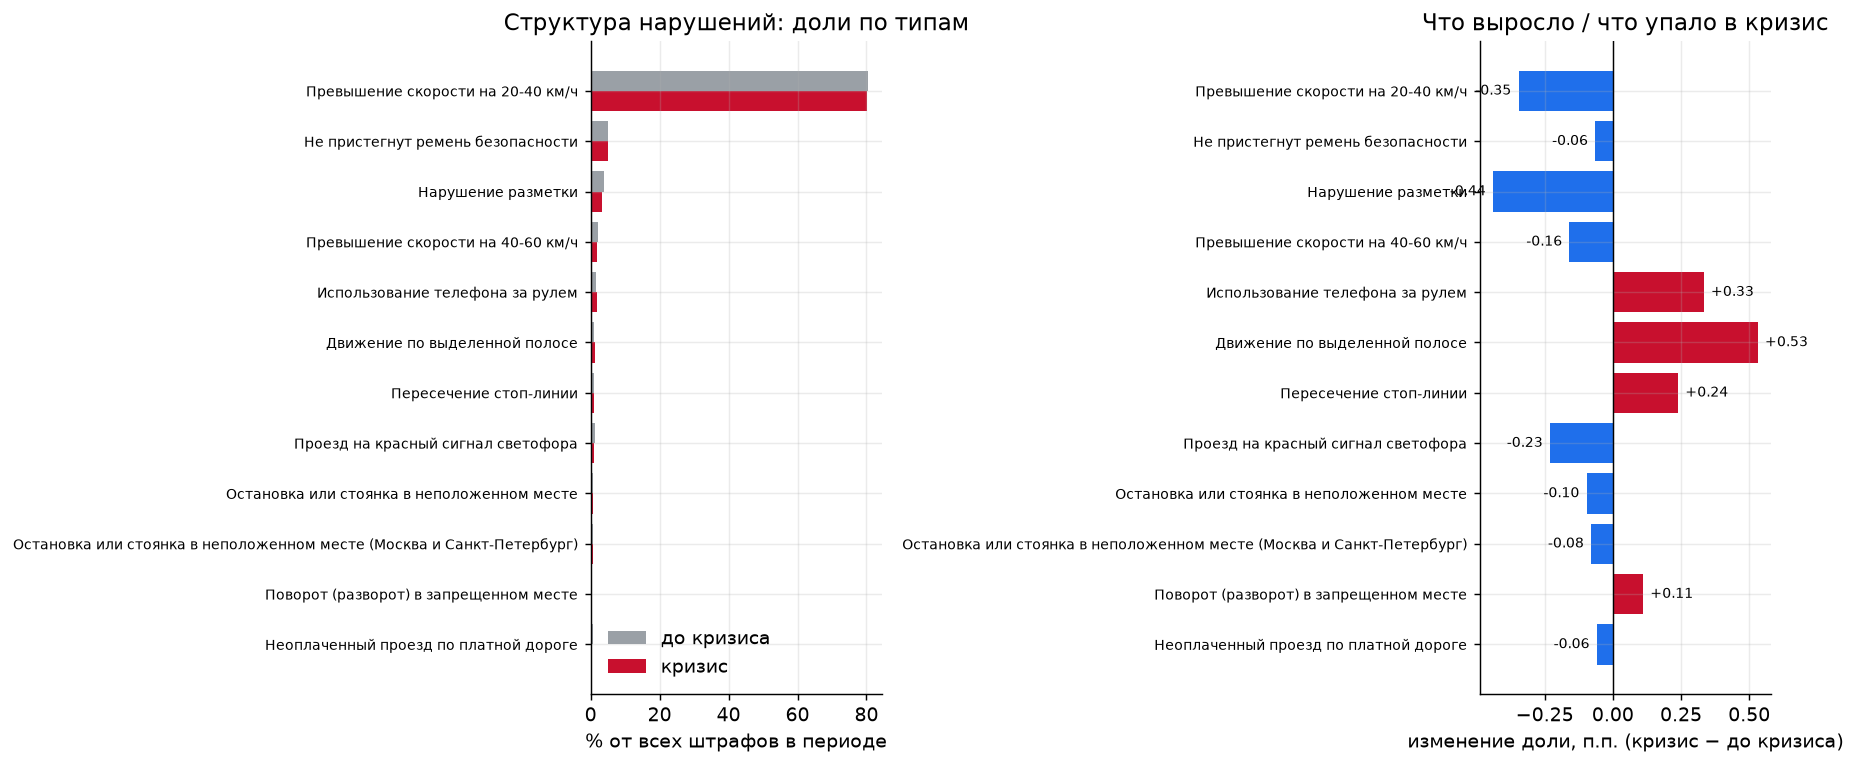


Хи-квадрат на структуру нарушений: chi2=37.0, p=1.68e-02


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

f = fines[fines.bill_offence_date.dt.month.between(4, 8)].copy()
f['период'] = np.where(f.bill_offence_date.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-авг)')

# доли каждого типа нарушения внутри периода, %
ct = pd.crosstab(f.offence_short_statement, f.период, normalize='columns') * 100
ct['разница_пп'] = ct['кризис (июн-авг)'] - ct['до кризиса (апр-май)']
ct = ct.sort_values('кризис (июн-авг)', ascending=False).head(12)

print(ct.round(2))

# --- график 1: доли до/после (горизонтальные бары)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
y = np.arange(len(ct))
ax[0].barh(y - .2, ct['до кризиса (апр-май)'], height=.4, color=GREY, label='до кризиса')
ax[0].barh(y + .2, ct['кризис (июн-авг)'], height=.4, color=RED, label='кризис')
ax[0].set_yticks(y); ax[0].set_yticklabels(ct.index, fontsize=8)
ax[0].invert_yaxis()
ax[0].set_xlabel('% от всех штрафов в периоде'); ax[0].set_title('Структура нарушений: доли по типам')
ax[0].legend(frameon=False)

# --- график 2: разница в п.п. (что выросло / что упало)
colors = [RED if v > 0 else BLUE for v in ct['разница_пп']]
ax[1].barh(y, ct['разница_пп'], color=colors)
ax[1].set_yticks(y); ax[1].set_yticklabels(ct.index, fontsize=8)
ax[1].invert_yaxis()
ax[1].axvline(0, color='k', lw=.8)
ax[1].set_xlabel('изменение доли, п.п. (кризис − до кризиса)')
ax[1].set_title('Что выросло / что упало в кризис')
for i, v in enumerate(ct['разница_пп']):
    ax[1].annotate(f'{v:+.2f}', (v, i), xytext=(4 if v > 0 else -4, 0), textcoords='offset points',
                   va='center', ha='left' if v > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

from scipy import stats
chi2, pv, _, _ = stats.chi2_contingency(pd.crosstab(f.offence_short_statement, f.период))
print(f'\nХи-квадрат на структуру нарушений: chi2={chi2:.1f}, p={pv:.2e}')

Доля штрафов, полученных в домашнем регионе: 67.3%
Регионов нарушения всего: 77 | регионов регистрации: 16


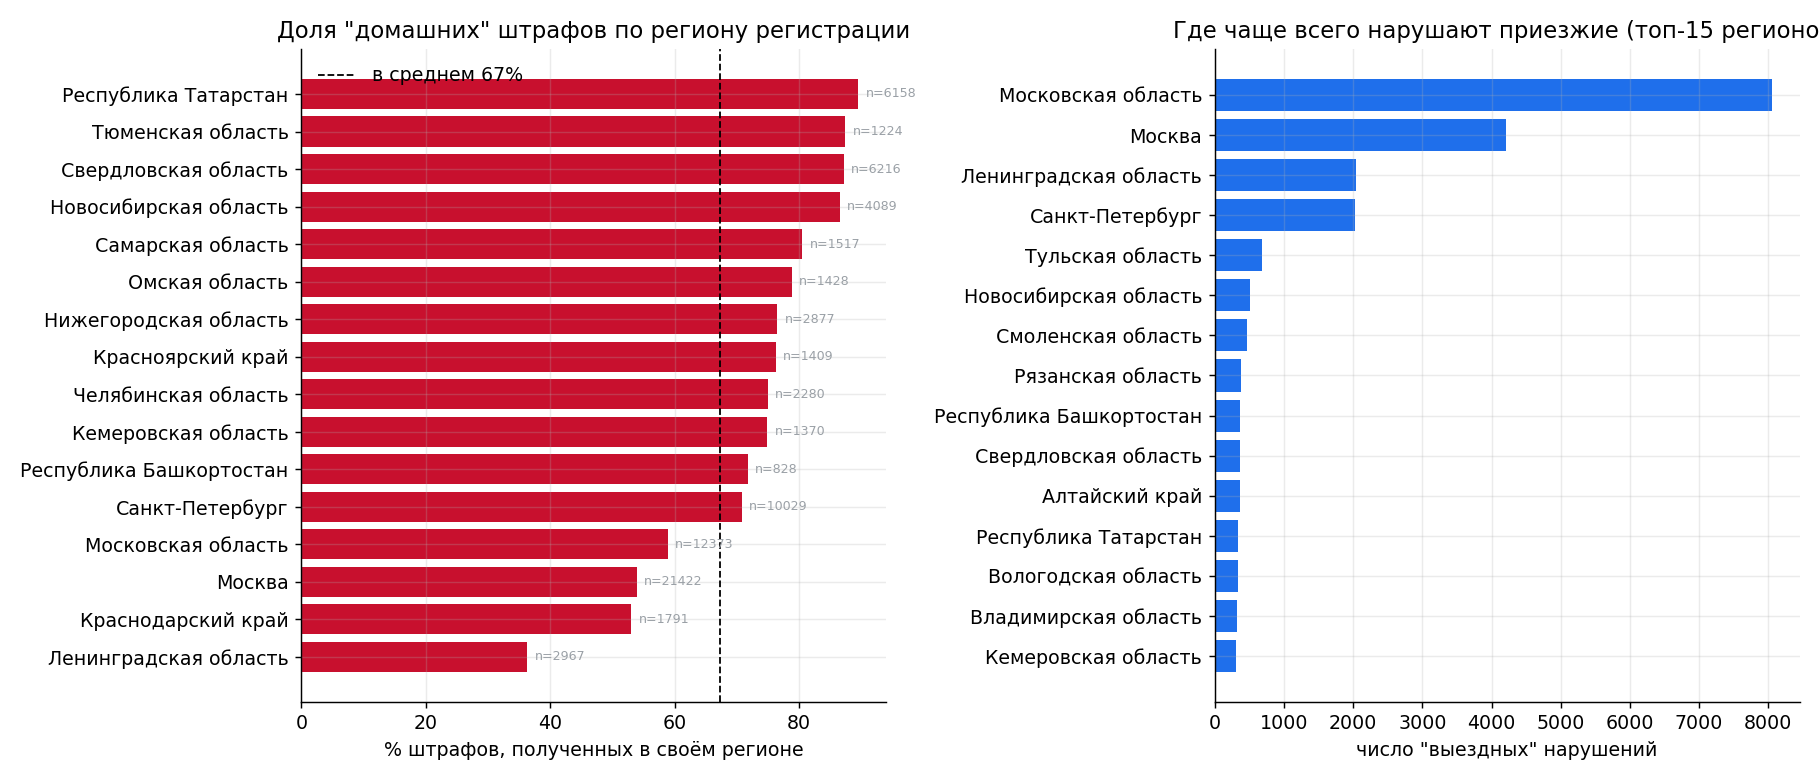


--- Матрица: домашний регион (строки) × регион нарушения (столбцы) ---


region_name            Ленинградская область  Москва  Московская область  Нижегородская область  Новосибирская область  Республика Татарстан  Санкт-Петербург  Свердловская область  прочие
домашний_регион                                                                                                                                                                            
Москва                                    32   11545                7429                     86                     14                    65              100                    12    2139
Московская область                        21    3660                7291                     49                      4                    29               42                     6    1271
Нижегородская область                     11      50                 113                   2200                      1                    23               38                     4     437
Новосибирская область                      8      16        

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

KLADR = {77: 'Москва', 50: 'Московская область', 78: 'Санкт-Петербург', 16: 'Республика Татарстан',
         66: 'Свердловская область', 54: 'Новосибирская область', 47: 'Ленинградская область',
         52: 'Нижегородская область', 23: 'Краснодарский край', 63: 'Самарская область',
         74: 'Челябинская область', 42: 'Кемеровская область', 72: 'Тюменская область',
         2: 'Республика Башкортостан', 24: 'Красноярский край', 55: 'Омская область'}

# домашний регион — по client_id (в таблице 1 регион одинаков для всех авто клиента)
home = clients.drop_duplicates('client_id')[['client_id', 'kladr_code']].copy()
home['домашний_регион'] = home.kladr_code.map(KLADR)

f = fines.merge(home[['client_id', 'домашний_регион']], on='client_id', how='left')
f['совпадает'] = f.домашний_регион == f.region_name

print('Доля штрафов, полученных в домашнем регионе:', f'{f.совпадает.mean():.1%}')
print('Регионов нарушения всего:', f.region_name.nunique(), '| регионов регистрации:', home.домашний_регион.nunique())

# --- 1. по каждому домашнему региону: доля "своих" vs "выездных" штрафов
by_home = f.groupby('домашний_регион').совпадает.agg(доля_своих=lambda s: s.mean()*100, n='size').sort_values('доля_своих')

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].barh(by_home.index, by_home.доля_своих, color=RED)
ax[0].set_xlabel('% штрафов, полученных в своём регионе'); ax[0].set_title('Доля "домашних" штрафов по региону регистрации')
ax[0].axvline(f.совпадает.mean()*100, color='k', ls='--', lw=1, label=f'в среднем {f.совпадает.mean()*100:.0f}%')
ax[0].legend(frameon=False)
for i, (v, n) in enumerate(zip(by_home.доля_своих, by_home.n)):
    ax[0].annotate(f'n={n}', (v, i), xytext=(4, 0), textcoords='offset points', va='center', fontsize=7, color=GREY)

# --- 2. топ регионов, куда чаще всего "утекают" нарушения из других регионов
away = f[~f.совпадает].region_name.value_counts().head(15)
ax[1].barh(away.index[::-1], away.values[::-1], color=BLUE)
ax[1].set_xlabel('число "выездных" нарушений'); ax[1].set_title('Где чаще всего нарушают приезжие (топ-15 регионов)')

plt.tight_layout()
plt.show()

# --- 3. матрица переток топ-8 x топ-8 (кто откуда куда)
top_home = home.домашний_регион.value_counts().head(8).index
top_away = f.region_name.value_counts().head(8).index
mat = pd.crosstab(f[f.домашний_регион.isin(top_home)].домашний_регион,
                  f[f.домашний_регион.isin(top_home)].region_name.where(
                      f.region_name.isin(top_away), 'прочие'))
print('\n--- Матрица: домашний регион (строки) × регион нарушения (столбцы) ---')
display(mat)

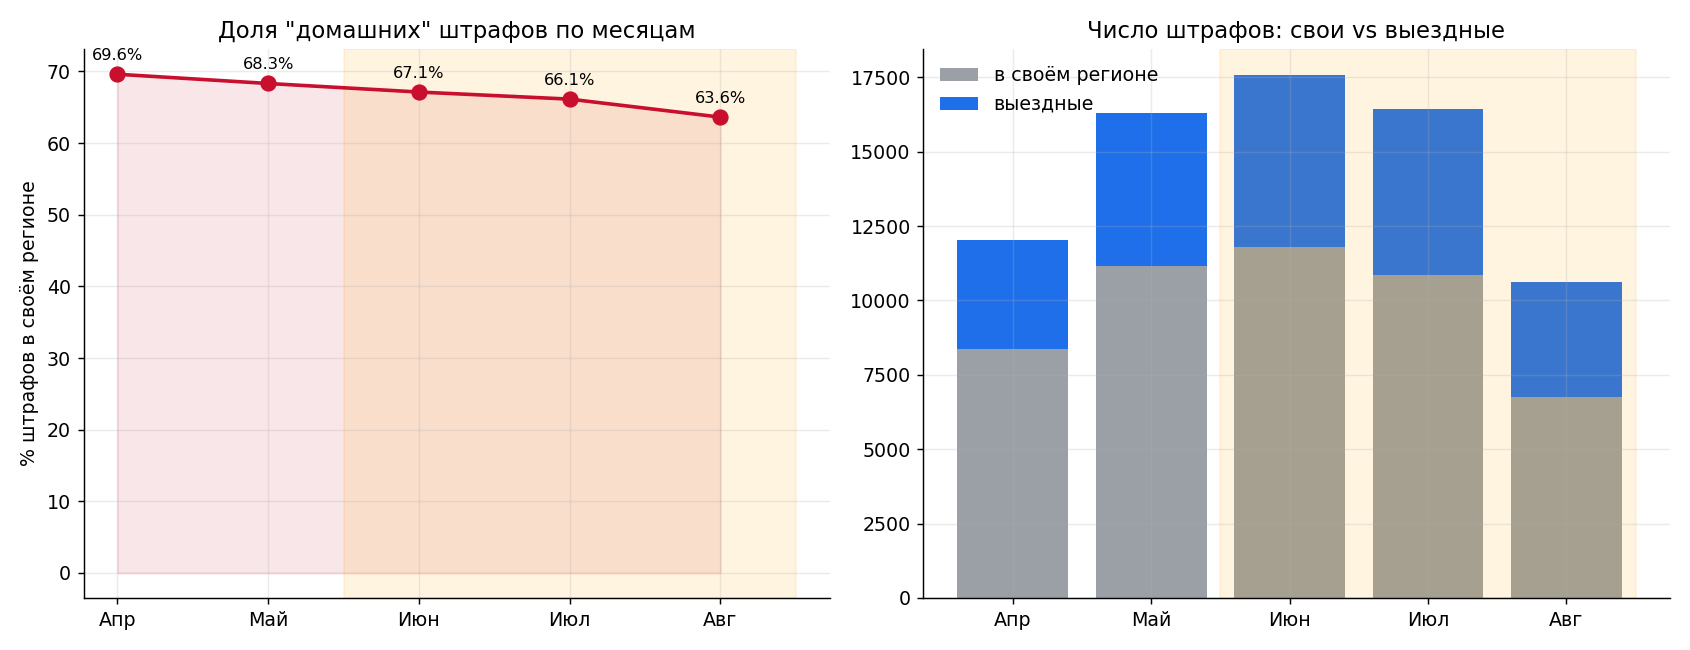

       доля_дома      n
месяц                  
4           69.6  12022
5           68.3  16317
6           67.1  17565
7           66.1  16420
8           63.6  10635

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

KLADR = {77: 'Москва', 50: 'Московская область', 78: 'Санкт-Петербург', 16: 'Республика Татарстан',
         66: 'Свердловская область', 54: 'Новосибирская область', 47: 'Ленинградская область',
         52: 'Нижегородская область', 23: 'Краснодарский край', 63: 'Самарская область',
         74: 'Челябинская область', 42: 'Кемеровская область', 72: 'Тюменская область',
         2: 'Республика Башкортостан', 24: 'Красноярский край', 55: 'Омская область'}

home = clients.drop_duplicates('client_id')[['client_id', 'kladr_code']].copy()
home['домашний_регион'] = home.kladr_code.map(KLADR)

f = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(
        home[['client_id', 'домашний_регион']], on='client_id', how='left')
f['совпадает'] = f.домашний_регион == f.region_name
f['месяц'] = f.bill_offence_date.dt.month

mn = ['Апр', 'Май', 'Июн', 'Июл', 'Авг']
by_m = f.groupby('месяц').совпадает.agg(доля_дома=lambda s: s.mean()*100, n='size')

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 1. доля "домашних" штрафов по месяцам
a = ax[0]
a.plot(mn, by_m.доля_дома, marker='o', ms=8, lw=2, color=RED)
a.fill_between(mn, by_m.доля_дома, alpha=.1, color=RED)
a.axvspan(1.5, 4.5, color='orange', alpha=.12)
a.set_ylabel('% штрафов в своём регионе'); a.set_title('Доля "домашних" штрафов по месяцам')
for i, v in enumerate(by_m.доля_дома):
    a.annotate(f'{v:.1f}%', (i, v), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9)

# 2. абсолютные числа: дома vs выезд, по месяцам
piv = f.groupby(['месяц', 'совпадает']).size().unstack()
piv.columns = ['выезд', 'дома']
a = ax[1]
a.bar(mn, piv['дома'], color=GREY, label='в своём регионе')
a.bar(mn, piv['выезд'], bottom=piv['дома'], color=BLUE, label='выездные')
a.axvspan(1.5, 4.5, color='orange', alpha=.12)
a.set_title('Число штрафов: свои vs выездные'); a.legend(frameon=False)

plt.tight_layout()
plt.show()

print(by_m.round(1))

# 3. то же самое, но отдельно по силе регионального шока (если считали high_shock_region ранее)
# раскомментируй, если в clients/panel есть этот признак:
# f2 = f.merge(reg_shock_df, left_on='домашний_регион', right_index=True)  
# print(f2.groupby(['месяц','high_shock_region']).совпадает.mean().unstack()*100)

=== Описательная статистика (сырые данные) ===
count    30912.00
mean        35.95
std         15.37
min        -75.62
1%           6.62
5%          15.40
25%         25.62
50%         35.62
75%         45.62
95%         59.74
99%         75.62
max        300.61
Name: order_fuel_volume, dtype: float64

отрицательных (возвраты): 105 (0.34%)
аномально больших (>100 л): 73 (0.24%)


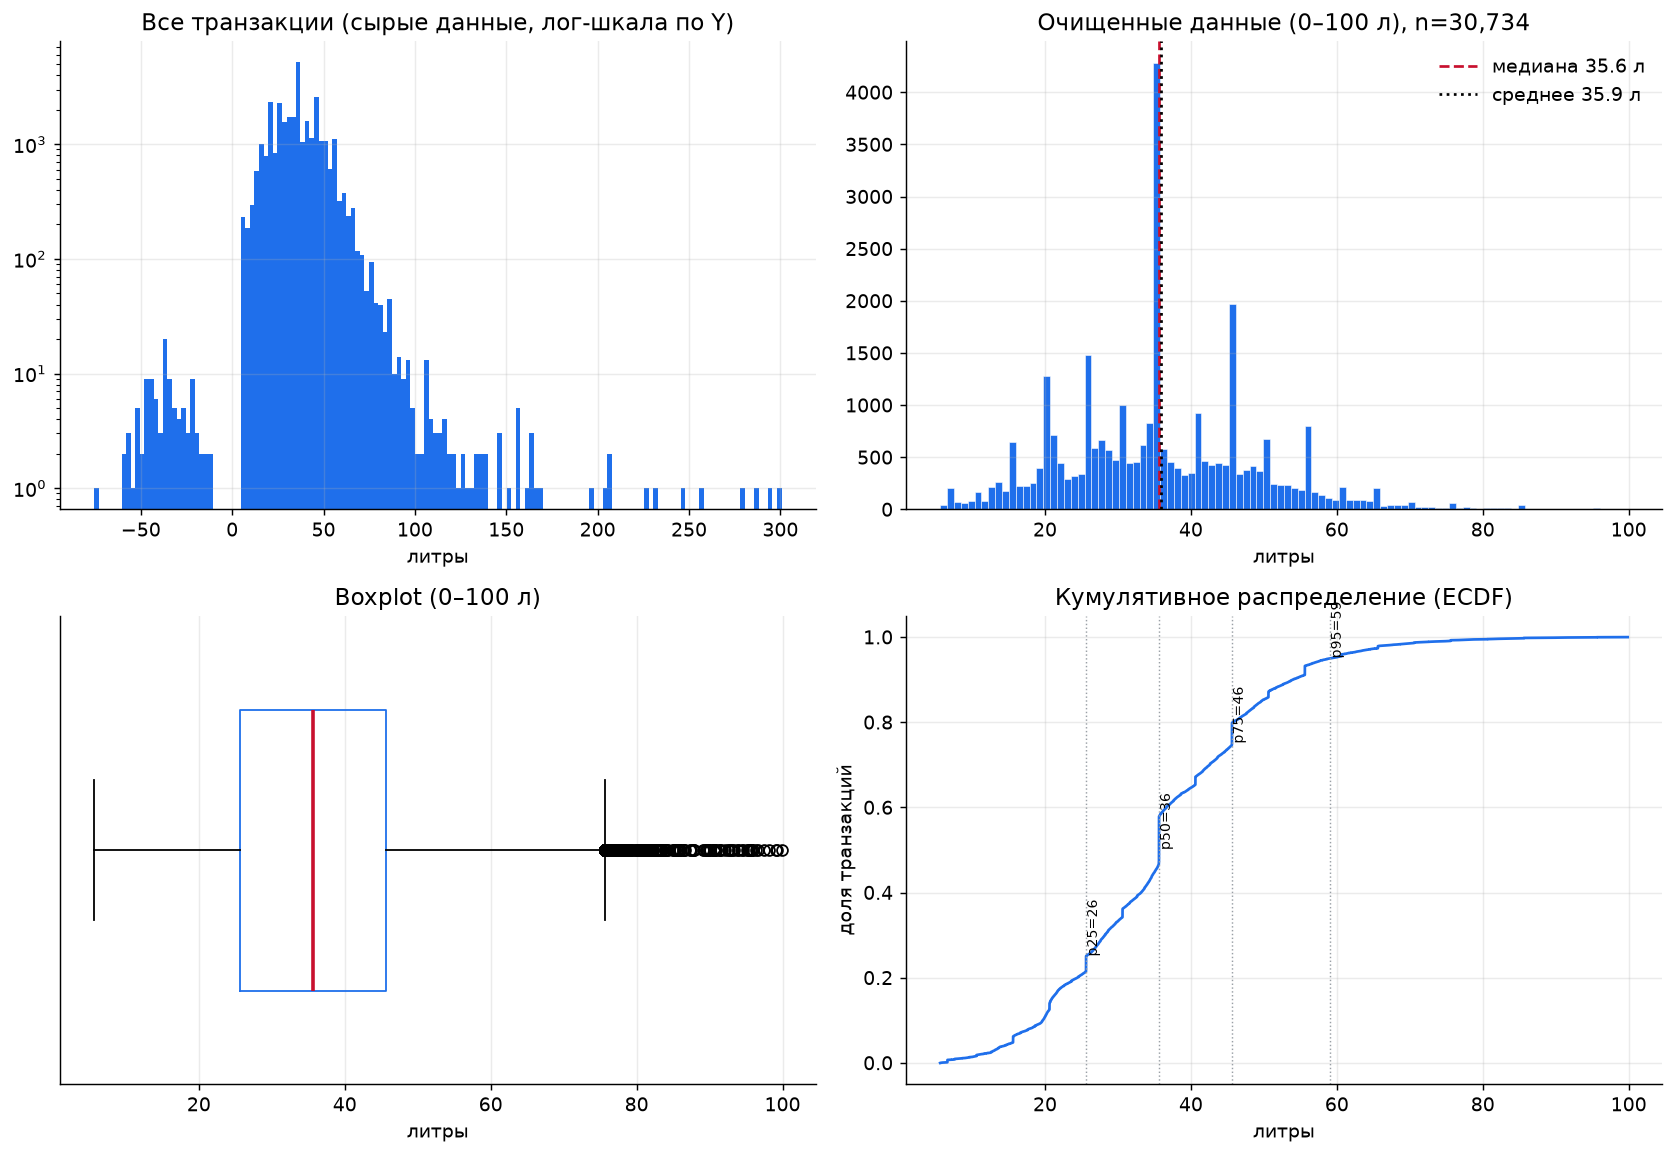


=== Перцентили (очищенные, 0–100 л) ===
count    30734.00
mean        35.94
std         13.61
min          5.63
5%          15.62
10%         19.69
25%         25.62
50%         35.62
75%         45.62
90%         53.93
95%         59.05
99%         73.77
max         99.86
Name: order_fuel_volume, dtype: float64


In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

vol = fuel.order_fuel_volume

print('=== Описательная статистика (сырые данные) ===')
print(vol.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(2))
print('\nотрицательных (возвраты):', (vol <= 0).sum(), f'({(vol<=0).mean():.2%})')
print('аномально больших (>100 л):', (vol > 100).sum(), f'({(vol>100).mean():.2%})')

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

# 1. полное распределение (сырое) — видно выбросы на хвостах
ax[0, 0].hist(vol, bins=150, color=BLUE)
ax[0, 0].set_yscale('log')
ax[0, 0].set_title('Все транзакции (сырые данные, лог-шкала по Y)')
ax[0, 0].set_xlabel('литры')

# 2. очищенное распределение (0 < объём <= 100)
vol_clean = vol[(vol > 0) & (vol <= 100)]
ax[0, 1].hist(vol_clean, bins=100, color=BLUE, edgecolor='white', linewidth=.3)
ax[0, 1].axvline(vol_clean.median(), color=RED, ls='--', lw=1.5, label=f'медиана {vol_clean.median():.1f} л')
ax[0, 1].axvline(vol_clean.mean(), color='k', ls=':', lw=1.5, label=f'среднее {vol_clean.mean():.1f} л')
ax[0, 1].set_title(f'Очищенные данные (0–100 л), n={len(vol_clean):,}')
ax[0, 1].set_xlabel('литры'); ax[0, 1].legend(frameon=False)

# 3. boxplot очищенных данных
ax[1, 0].boxplot(vol_clean, vert=False, widths=.6,
                 boxprops=dict(color=BLUE), medianprops=dict(color=RED, lw=2))
ax[1, 0].set_title('Boxplot (0–100 л)'); ax[1, 0].set_xlabel('литры')
ax[1, 0].set_yticks([])

# 4. кумулятивное распределение (ECDF)
xs = np.sort(vol_clean)
ys = np.arange(1, len(xs)+1) / len(xs)
ax[1, 1].plot(xs, ys, color=BLUE, lw=1.5)
for p in [25, 50, 75, 95]:
    v = np.percentile(vol_clean, p)
    ax[1, 1].axvline(v, color=GREY, ls=':', lw=.8)
    ax[1, 1].annotate(f'p{p}={v:.0f}', (v, p/100), fontsize=8, rotation=90, va='bottom')
ax[1, 1].set_title('Кумулятивное распределение (ECDF)')
ax[1, 1].set_xlabel('литры'); ax[1, 1].set_ylabel('доля транзакций')

plt.tight_layout()
plt.show()

print('\n=== Перцентили (очищенные, 0–100 л) ===')
print(vol_clean.describe(percentiles=[.05, .1, .25, .5, .75, .9, .95, .99]).round(2))

=== Общая картина ===
всего транзакций: 30913
возвратов: 105 (0.34%)
сумма объёма возвратов: -3793.7 л
возвраты встречаются у 105 уникальных клиентов из 16716

=== Матчинг возвратов с предыдущей покупкой ===
нашли предшествующую покупку: 48 (45.7%)
из них объём совпал (±0.5 л) — похоже на полный сторно: 8

разрыв во времени между покупкой и возвратом (дни), для сматченных:
count     48.00
mean      33.97
std       29.42
min        0.24
25%       11.20
50%       19.23
75%       55.52
95%       93.34
max      106.06
Name: gap_days, dtype: float64


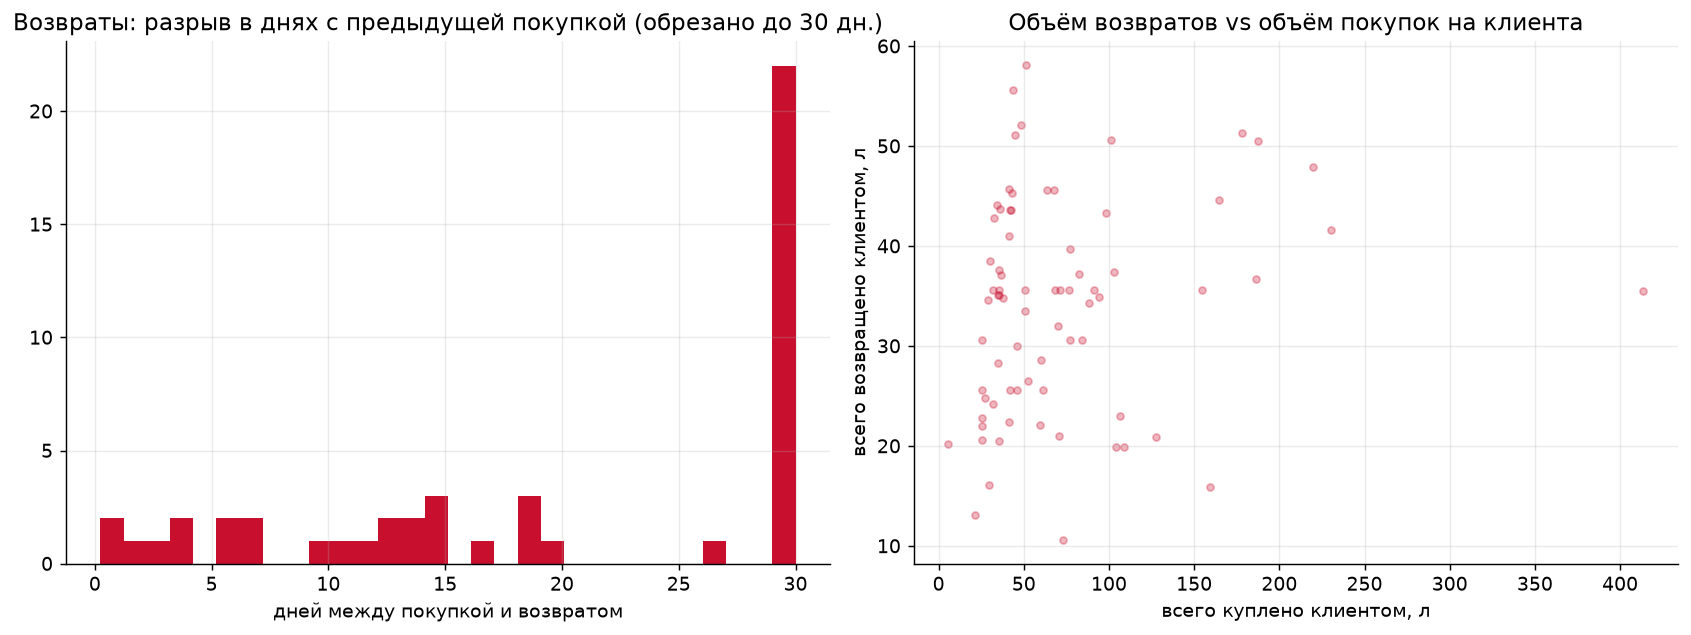


=== Итог обработки ===
было транзакций: 30913 | стало после нетто-обработки: 30777
суммарный объём был: 1111425.0 л
суммарный объём стал: 1113868.0 л
разница (чистый эффект возвратов, уже не задвоенный): -2444.0 л

для сравнения — наивное удаление возвратов дало бы: 30807 строк, 1115218.0 л


In [19]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY, GREEN = '#1F6FEB', '#C8102E', '#9AA0A6', '#1A9E5C'

fuel = fuel.sort_values(['client_id', 'order_datetime']).reset_index(drop=True)

refunds  = fuel[fuel.order_fuel_volume < 0].copy()
purchase = fuel[fuel.order_fuel_volume > 0].copy()

print('=== Общая картина ===')
print('всего транзакций:', len(fuel))
print('возвратов:', len(refunds), f'({len(refunds)/len(fuel):.2%})')
print('сумма объёма возвратов:', refunds.order_fuel_volume.sum().round(1), 'л')
print('возвраты встречаются у', refunds.client_id.nunique(), 'уникальных клиентов из', fuel.client_id.nunique())

# --- 1. Пытаемся сматчить каждый возврат с ближайшей ПРЕДЫДУЩЕЙ покупкой того же клиента
matched = []
for cid, r in refunds.groupby('client_id'):
    p = purchase[purchase.client_id == cid]
    if p.empty:
        for _, row in r.iterrows():
            matched.append({**row.to_dict(), 'matched': False, 'purchase_order_id': None, 'gap_days': None})
        continue
    for _, row in r.iterrows():
        prior = p[p.order_datetime < row.order_datetime]
        if prior.empty:
            matched.append({**row.to_dict(), 'matched': False, 'purchase_order_id': None, 'gap_days': None})
        else:
            nearest = prior.loc[(row.order_datetime - prior.order_datetime).abs().idxmin()]
            gap = (row.order_datetime - nearest.order_datetime).total_seconds() / 86400
            vol_match = abs(abs(row.order_fuel_volume) - nearest.order_fuel_volume) < 0.5
            matched.append({**row.to_dict(), 'matched': True, 'purchase_order_id': nearest.order_id,
                            'gap_days': round(gap, 2), 'vol_exact_match': vol_match})

M = pd.DataFrame(matched)
print('\n=== Матчинг возвратов с предыдущей покупкой ===')
print('нашли предшествующую покупку:', M.matched.sum(), f'({M.matched.mean():.1%})')
print('из них объём совпал (±0.5 л) — похоже на полный сторно:', M.vol_exact_match.sum())
print('\nразрыв во времени между покупкой и возвратом (дни), для сматченных:')
print(M[M.matched].gap_days.describe(percentiles=[.25, .5, .75, .95]).round(2))

# --- 2. Визуализация: где лежат возвраты относительно покупок
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].hist(M[M.matched].gap_days.clip(0, 30), bins=30, color=RED)
ax[0].set_title('Возвраты: разрыв в днях с предыдущей покупкой (обрезано до 30 дн.)')
ax[0].set_xlabel('дней между покупкой и возвратом')

ax[1].scatter(purchase.groupby('client_id').order_fuel_volume.sum().reindex(refunds.client_id.unique()),
             refunds.groupby('client_id').order_fuel_volume.sum().abs(),
             alpha=.3, s=15, color=RED)
ax[1].set_xlabel('всего куплено клиентом, л'); ax[1].set_ylabel('всего возвращено клиентом, л')
ax[1].set_title('Объём возвратов vs объём покупок на клиента')
plt.tight_layout(); plt.show()

# --- 3. Взаимозачёт: вычитаем возврат из объёма (и суммы) соответствующей покупки,
#     а не просто выкидываем обе строки — так не теряем реальный факт заправки
fuel_net = fuel.copy()
fuel_net['spend'] = fuel_net.order_fuel_volume * fuel_net.order_fuel_price_1liter

for _, row in M[M.matched].iterrows():
    idx = fuel_net.index[fuel_net.order_id == row.purchase_order_id]
    if len(idx):
        i = idx[0]
        fuel_net.loc[i, 'order_fuel_volume'] += row.order_fuel_volume  # row.volume < 0, значит вычитаем
        fuel_net.loc[i, 'spend'] += row.order_fuel_volume * row.order_fuel_price_1liter

# несматченные возвраты и все строки возвратов убираем как отдельные транзакции (они уже "погашены" выше)
fuel_net = fuel_net[~fuel_net.order_id.isin(refunds.order_id)]
# на всякий случай убираем то, что после взаимозачёта ушло в 0 или в минус (испорченные строки)
fuel_net = fuel_net[fuel_net.order_fuel_volume > 0]

print('\n=== Итог обработки ===')
print('было транзакций:', len(fuel), '| стало после нетто-обработки:', len(fuel_net))
print('суммарный объём был:', fuel.order_fuel_volume.sum().round(0), 'л')
print('суммарный объём стал:', fuel_net.order_fuel_volume.sum().round(0), 'л')
print('разница (чистый эффект возвратов, уже не задвоенный):',
      (fuel.order_fuel_volume.sum() - fuel_net.order_fuel_volume.sum()).round(0), 'л')

# сравнение с "наивным" вариантом (просто выкинуть все возвраты)
naive = fuel[fuel.order_fuel_volume > 0]
print('\nдля сравнения — наивное удаление возвратов дало бы:', len(naive), 'строк,',
      naive.order_fuel_volume.sum().round(0), 'л')

    штрафов  машин  накоплено машин  накоплено %
0         0  15354            15354         79.4
1         1   2699            18053         93.4
2         2    792            18845         97.5
3         3    266            19111         98.9
4         4    107            19218         99.4
5         5     58            19276         99.7
6         6     15            19291         99.8
7         7     13            19304         99.9
8         8     11            19315         99.9
9         9      4            19319        100.0
10       10      7            19326        100.0
11       16      1            19327        100.0


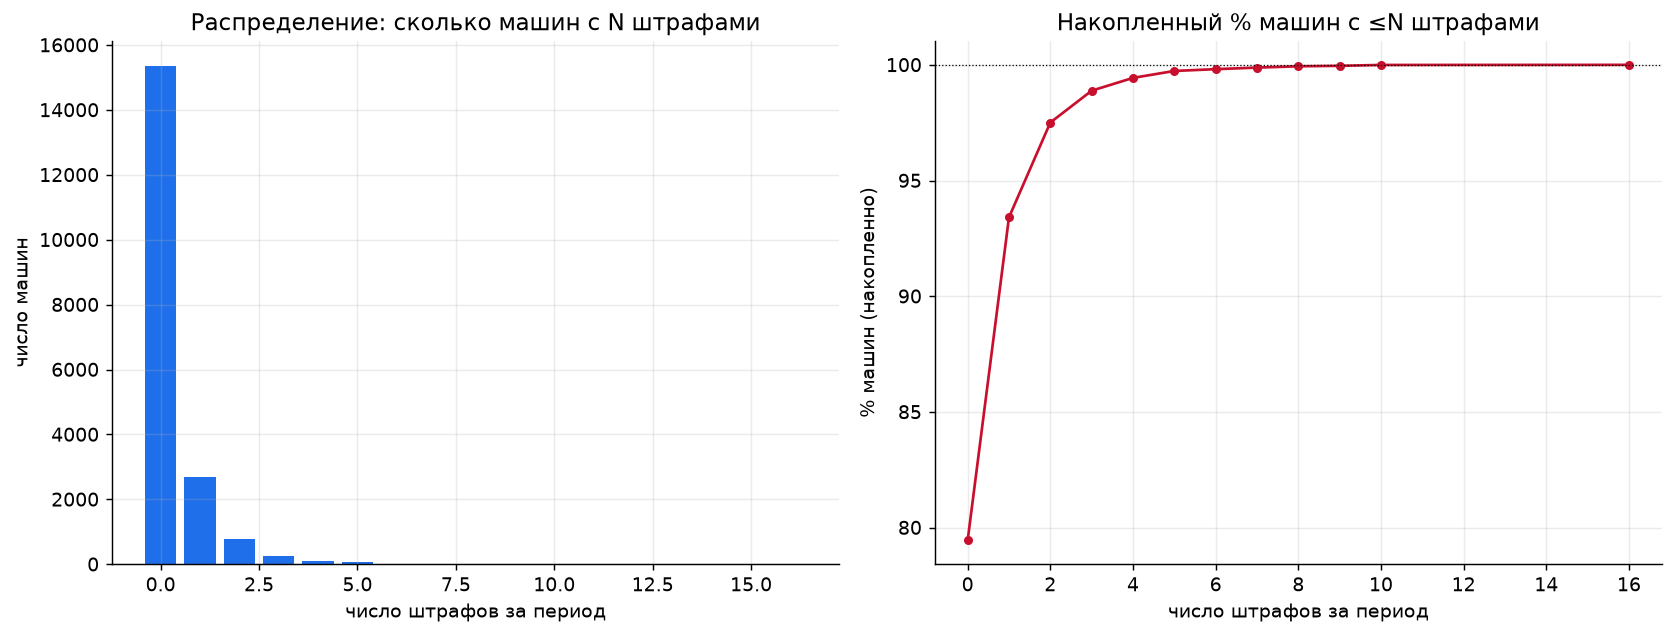


машин без единого штрафа: 15354 (79.4%)
машин с ≤1 штрафом: 93.4%
машин с ≤5 штрафами: 99.7%


In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

# сумма штрафов на машину за весь период 2026 (апр-авг)
total_fines = fines[fines.bill_offence_date.dt.month.between(4, 8)].groupby('auto_document_id').size()
# добавляем машины без единого штрафа
total_fines = total_fines.reindex(clients.auto_document_id.unique(), fill_value=0)

counts = total_fines.value_counts().sort_index()
cum = counts.cumsum()
cum_pct = cum / cum.iloc[-1] * 100

print(pd.DataFrame({'штрафов': counts.index, 'машин': counts.values,
                    'накоплено машин': cum.values, 'накоплено %': cum_pct.round(1).values}).head(20))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].bar(counts.index[:20], counts.values[:20], color=BLUE)
ax[0].set_xlabel('число штрафов за период'); ax[0].set_ylabel('число машин')
ax[0].set_title('Распределение: сколько машин с N штрафами')

ax[1].plot(cum_pct.index[:20], cum_pct.values[:20], marker='o', ms=4, color=RED)
ax[1].set_xlabel('число штрафов за период'); ax[1].set_ylabel('% машин (накопленно)')
ax[1].set_title('Накопленный % машин с ≤N штрафами')
ax[1].axhline(100, color='k', lw=.7, ls=':')

plt.tight_layout()
plt.show()

print(f'\nмашин без единого штрафа: {counts.get(0,0)} ({counts.get(0,0)/cum.iloc[-1]:.1%})')
print(f'машин с ≤1 штрафом: {cum_pct.get(1,0):.1f}%')
print(f'машин с ≤5 штрафами: {cum_pct.get(5,0):.1f}%')

  месяц  штрафов_2025  накоплено_2025  штрафов_2026  накоплено_2026
0   Апр       13598.0         13598.0          1488            1488
1   Май       18540.0         32138.0          2054            3542
2   Июн       18451.0         50589.0          2218            5760
3   Июл       20349.0         70938.0          2039            7799
4   Авг       17387.0         88325.0          1360            9159


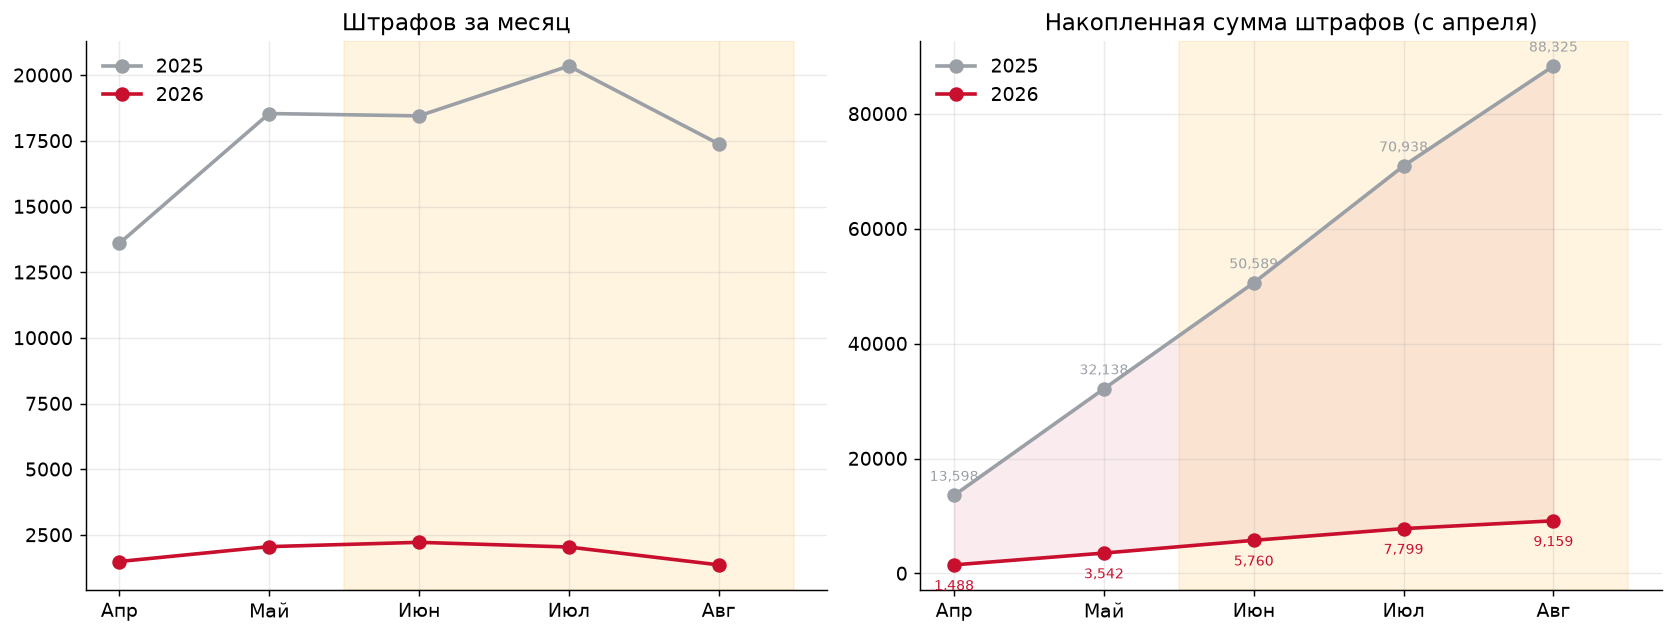


Итого за апрель-август: 2025 = 88,325.0, 2026 = 9,159 (-89.6%)


In [21]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

mm = {4: 'april', 5: 'may', 6: 'jun', 7: 'jul', 8: 'aug'}
cols25 = [f'{v}_2025_fines' for v in mm.values()]
mn = ['Апр', 'Май', 'Июн', 'Июл', 'Авг']

# суммарное число штрафов за месяц, 2025 (из готовых столбцов clients)
total25 = clients[cols25].sum().values

# суммарное число штрафов за месяц, 2026 (считаем из таблицы fines)
total26 = (fines[fines.bill_offence_date.dt.month.between(4, 8)]
           .groupby(fines.bill_offence_date.dt.month).size()
           .reindex([4, 5, 6, 7, 8], fill_value=0).values)

cum25 = np.cumsum(total25)
cum26 = np.cumsum(total26)

print(pd.DataFrame({'месяц': mn, 'штрафов_2025': total25, 'накоплено_2025': cum25,
                    'штрафов_2026': total26, 'накоплено_2026': cum26}))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 1. штрафы по месяцам (не накопленные) — для контекста
ax[0].plot(mn, total25, marker='o', ms=7, lw=2, color=GREY, label='2025')
ax[0].plot(mn, total26, marker='o', ms=7, lw=2, color=RED, label='2026')
ax[0].axvspan(1.5, 4.5, color='orange', alpha=.12)
ax[0].set_title('Штрафов за месяц'); ax[0].legend(frameon=False)

# 2. накопленная сумма штрафов
ax[1].plot(mn, cum25, marker='o', ms=7, lw=2, color=GREY, label='2025')
ax[1].plot(mn, cum26, marker='o', ms=7, lw=2, color=RED, label='2026')
ax[1].fill_between(mn, cum25, cum26, alpha=.08, color=RED)
ax[1].axvspan(1.5, 4.5, color='orange', alpha=.12)
ax[1].set_title('Накопленная сумма штрафов (с апреля)'); ax[1].legend(frameon=False)
for i, (v1, v2) in enumerate(zip(cum25, cum26)):
    ax[1].annotate(f'{v1:,.0f}', (i, v1), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=8, color=GREY)
    ax[1].annotate(f'{v2:,.0f}', (i, v2), xytext=(0, -14), textcoords='offset points', ha='center', fontsize=8, color=RED)

plt.tight_layout()
plt.show()

print(f'\nИтого за апрель-август: 2025 = {cum25[-1]:,}, 2026 = {cum26[-1]:,} ({(cum26[-1]/cum25[-1]-1)*100:+.1f}%)')

Распределение даты подключения подписки по годам:
sub_date
2014.0       1
2015.0      37
2016.0      75
2017.0     112
2018.0     190
2019.0     220
2020.0     432
2021.0     907
2022.0    1445
2023.0    3577
2024.0    3397
2025.0    5741
2026.0    3263
Name: count, dtype: int64

Всего строк (авто): 19398
Подписка оформлена ПОСЛЕ 2025-04-01 (то есть не было доступа к штрафам за апр-авг 2025): 8032 (41.4%)
Подписка оформлена ДО 2025-04-01 (есть полная история за весь период): 11365 (58.6%)

=== Доля "все нули за 2025" ===
среди БЕЗ подписки в 2025: 60.3% (4841 из 8032)
среди С подпиской в 2025: 10.9% (1237 из 11366)


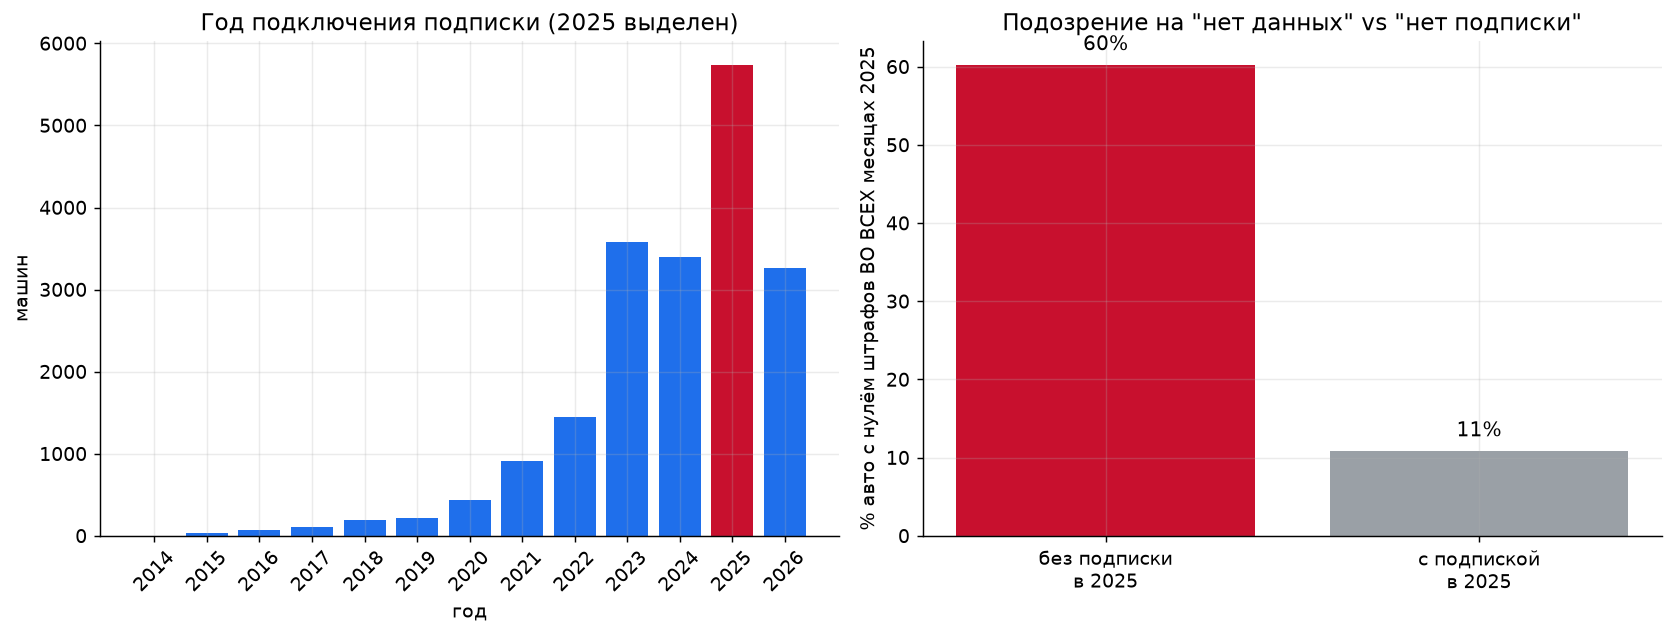

<Figure size 832x624 with 0 Axes>


Подозрительных строк (нет подписки в 2025 И все нули): 4841


,client_id,auto_document_id,sub_date,april_2025_fines,may_2025_fines,jun_2025_fines,jul_2025_fines,aug_2025_fines
0,9122e83613a0e07ebc41da2efdda607e,78f54bf348026e1bf73c9682b08293f6,2026-03-05,0.0,0.0,0.0,0.0,0.0
3,e1a80cdb8ff6e0125f6834ad41b91be1,1cc771ec64d7d383748ab5400ae5b587,2026-02-01,0.0,0.0,0.0,0.0,0.0
13,fb2d3ca15de55c7ee30ae5f163b55c67,e492ace24003b509a181fe78f41180b4,2026-06-08,0.0,0.0,0.0,0.0,0.0
16,271a02bd1c978d022e359a9907f8c8fc,d3f168c083bde30ac221cadcd9238a57,2026-06-21,0.0,0.0,0.0,0.0,0.0
19,1f0dde97878948dcbd7991b6642d18c2,fdbca909f6ab8eb0e6d557873d91ac20,2026-07-02,0.0,0.0,0.0,0.0,0.0
23,1e64bd7f2162b7219e352dac9c469239,395f0de7dddcc0ddfd8251f3b8efd9e0,2025-05-24,0.0,0.0,0.0,0.0,0.0
24,9ff300a58d6dcc5692c3f6a2534febca,d2b1ba7671f240d9c85425bbc047abee,2026-07-01,0.0,0.0,0.0,0.0,0.0
27,4418c386f81b48f468b1a8b9215d6e0a,91d401143faeeb42d9e9ff2ed13876c3,2025-10-24,0.0,0.0,0.0,0.0,0.0
32,4618f1215f27c2fe163279fe69b64dba,57d850780e9644cbbd3872b526cec400,2025-08-17,0.0,0.0,0.0,0.0,0.0
37,195fca3c72991da967286331019fd094,f9dd4f9b5156de11b145cd4a2a9111a0,2026-06-11,0.0,0.0,0.0,0.0,0.0


In [25]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

cols25 = ['april_2025_fines', 'may_2025_fines', 'jun_2025_fines', 'jul_2025_fines', 'aug_2025_fines']

# точка отсечки: подписка должна была существовать ДО начала интересующего месяца 2025 года
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

print('Распределение даты подключения подписки по годам:')
print(clients.sub_date.dt.year.value_counts().sort_index())

print('\nВсего строк (авто):', len(clients))
print('Подписка оформлена ПОСЛЕ 2025-04-01 (то есть не было доступа к штрафам за апр-авг 2025):',
      (clients.sub_date > '2025-04-01').sum(),
      f"({(clients.sub_date > '2025-04-01').mean():.1%})")
print('Подписка оформлена ДО 2025-04-01 (есть полная история за весь период):',
      (clients.sub_date <= '2025-04-01').sum(),
      f"({(clients.sub_date <= '2025-04-01').mean():.1%})")

# --- сравнение: доля "все нули" среди тех, у кого не было подписки, vs у кого была
no_sub_2025 = clients.sub_date > '2025-04-01'
all_zero = clients[cols25].sum(axis=1) == 0

print('\n=== Доля "все нули за 2025" ===')
print('среди БЕЗ подписки в 2025:', f"{all_zero[no_sub_2025].mean():.1%}",
      f"({all_zero[no_sub_2025].sum()} из {no_sub_2025.sum()})")
print('среди С подпиской в 2025:', f"{all_zero[~no_sub_2025].mean():.1%}",
      f"({all_zero[~no_sub_2025].sum()} из {(~no_sub_2025).sum()})")

# --- график
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 1. когда подключались (по годам)
yr = clients.sub_date.dt.year.value_counts().sort_index()
yr.index = yr.index.astype(int)  # 2025.0 -> 2025

colors_yr = [RED if y == 2025 else BLUE for y in yr.index]
ax[0].bar(yr.index.astype(str), yr.values, color=colors_yr)
ax[0].set_title('Год подключения подписки (2025 выделен)')
ax[0].set_xlabel('год'); ax[0].set_ylabel('машин')
ax[0].tick_params(axis='x', rotation=45)

# 2. сравнение доли "все нули" — с подпиской в 2025 vs без
comp = pd.DataFrame({
    'группа': ['без подписки\nв 2025', 'с подпиской\nв 2025'],
    'доля_все_нули': [all_zero[no_sub_2025].mean()*100, all_zero[~no_sub_2025].mean()*100]
})
ax[1].bar(comp.группа, comp.доля_все_нули, color=[RED, GREY])
ax[1].set_ylabel('% авто с нулём штрафов ВО ВСЕХ месяцах 2025')
ax[1].set_title('Подозрение на "нет данных" vs "нет подписки"')
for i, v in enumerate(comp.доля_все_нули):
    ax[1].annotate(f'{v:.0f}%', (i, v), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=11)

plt.tight_layout()
plt.show()
# 2. сравнение доли "все нули" — с подпиской в 2025 vs без
comp = pd.DataFrame({
    'группа': ['без подписки\nв 2025', 'с подпиской\nв 2025'],
    'доля_все_нули': [all_zero[no_sub_2025].mean()*100, all_zero[~no_sub_2025].mean()*100]
})
ax[1].bar(comp.группа, comp.доля_все_нули, color=[RED, GREY])
ax[1].set_ylabel('% авто с нулём штрафов ВО ВСЕХ месяцах 2025')
ax[1].set_title('Подозрение на "нет данных" vs "нет подписки"')
for i, v in enumerate(comp.доля_все_нули):
    ax[1].annotate(f'{v:.0f}%', (i, v), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

# --- список для проверки (кто эти клиенты)
suspicious = clients[no_sub_2025 & all_zero]
print(f'\nПодозрительных строк (нет подписки в 2025 И все нули): {len(suspicious)}')
display(suspicious[['client_id', 'auto_document_id', 'sub_date'] + cols25].head(15))

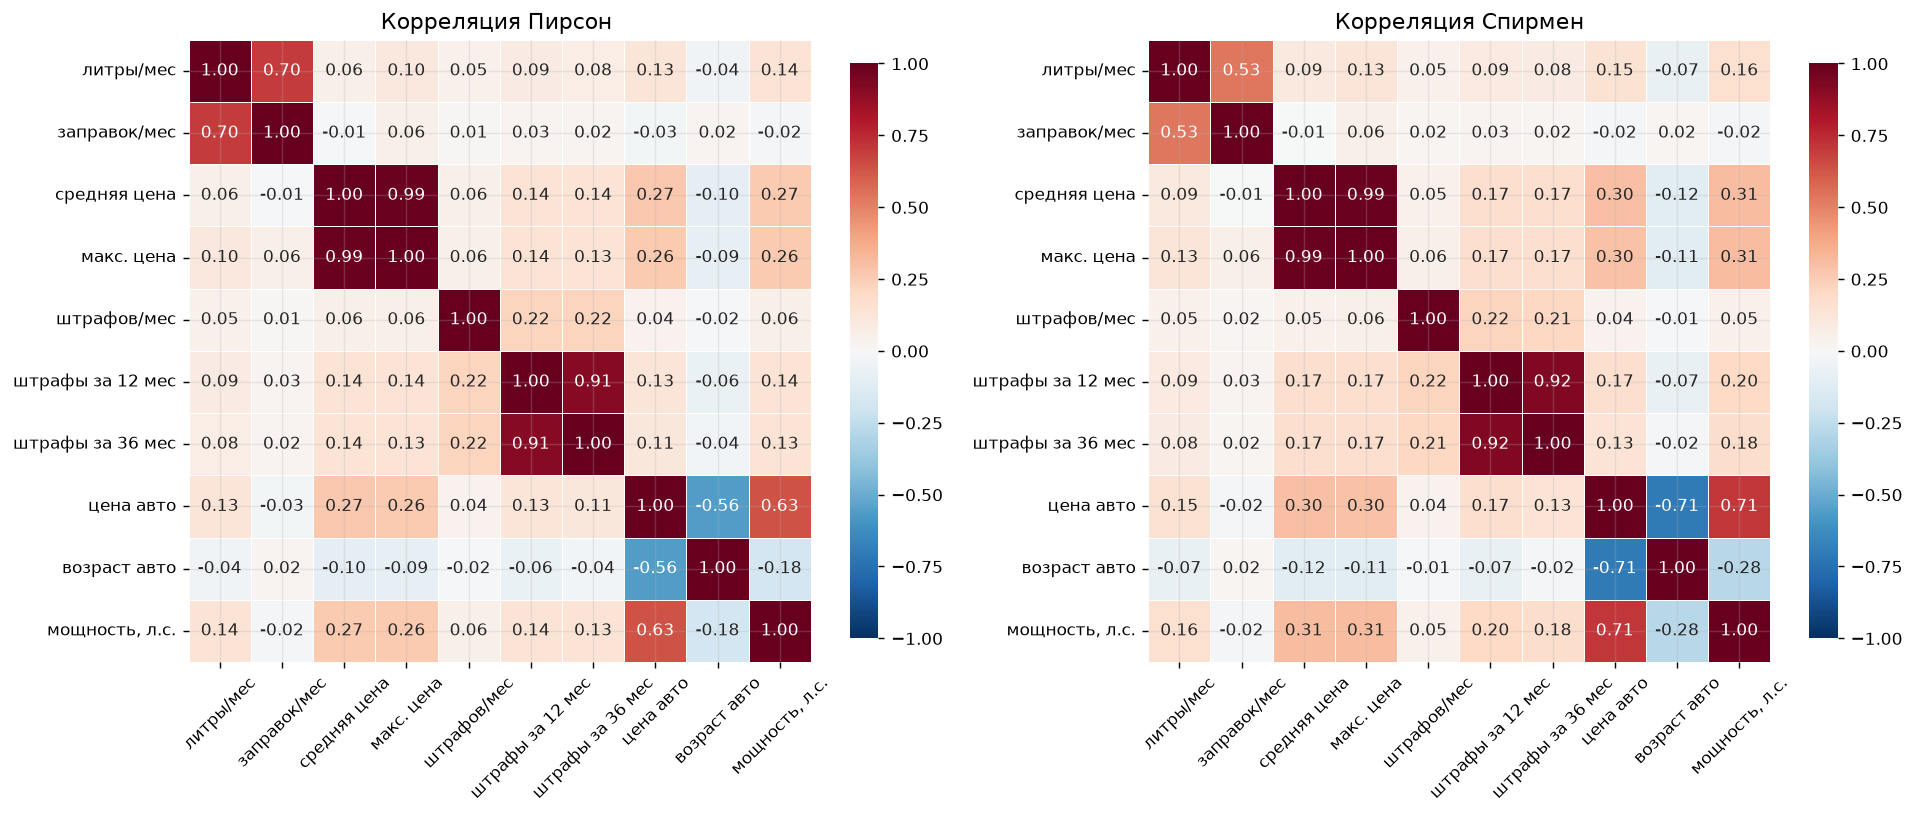

=== Пирсон ===


,литры/мес,заправок/мес,средняя цена,макс. цена,штрафов/мес,штрафы за 12 мес,штрафы за 36 мес,цена авто,возраст авто,"мощность, л.с."
литры/мес,1.000,0.696,0.061,0.105,0.049,0.085,0.077,0.128,-0.045,0.141
заправок/мес,0.696,1.000,-0.011,0.056,0.015,0.030,0.024,-0.029,0.025,-0.016
средняя цена,0.061,-0.011,1.000,0.986,0.061,0.136,0.135,0.272,-0.097,0.265
макс. цена,0.105,0.056,0.986,1.000,0.061,0.135,0.134,0.264,-0.091,0.260
штрафов/мес,0.049,0.015,0.061,0.061,1.000,0.221,0.221,0.040,-0.015,0.059
штрафы за 12 мес,0.085,0.030,0.136,0.135,0.221,1.000,0.914,0.129,-0.065,0.138
штрафы за 36 мес,0.077,0.024,0.135,0.134,0.221,0.914,1.000,0.110,-0.036,0.134
цена авто,0.128,-0.029,0.272,0.264,0.040,0.129,0.110,1.000,-0.558,0.635
возраст авто,-0.045,0.025,-0.097,-0.091,-0.015,-0.065,-0.036,-0.558,1.000,-0.184
"мощность, л.с.",0.141,-0.016,0.265,0.260,0.059,0.138,0.134,0.635,-0.184,1.000



=== Спирмен ===


,литры/мес,заправок/мес,средняя цена,макс. цена,штрафов/мес,штрафы за 12 мес,штрафы за 36 мес,цена авто,возраст авто,"мощность, л.с."
литры/мес,1.000,0.535,0.094,0.128,0.048,0.091,0.082,0.148,-0.070,0.161
заправок/мес,0.535,1.000,-0.007,0.057,0.019,0.026,0.018,-0.023,0.023,-0.020
средняя цена,0.094,-0.007,1.000,0.992,0.054,0.166,0.165,0.299,-0.117,0.311
макс. цена,0.128,0.057,0.992,1.000,0.056,0.167,0.166,0.296,-0.112,0.308
штрафов/мес,0.048,0.019,0.054,0.056,1.000,0.221,0.206,0.043,-0.013,0.052
штрафы за 12 мес,0.091,0.026,0.166,0.167,0.221,1.000,0.922,0.166,-0.073,0.197
штрафы за 36 мес,0.082,0.018,0.165,0.166,0.206,0.922,1.000,0.133,-0.020,0.176
цена авто,0.148,-0.023,0.299,0.296,0.043,0.166,0.133,1.000,-0.709,0.715
возраст авто,-0.070,0.023,-0.117,-0.112,-0.013,-0.073,-0.020,-0.709,1.000,-0.275
"мощность, л.с.",0.161,-0.020,0.311,0.308,0.052,0.197,0.176,0.715,-0.275,1.000


In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 130, 'font.size': 9.5})

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fuel    = pd.read_csv(U + 'fuel_transaction.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)
fuel['dt']  = pd.to_datetime(fuel.order_datetime)

# ---- чистим заправки (как обсуждали: возвраты, аномальные объёмы/цены)
fuel_c = fuel[(fuel.order_fuel_volume > 0) & (fuel.order_fuel_volume <= 100) &
             (fuel.order_fuel_price_1liter.between(40, 150))].copy()
fuel_c = fuel_c[fuel_c.dt.between('2026-04-01', '2026-07-31')]  # чистое окно, без цензуры августа
fuel_c['month'] = fuel_c.dt.dt.month

fn = fines[fines.dt.between('2026-04-01', '2026-07-31')].copy()
fn['month'] = fn.dt.dt.month

# ---- панель клиент x месяц
f_agg = fuel_c.groupby(['client_id', 'month']).agg(
    tx_n=('order_id', 'size'), liters=('order_fuel_volume', 'sum'),
    price_mean=('order_fuel_price_1liter', 'mean'), price_max=('order_fuel_price_1liter', 'max')).reset_index()
fi_agg = fn.groupby(['client_id', 'month']).size().rename('fines_n').reset_index()

attrs = clients.drop_duplicates('client_id')[['client_id', 'auto_year', 'price', 'engine_type',
                                                'fines_last_12_month', 'fines_last_36_month']].copy()
attrs['engine_hp'] = pd.to_numeric(attrs.engine_type.fillna('').str.extract(r'\(([\d.]+)')[0], errors='coerce')
attrs['auto_age'] = 2026 - attrs.auto_year

panel = (f_agg.merge(fi_agg, on=['client_id', 'month'], how='left')
              .merge(attrs, on='client_id', how='left'))
panel['fines_n'] = panel.fines_n.fillna(0)
panel['price_per_liter'] = panel.price_mean

num_cols = {
    'литры/мес': 'liters', 'заправок/мес': 'tx_n', 'средняя цена': 'price_mean', 'макс. цена': 'price_max',
    'штрафов/мес': 'fines_n', 'штрафы за 12 мес': 'fines_last_12_month', 'штрафы за 36 мес': 'fines_last_36_month',
    'цена авто': 'price', 'возраст авто': 'auto_age', 'мощность, л.с.': 'engine_hp'
}
M = panel[list(num_cols.values())].rename(columns={v: k for k, v in num_cols.items()})

# ---- матрицы корреляций
corr_p = M.corr(method='pearson')
corr_s = M.corr(method='spearman')

fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
for a, c, title in [(ax[0], corr_p, 'Пирсон'), (ax[1], corr_s, 'Спирмен')]:
    sns.heatmap(c, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={'shrink': .8}, ax=a)
    a.set_title(f'Корреляция Пирсон ' if title == 'Пирсон' else 'Корреляция Спирмен', fontsize=12)
    a.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('=== Пирсон ===')
display(corr_p.round(3))
print('\n=== Спирмен ===')
display(corr_s.round(3))

findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight normal for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.


✅ Зарегистрированы шрифты: ['Gilroy', 'Gilroy']
🎯 Основной шрифт: Gilroy
🎨 Палитра: {'розовый': '#FB52A5', 'оранжевый': '#FD8616', 'фиолетовый': '#7061F0'}
Готово — все следующие графики автоматически используют шрифт и палитру.


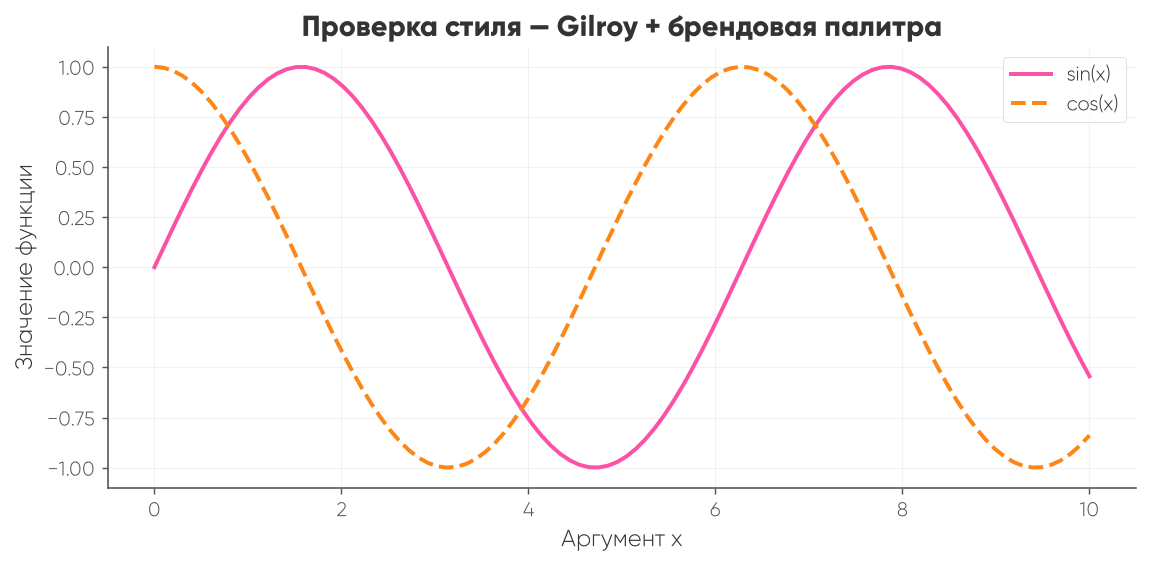

In [1]:
# %% [markdown]
# ## ✨ Глобальный дизайн графиков — шрифт Gilroy + фирменная палитра

# %%
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

# --------------------------
# 1. Регистрация шрифтов Gilroy
# --------------------------
font_dir = Path.cwd()
font_files = [
    font_dir / "Gilroy-Light.otf",
    font_dir / "Gilroy-ExtraBold.otf",
]

missing_fonts = [str(f) for f in font_files if not f.exists()]
if missing_fonts:
    raise FileNotFoundError(f"Шрифты Gilroy не найдены в корне проекта: {missing_fonts}")

registered_names = []
for font_file in font_files:
    font_manager.fontManager.addfont(str(font_file))
    registered_names.append(font_manager.FontProperties(fname=str(font_file)).get_name())

_gilroy_name = registered_names[0]
print("✅ Зарегистрированы шрифты:", registered_names)
print("🎯 Основной шрифт:", _gilroy_name)

# --------------------------
# 2. Фирменная палитра
# --------------------------
PINK   = '#FB52A5'
ORANGE = '#FD8616'
PURPLE = '#7061F0'
WHITE  = '#FFFFFF'
INK    = '#333333'   # текст
MUTE   = '#555555'   # оси/тики
GREY   = '#B0B0B0'   # нейтральный/контрольная группа

BRAND = [PINK, ORANGE, PURPLE]                 # основной циклический порядок цветов
BRAND_EXT = [PINK, ORANGE, PURPLE, INK, GREY]  # если серий больше трёх

# диверг. цветовая карта для heatmap/корреляций на основе фирменных цветов
BRAND_CMAP = LinearSegmentedColormap.from_list('brand_diverging', [PURPLE, WHITE, PINK])
# последовательная карта (например, для интенсивности/плотности)
BRAND_SEQ = LinearSegmentedColormap.from_list('brand_sequential', [WHITE, ORANGE, PINK])

# --------------------------
# 3. Глобальные rcParams
# --------------------------
plt.rcParams.update({
    # шрифт
    'font.family': _gilroy_name,
    'font.weight': 'regular',

    # размеры
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.titlesize': 18,
    'figure.dpi': 130,

    # фон — всегда белый, независимо от темы ноутбука/системы
    'figure.facecolor': WHITE,
    'axes.facecolor': WHITE,
    'savefig.facecolor': WHITE,

    # текст и оси
    'text.color': INK,
    'axes.labelcolor': INK,
    'xtick.color': MUTE,
    'ytick.color': MUTE,
    'axes.edgecolor': MUTE,

    # цикл цветов по умолчанию — подтянется в любой plot()/bar()/scatter() без явного цвета
    'axes.prop_cycle': plt.cycler(color=BRAND_EXT),

    # сетка и рамки
    'axes.grid': True,
    'grid.color': '#E8E8E8',
    'grid.alpha': 0.6,
    'grid.linewidth': 0.6,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.linewidth': 0.9,

    # линии/маркеры по умолчанию
    'lines.linewidth': 2.2,
    'lines.markersize': 6,
    'patch.edgecolor': WHITE,
    'patch.linewidth': 0.4,
})

matplotlib.rc('font', family=_gilroy_name)

print("🎨 Палитра:", {'розовый': PINK, 'оранжевый': ORANGE, 'фиолетовый': PURPLE})
print("Готово — все следующие графики автоматически используют шрифт и палитру.")

# --------------------------
# 4. Тестовый график (проверка стиля)
# --------------------------
x = np.linspace(0, 10, 100)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, np.sin(x), label='sin(x)')
ax.plot(x, np.cos(x), label='cos(x)', linestyle='--')
ax.set_title('Проверка стиля — Gilroy + брендовая палитра')
ax.set_xlabel('Аргумент x'); ax.set_ylabel('Значение функции')
ax.legend()
plt.tight_layout()
plt.show()


findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight normal for Gilroy, now using 300.
findfont: Failed to find font weight bold for Gilroy, now using 800.
findfont: Failed to find font weight regular for Gilroy, now using 300.
findfont: Failed to find font weight regular for Gilroy, now using 300.


Всего клиентов (знаменатель): 18137

Штрафов по периодам:
period
до кризиса (апр-май)    3542
кризис (июн-июл)        4213
dtype: int64

Среднее штрафов на человека за период (2 мес vs 2 мес):
period
до кризиса (апр-май)    0.1953
кризис (июн-июл)        0.2323
dtype: float64

Изменение: +18.9%


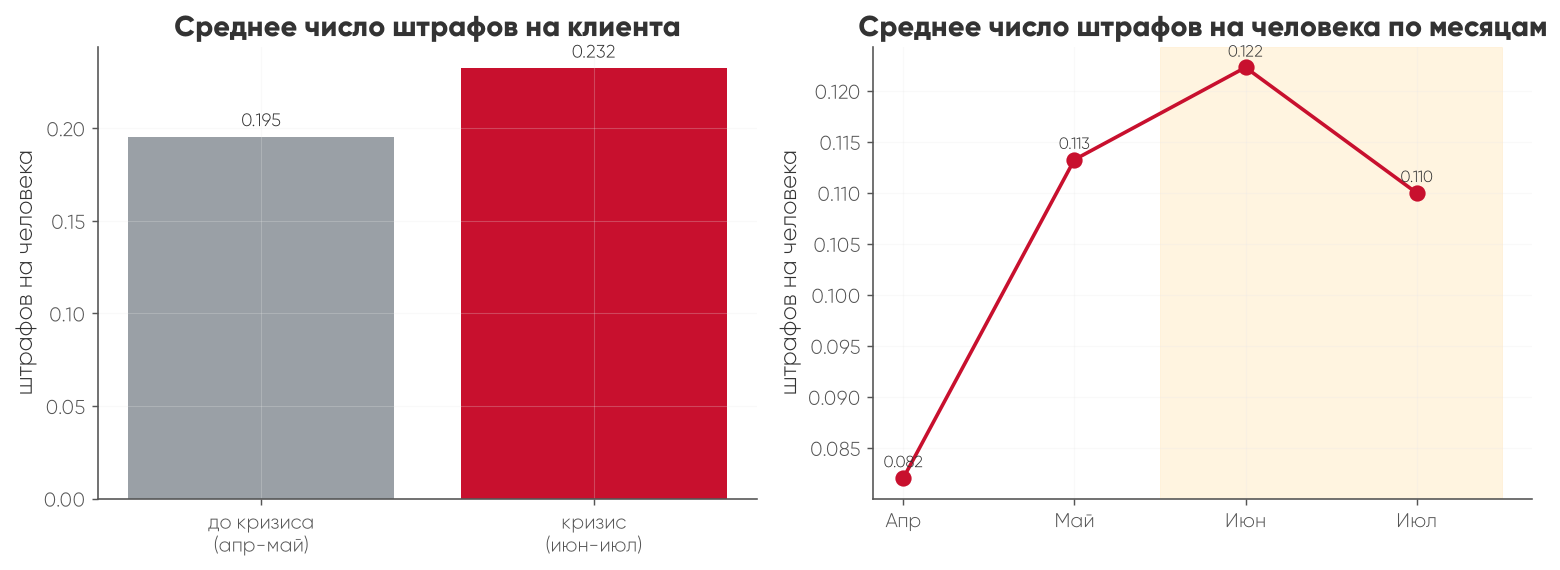

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)

n_clients = clients.client_id.nunique()   # знаменатель — ВСЕ клиенты, включая тех, у кого 0 штрафов

f = fines[fines.dt.between('2026-04-01', '2026-07-31')].copy()
f['period'] = np.where(f.dt.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-июл)')

# среднее на человека = сумма штрафов в периоде / число дней в периоде / число клиентов,
# либо просто сумма штрафов / число клиентов за весь период (сопоставимость по длине периода — 2 месяца и 2 месяца)
by_period = f.groupby('period').size()
mean_per_client = (by_period / n_clients).round(4)

print('Всего клиентов (знаменатель):', n_clients)
print('\nШтрафов по периодам:'); print(by_period)
print('\nСреднее штрафов на человека за период (2 мес vs 2 мес):')
print(mean_per_client)
print(f'\nИзменение: {(mean_per_client.iloc[1]/mean_per_client.iloc[0]-1)*100:+.1f}%')

# --- то же помесячно, для наглядности
mn = ['Апр', 'Май', 'Июн', 'Июл']
by_month = f.groupby(f.dt.dt.month).size().reindex([4,5,6,7])
mean_month = by_month / n_clients

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].bar(['до кризиса\n(апр-май)', 'кризис\n(июн-июл)'], mean_per_client.values,
         color=[GREY, RED])
ax[0].set_ylabel('штрафов на человека')
ax[0].set_title('Среднее число штрафов на клиента')
for i, v in enumerate(mean_per_client.values):
    ax[0].annotate(f'{v:.3f}', (i, v), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=10)

ax[1].plot(mn, mean_month.values, marker='o', ms=8, lw=2, color=RED)
ax[1].axvspan(1.5, 3.5, color='orange', alpha=.12)
ax[1].set_title('Среднее число штрафов на человека по месяцам')
ax[1].set_ylabel('штрафов на человека')
for i, v in enumerate(mean_month.values):
    ax[1].annotate(f'{v:.3f}', (i, v), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Клиентов с историей 2025: 15494

Среднее штрафов на человека по месяцам:
     2025    2026
4  1.0605  0.5304
5  1.4099  0.6947
6  1.3150  0.7424
7  1.3985  0.6734


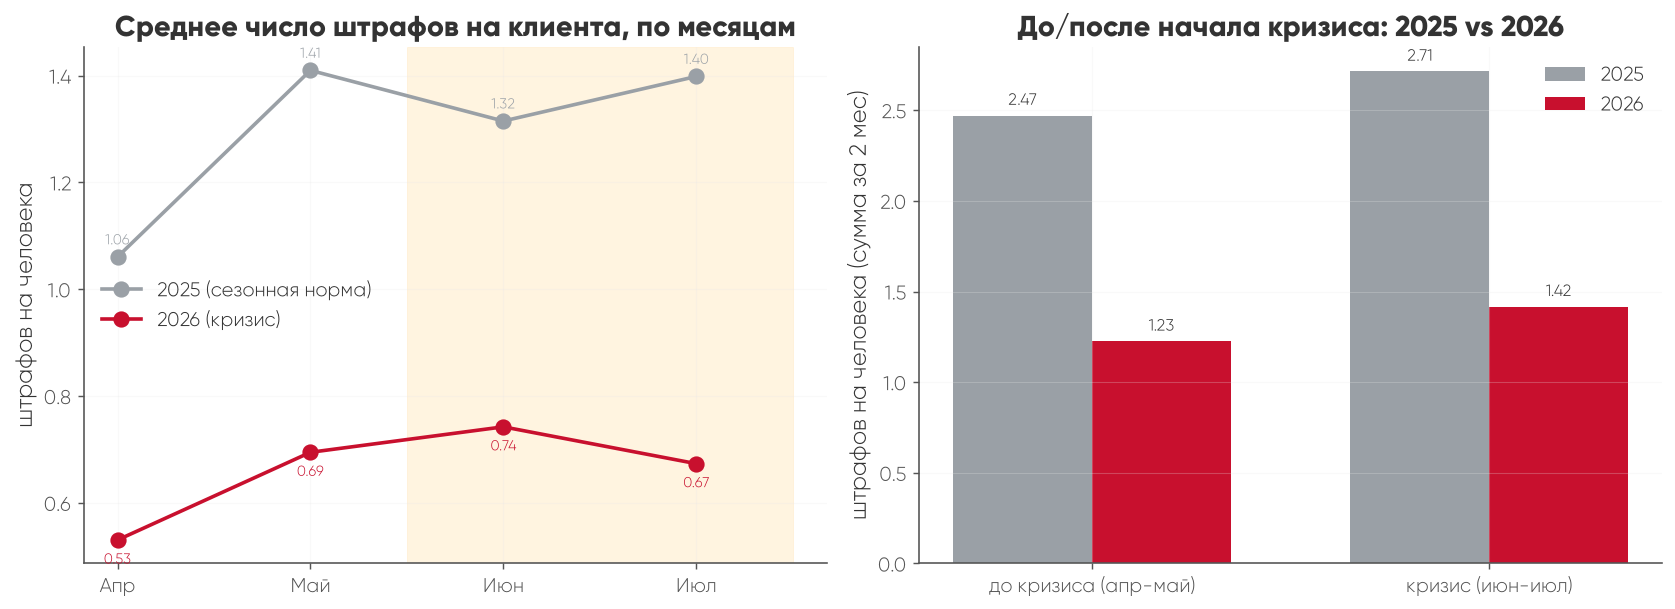


Отношение 2026/2025 по месяцам:
dt
4    0.500
5    0.493
6    0.565
7    0.481
dtype: float64


In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

# только клиенты с валидной историей 2025 (подписка до апреля 2025)
base = clients[clients.sub_date < '2025-04-01']
n_clients = base.client_id.nunique()
print('Клиентов с историей 2025:', n_clients)

# --- 2025: суммируем по клиенту (у клиента может быть несколько авто -> суммируем штрафы всех его авто)
cols25 = ['april_2025_fines', 'may_2025_fines', 'jun_2025_fines', 'jul_2025_fines']
sum25 = base.groupby('client_id')[cols25].sum().sum()  # сумма по всем клиентам, по месяцам
sum25.index = [4, 5, 6, 7]

# --- 2026: те же клиенты, штрафы из таблицы fines
valid_clients = set(base.client_id)
f26 = fines[fines.client_id.isin(valid_clients) & fines.dt.between('2026-04-01', '2026-07-31')].copy()
sum26 = f26.groupby(f26.dt.dt.month).size().reindex([4, 5, 6, 7], fill_value=0)

mn = ['Апр', 'Май', 'Июн', 'Июл']
mean25 = sum25 / n_clients
mean26 = sum26 / n_clients

print('\nСреднее штрафов на человека по месяцам:')
print(pd.DataFrame({'2025': mean25.round(4), '2026': mean26.round(4)}))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# 1. линии по месяцам
ax[0].plot(mn, mean25.values, marker='o', ms=8, lw=2, color=GREY, label='2025 (сезонная норма)')
ax[0].plot(mn, mean26.values, marker='o', ms=8, lw=2, color=RED, label='2026 (кризис)')
ax[0].axvspan(1.5, 3.5, color='orange', alpha=.12)
ax[0].set_ylabel('штрафов на человека'); ax[0].set_title('Среднее число штрафов на клиента, по месяцам')
ax[0].legend(frameon=False)
for i, (v1, v2) in enumerate(zip(mean25, mean26)):
    ax[0].annotate(f'{v1:.2f}', (i, v1), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8, color=GREY)
    ax[0].annotate(f'{v2:.2f}', (i, v2), xytext=(0, -13), textcoords='offset points', ha='center', fontsize=8, color=RED)

# 2. сгруппированные периоды до/после
p25 = pd.Series({'до кризиса (апр-май)': mean25[[4,5]].sum(), 'кризис (июн-июл)': mean25[[6,7]].sum()})
p26 = pd.Series({'до кризиса (апр-май)': mean26[[4,5]].sum(), 'кризис (июн-июл)': mean26[[6,7]].sum()})
x = np.arange(2); w = .35
ax[1].bar(x - w/2, p25.values, w, label='2025', color=GREY)
ax[1].bar(x + w/2, p26.values, w, label='2026', color=RED)
ax[1].set_xticks(x); ax[1].set_xticklabels(p25.index)
ax[1].set_ylabel('штрафов на человека (сумма за 2 мес)')
ax[1].set_title('До/после начала кризиса: 2025 vs 2026'); ax[1].legend(frameon=False)
for i, (v1, v2) in enumerate(zip(p25.values, p26.values)):
    ax[1].annotate(f'{v1:.2f}', (i - w/2, v1), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=9)
    ax[1].annotate(f'{v2:.2f}', (i + w/2, v2), xytext=(0, 6), textcoords='offset points', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'\nОтношение 2026/2025 по месяцам:')
print((mean26/mean25).round(3))

Размеры групп:
группа
1. полная история\n(подписка до 04.2025)            14987
2. частичная история\n(подписка в 2025-нач.2026)     8296
3. без истории\n(подписка после 04.2026)             2392
Name: count, dtype: int64

Доля от всех клиентов:
группа
1. полная история\n(подписка до 04.2025)            58.4
2. частичная история\n(подписка в 2025-нач.2026)    32.3
3. без истории\n(подписка после 04.2026)             9.3
Name: proportion, dtype: float64

Среднее штрафов на человека по группам и периодам:
period                                            до кризиса  кризис
группа                                                              
1. полная история\n(подписка до 04.2025)              1.1925  1.3713
2. частичная история\n(подписка в 2025-нач.2026)      1.0473  1.2172
3. без истории\n(подписка после 04.2026)              0.7437  1.2212


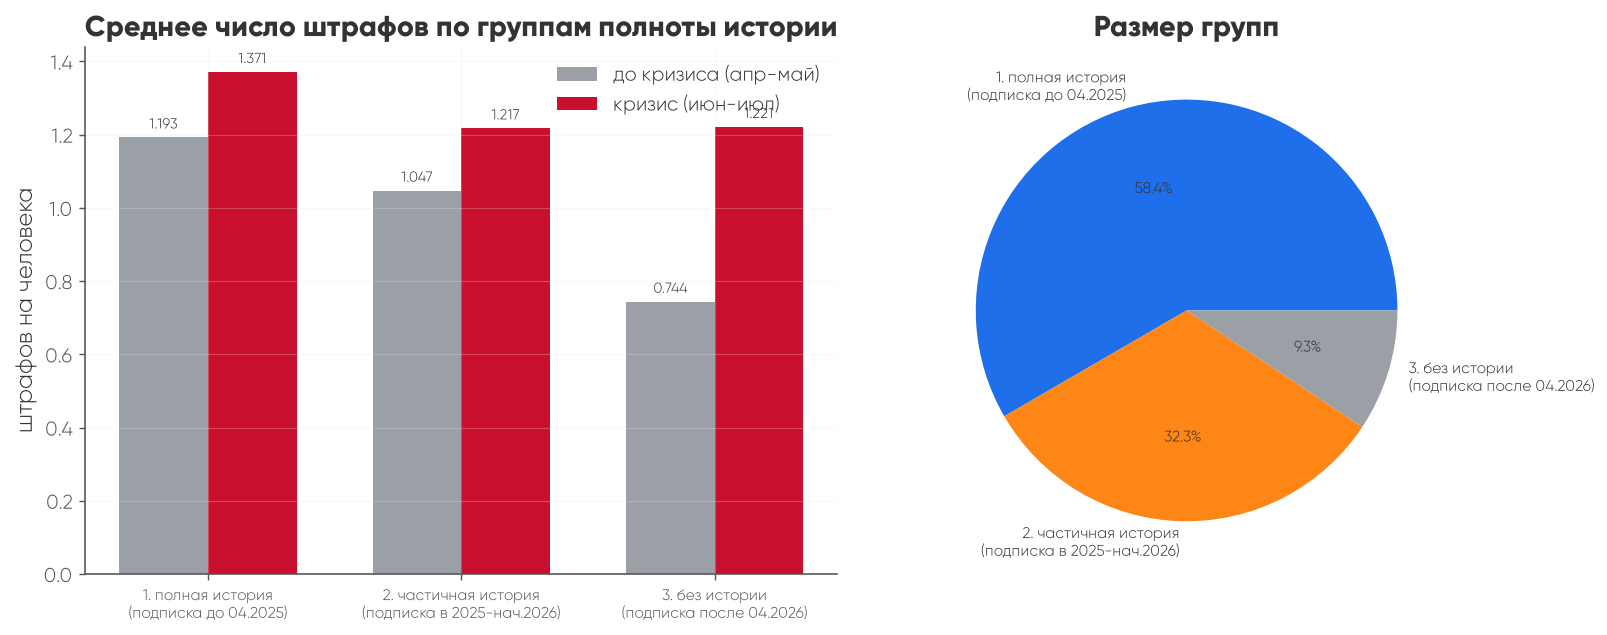


Изменение (кризис/до кризиса) по группам:
группа
1. полная история\n(подписка до 04.2025)            1.150
2. частичная история\n(подписка в 2025-нач.2026)    1.162
3. без истории\n(подписка после 04.2026)            1.642
dtype: float64


In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY, ORANGE = '#1F6FEB', '#C8102E', '#9AA0A6', '#FD8616'

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

# --- классификация клиентов по полноте истории
cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return '1. полная история\n(подписка до 04.2025)'
    elif sd < pd.Timestamp('2026-04-01'):
        return '2. частичная история\n(подписка в 2025-нач.2026)'
    else:
        return '3. без истории\n(подписка после 04.2026)'

cl['группа'] = cl.sub_date.apply(classify)
print('Размеры групп:')
print(cl.группа.value_counts())
print('\nДоля от всех клиентов:')
print((cl.группа.value_counts(normalize=True) * 100).round(1))

# --- штрафы 2026 по клиенту и месяцу (апр-июл, чистое окно)
f = fines[fines.dt.between('2026-04-01', '2026-07-31')].merge(cl[['client_id', 'группа']], on='client_id')
f['period'] = np.where(f.dt.dt.month <= 5, 'до кризиса', 'кризис')

sizes = cl.группа.value_counts()

by_grp = f.groupby(['группа', 'period']).size().unstack()
mean_by_grp = by_grp.div(sizes, axis=0)
mean_by_grp = mean_by_grp[['до кризиса', 'кризис']]  # порядок колонок

print('\nСреднее штрафов на человека по группам и периодам:')
print(mean_by_grp.round(4))

# --- график
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(mean_by_grp)); w = .35
ax[0].bar(x - w/2, mean_by_grp['до кризиса'], w, label='до кризиса (апр-май)', color=GREY)
ax[0].bar(x + w/2, mean_by_grp['кризис'], w, label='кризис (июн-июл)', color=RED)
ax[0].set_xticks(x); ax[0].set_xticklabels(mean_by_grp.index, fontsize=8.5)
ax[0].set_ylabel('штрафов на человека')
ax[0].set_title('Среднее число штрафов по группам полноты истории')
ax[0].legend(frameon=False)
for i, (v1, v2) in enumerate(zip(mean_by_grp['до кризиса'], mean_by_grp['кризис'])):
    ax[0].annotate(f'{v1:.3f}', (i - w/2, v1), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8)
    ax[0].annotate(f'{v2:.3f}', (i + w/2, v2), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8)

# доли групп
ax[1].pie(sizes.values, labels=sizes.index, autopct='%1.1f%%', colors=[BLUE, ORANGE, GREY],
         textprops={'fontsize': 8.5})
ax[1].set_title('Размер групп')

plt.tight_layout()
plt.show()

print('\nИзменение (кризис/до кризиса) по группам:')
print((mean_by_grp['кризис'] / mean_by_grp['до кризиса']).round(3))

Размеры групп: {'полная история': np.int64(14987), 'частичная история': np.int64(8296), 'без истории': np.int64(2392)}

Среднее штрафов на человека по месяцам и группам:
month                   4       5       6       7
группа                                           
без истории        0.2671  0.4766  0.6120  0.6091
полная история     0.5159  0.6766  0.7183  0.6530
частичная история  0.4401  0.6072  0.6432  0.5740


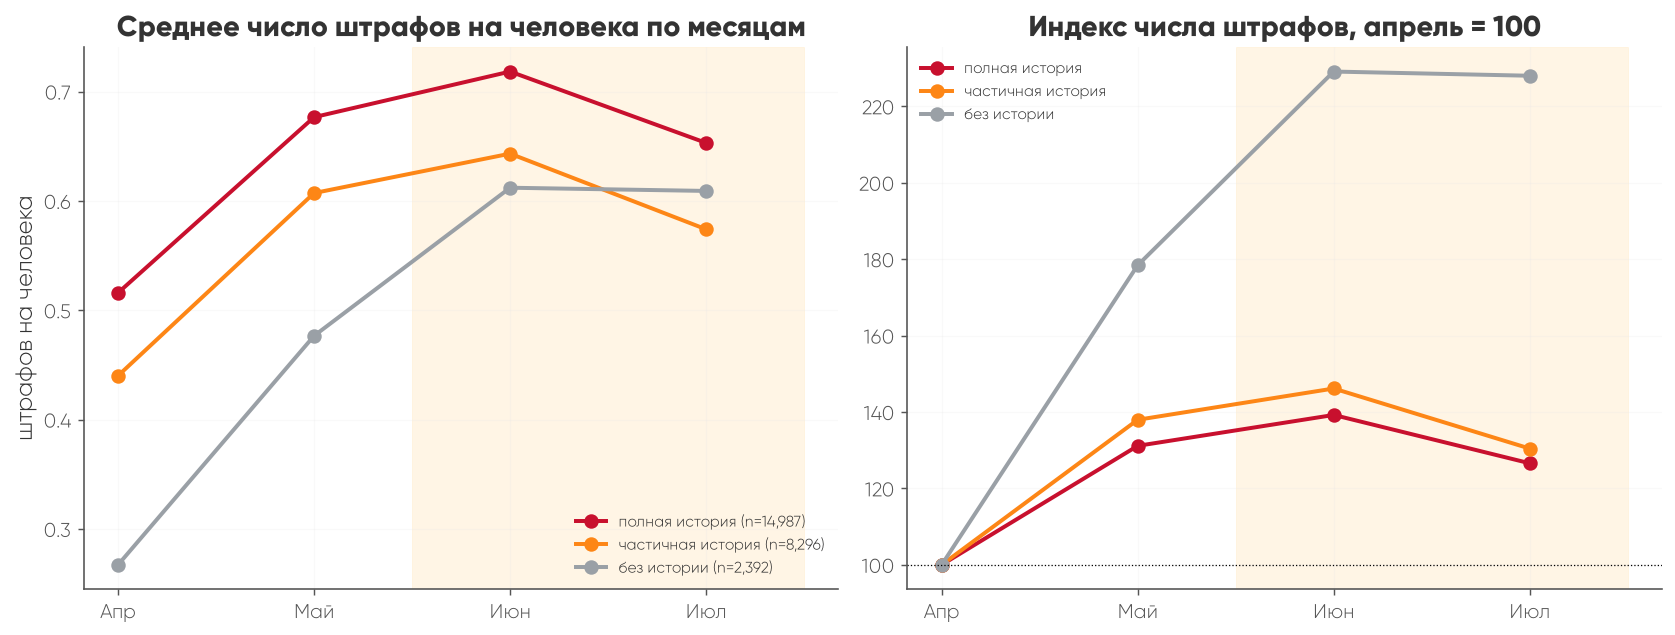

In [17]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY, ORANGE = '#1F6FEB', '#C8102E', '#9AA0A6', '#FD8616'

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

# --- классификация клиентов по полноте истории
cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['группа'] = cl.sub_date.apply(classify)
sizes = cl.группа.value_counts()
print('Размеры групп:', dict(sizes))

# --- штрафы 2026 по клиенту и месяцу (апр-июл, чистое окно)
f = fines[fines.dt.between('2026-04-01', '2026-07-31')].merge(cl[['client_id', 'группа']], on='client_id')
f['month'] = f.dt.dt.month

mn = ['Апр', 'Май', 'Июн', 'Июл']
by_month = f.groupby(['группа', 'month']).size().unstack(fill_value=0).reindex(columns=[4, 5, 6, 7])
mean_month = by_month.div(sizes, axis=0)

print('\nСреднее штрафов на человека по месяцам и группам:')
print(mean_month.round(4))

colors = {'полная история': RED, 'частичная история': ORANGE, 'без истории': GREY}

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 1. абсолютные значения
for grp in ['полная история', 'частичная история', 'без истории']:
    ax[0].plot(mn, mean_month.loc[grp], marker='o', ms=7, lw=2.2,
              color=colors[grp], label=f'{grp} (n={sizes[grp]:,})')
ax[0].axvspan(1.5, 3.5, color='orange', alpha=.1)
ax[0].set_ylabel('штрафов на человека')
ax[0].set_title('Среднее число штрафов на человека по месяцам')
ax[0].legend(frameon=False, fontsize=8.5)

# 2. индекс к апрелю = 100 (сопоставимая динамика, разные уровни игнорируем)
idx_month = mean_month.div(mean_month[4], axis=0) * 100
for grp in ['полная история', 'частичная история', 'без истории']:
    ax[1].plot(mn, idx_month.loc[grp], marker='o', ms=7, lw=2.2, color=colors[grp], label=grp)
ax[1].axhline(100, color='k', lw=.7, ls=':')
ax[1].axvspan(1.5, 3.5, color='orange', alpha=.1)
ax[1].set_title('Индекс числа штрафов, апрель = 100')
ax[1].legend(frameon=False, fontsize=8.5)

plt.tight_layout()
plt.show()

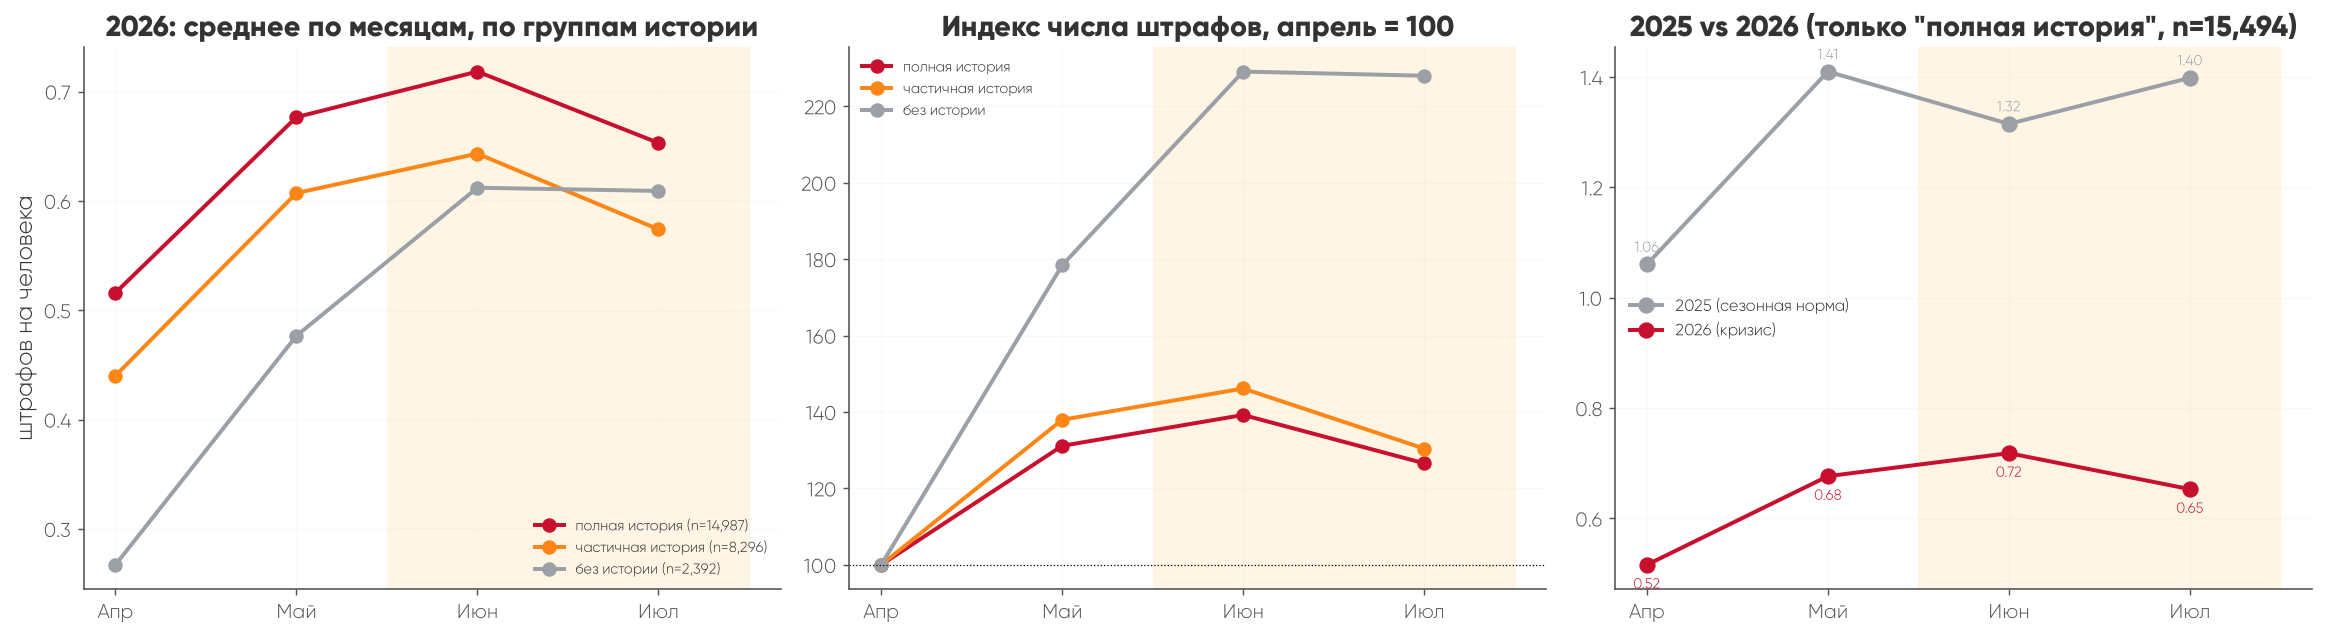

Отношение 2026/2025 по месяцам (полная история):
month
4    0.486
5    0.480
6    0.546
7    0.467
dtype: float64


In [20]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY, ORANGE = '#1F6FEB', '#C8102E', '#9AA0A6', '#FD8616'

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

# --- классификация клиентов по полноте истории
cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['группа'] = cl.sub_date.apply(classify)
sizes = cl.группа.value_counts()
mn = ['Апр', 'Май', 'Июн', 'Июл']

# --- 2026: штрафы по клиенту и месяцу
f = fines[fines.dt.between('2026-04-01', '2026-07-31')].merge(cl[['client_id', 'группа']], on='client_id')
f['month'] = f.dt.dt.month
by_month_26 = f.groupby(['группа', 'month']).size().unstack(fill_value=0).reindex(columns=[4, 5, 6, 7])
mean_month_26 = by_month_26.div(sizes, axis=0)

# --- 2025: только у клиентов с полной историей (иначе некорректно)
cols25 = ['april_2025_fines', 'may_2025_fines', 'jun_2025_fines', 'jul_2025_fines']
base = clients[clients.sub_date < '2025-04-01']
n_full = base.client_id.nunique()
sum25 = base.groupby('client_id')[cols25].sum().sum()
sum25.index = [4, 5, 6, 7]
mean25 = sum25 / n_full

colors = {'полная история': RED, 'частичная история': ORANGE, 'без истории': GREY}

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. абсолютные значения по группам, 2026
for grp in ['полная история', 'частичная история', 'без истории']:
    ax[0].plot(mn, mean_month_26.loc[grp], marker='o', ms=7, lw=2.2,
              color=colors[grp], label=f'{grp} (n={sizes[grp]:,})')
ax[0].axvspan(1.5, 3.5, color='orange', alpha=.1)
ax[0].set_ylabel('штрафов на человека')
ax[0].set_title('2026: среднее по месяцам, по группам истории')
ax[0].legend(frameon=False, fontsize=8)

# 2. индекс к апрелю = 100, все группы
idx_26 = mean_month_26.div(mean_month_26[4], axis=0) * 100
for grp in ['полная история', 'частичная история', 'без истории']:
    ax[1].plot(mn, idx_26.loc[grp], marker='o', ms=7, lw=2.2, color=colors[grp], label=grp)
ax[1].axhline(100, color='k', lw=.7, ls=':')
ax[1].axvspan(1.5, 3.5, color='orange', alpha=.1)
ax[1].set_title('Индекс числа штрафов, апрель = 100')
ax[1].legend(frameon=False, fontsize=8)

# 3. сравнение по годам — 2025 vs 2026, только "полная история"
ax[2].plot(mn, mean25.values, marker='o', ms=8, lw=2.2, color=GREY, label='2025 (сезонная норма)')
ax[2].plot(mn, mean_month_26.loc['полная история'].values, marker='o', ms=8, lw=2.2, color=RED, label='2026 (кризис)')
ax[2].axvspan(1.5, 3.5, color='orange', alpha=.1)
ax[2].set_title(f'2025 vs 2026 (только "полная история", n={n_full:,})')
ax[2].legend(frameon=False, fontsize=9)
for i, (v1, v2) in enumerate(zip(mean25, mean_month_26.loc['полная история'])):
    ax[2].annotate(f'{v1:.2f}', (i, v1), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8, color=GREY)
    ax[2].annotate(f'{v2:.2f}', (i, v2), xytext=(0, -13), textcoords='offset points', ha='center', fontsize=8, color=RED)

plt.tight_layout()
plt.show()

print('Отношение 2026/2025 по месяцам (полная история):')
print((mean_month_26.loc['полная история'] / mean25).round(3))

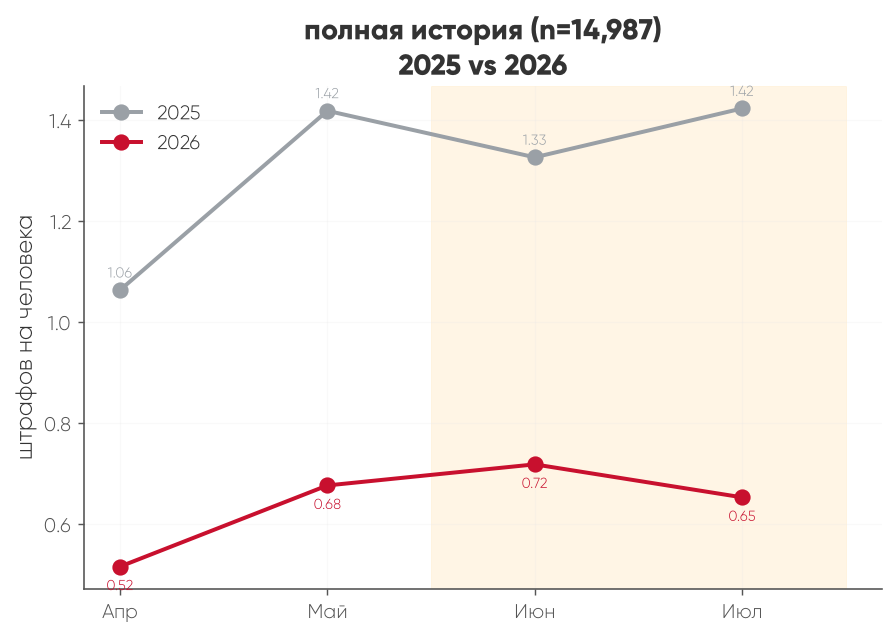

findfont: Failed to find font weight regular for Gilroy, now using 300.


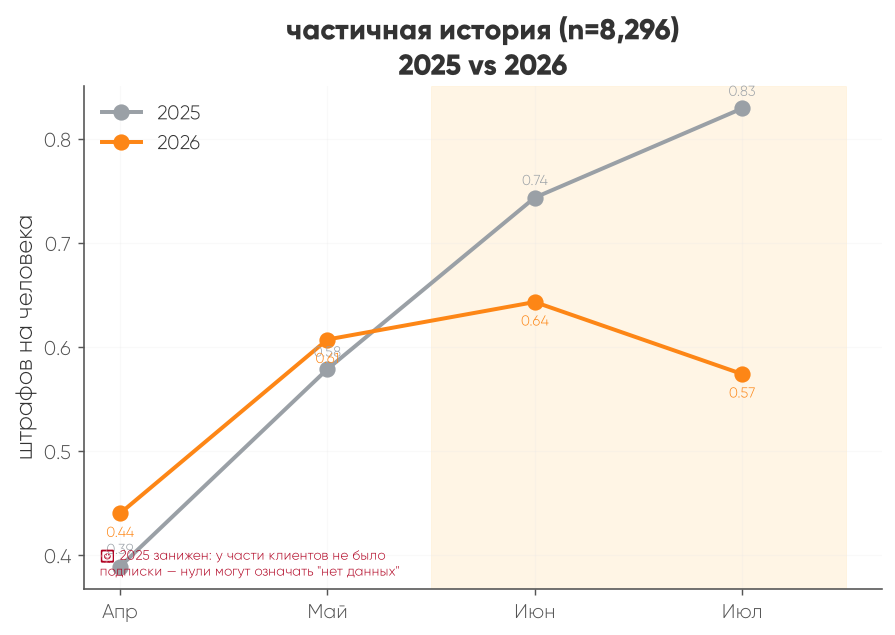

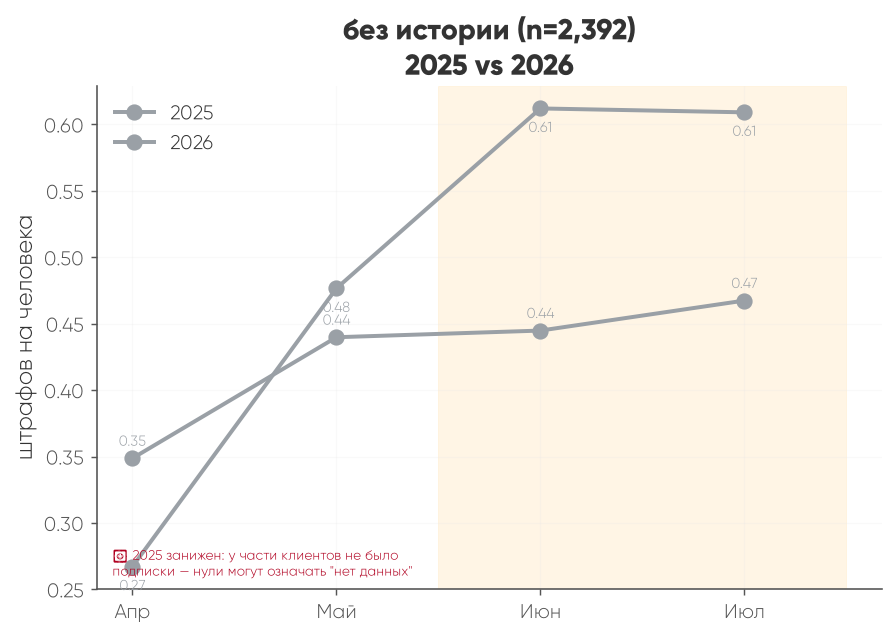

Отношение 2026/2025 по месяцам, по группам:
month                  4      5      6      7
группа                                       
без истории        0.766  1.084  1.376  1.303
полная история     0.485  0.477  0.542  0.459
частичная история  1.131  1.049  0.865  0.692


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY, ORANGE = '#1F6FEB', '#C8102E', '#9AA0A6', '#FD8616'

U = 'uploads/'
clients = pd.read_csv(U + 'clients_demographics.csv', sep=';', decimal=',')
fines   = pd.read_csv(U + 'fines_2026.csv', sep=';', decimal=',')
fines['dt'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

# --- классификация клиентов по полноте истории
cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['группа'] = cl.sub_date.apply(classify)
sizes = cl.группа.value_counts()
mn = ['Апр', 'Май', 'Июн', 'Июл']

# --- 2026: штрафы по клиенту и месяцу, по группам
f = fines[fines.dt.between('2026-04-01', '2026-07-31')].merge(cl[['client_id', 'группа']], on='client_id')
f['month'] = f.dt.dt.month
by_month_26 = f.groupby(['группа', 'month']).size().unstack(fill_value=0).reindex(columns=[4, 5, 6, 7])
mean_26 = by_month_26.div(sizes, axis=0)

# --- 2025: по тем же группам (для частичной/без истории данные будут заниженными — это отдельно поясняем)
cols25 = ['april_2025_fines', 'may_2025_fines', 'jun_2025_fines', 'jul_2025_fines']
clients_g = clients.merge(cl[['client_id', 'группа']], on='client_id')
sum25 = clients_g.groupby(['группа', 'client_id'])[cols25].sum().groupby('группа').sum()
sum25.columns = [4, 5, 6, 7]
mean_25 = sum25.div(sizes, axis=0)

colors = {'полная история': RED, 'частичная история': ORANGE, 'без истории': GREY}
reliable = {'полная история': True, 'частичная история': False, 'без истории': False}

# --- отдельный график на каждую группу: 2025 vs 2026
for grp in ['полная история', 'частичная история', 'без истории']:
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(mn, mean_25.loc[grp].values, marker='o', ms=8, lw=2.2, color=GREY, label='2025')
    ax.plot(mn, mean_26.loc[grp].values, marker='o', ms=8, lw=2.2, color=colors[grp], label='2026')
    ax.axvspan(1.5, 3.5, color='orange', alpha=.1)
    ax.set_ylabel('штрафов на человека')
    ax.set_title(f'{grp} (n={sizes[grp]:,})\n2025 vs 2026')
    ax.legend(frameon=False)
    for i, (v1, v2) in enumerate(zip(mean_25.loc[grp], mean_26.loc[grp])):
        ax.annotate(f'{v1:.2f}', (i, v1), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8, color=GREY)
        ax.annotate(f'{v2:.2f}', (i, v2), xytext=(0, -13), textcoords='offset points', ha='center', fontsize=8, color=colors[grp])
    if not reliable[grp]:
        ax.text(0.02, 0.02, '⚠ 2025 занижен: у части клиентов не было\nподписки — нули могут означать "нет данных"',
               transform=ax.transAxes, fontsize=7.5, color='#B00020', va='bottom')
    plt.tight_layout()
    plt.show()

print('Отношение 2026/2025 по месяцам, по группам:')
print((mean_26 / mean_25).round(3))

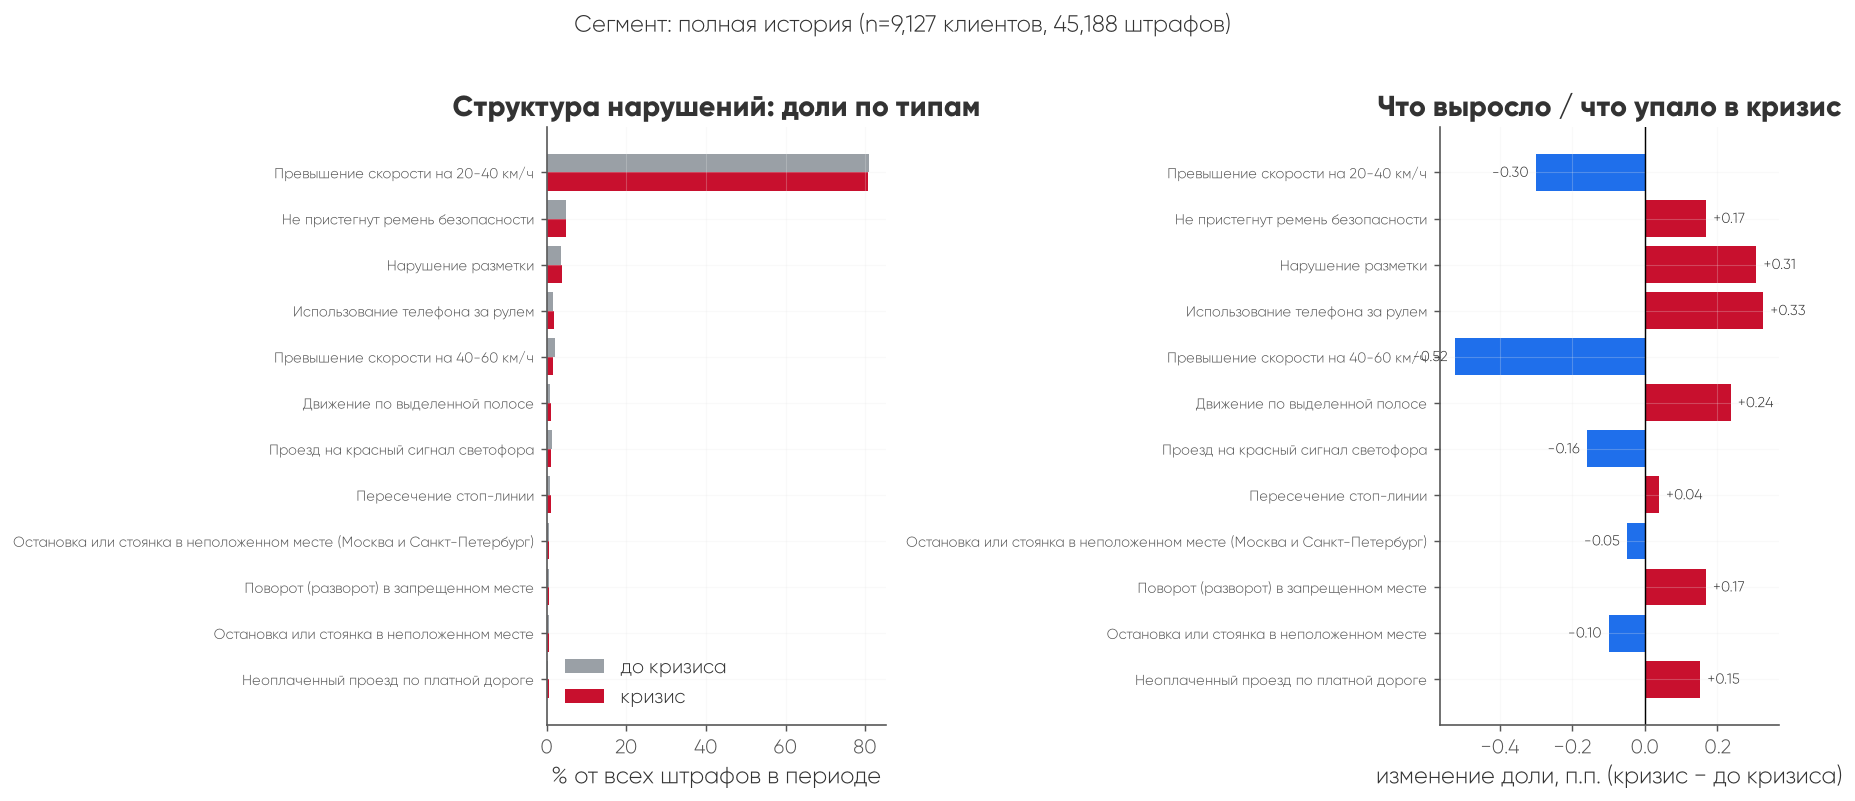

полная история: хи-квадрат на структуру нарушений: chi2=92.1, p=3.09e-10



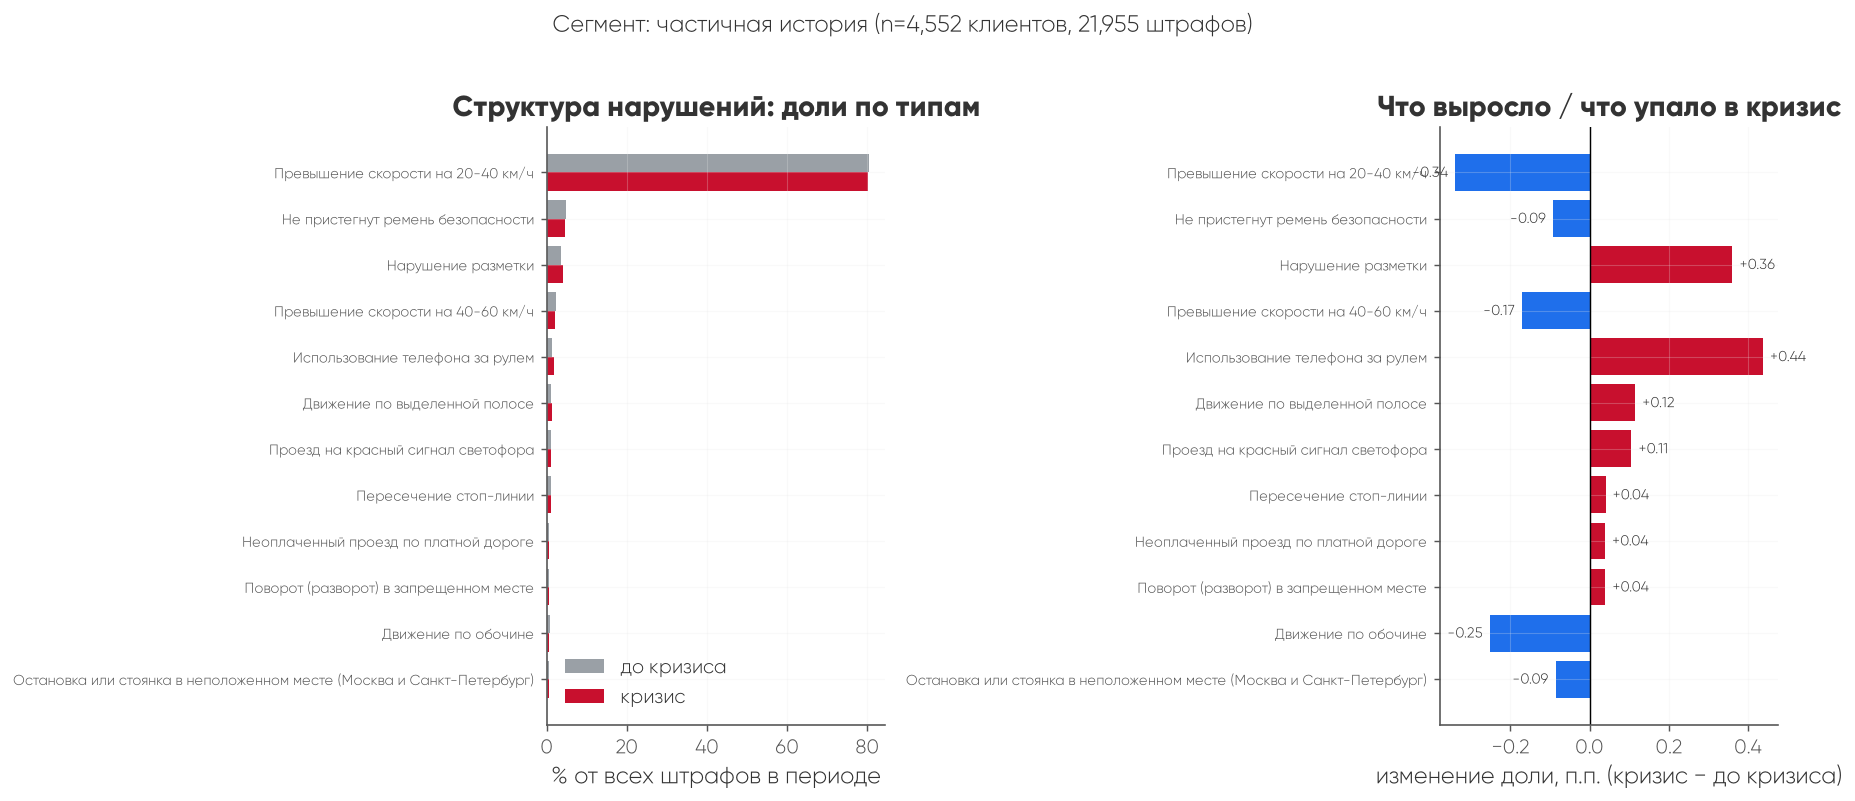

частичная история: хи-квадрат на структуру нарушений: chi2=52.2, p=1.81e-04



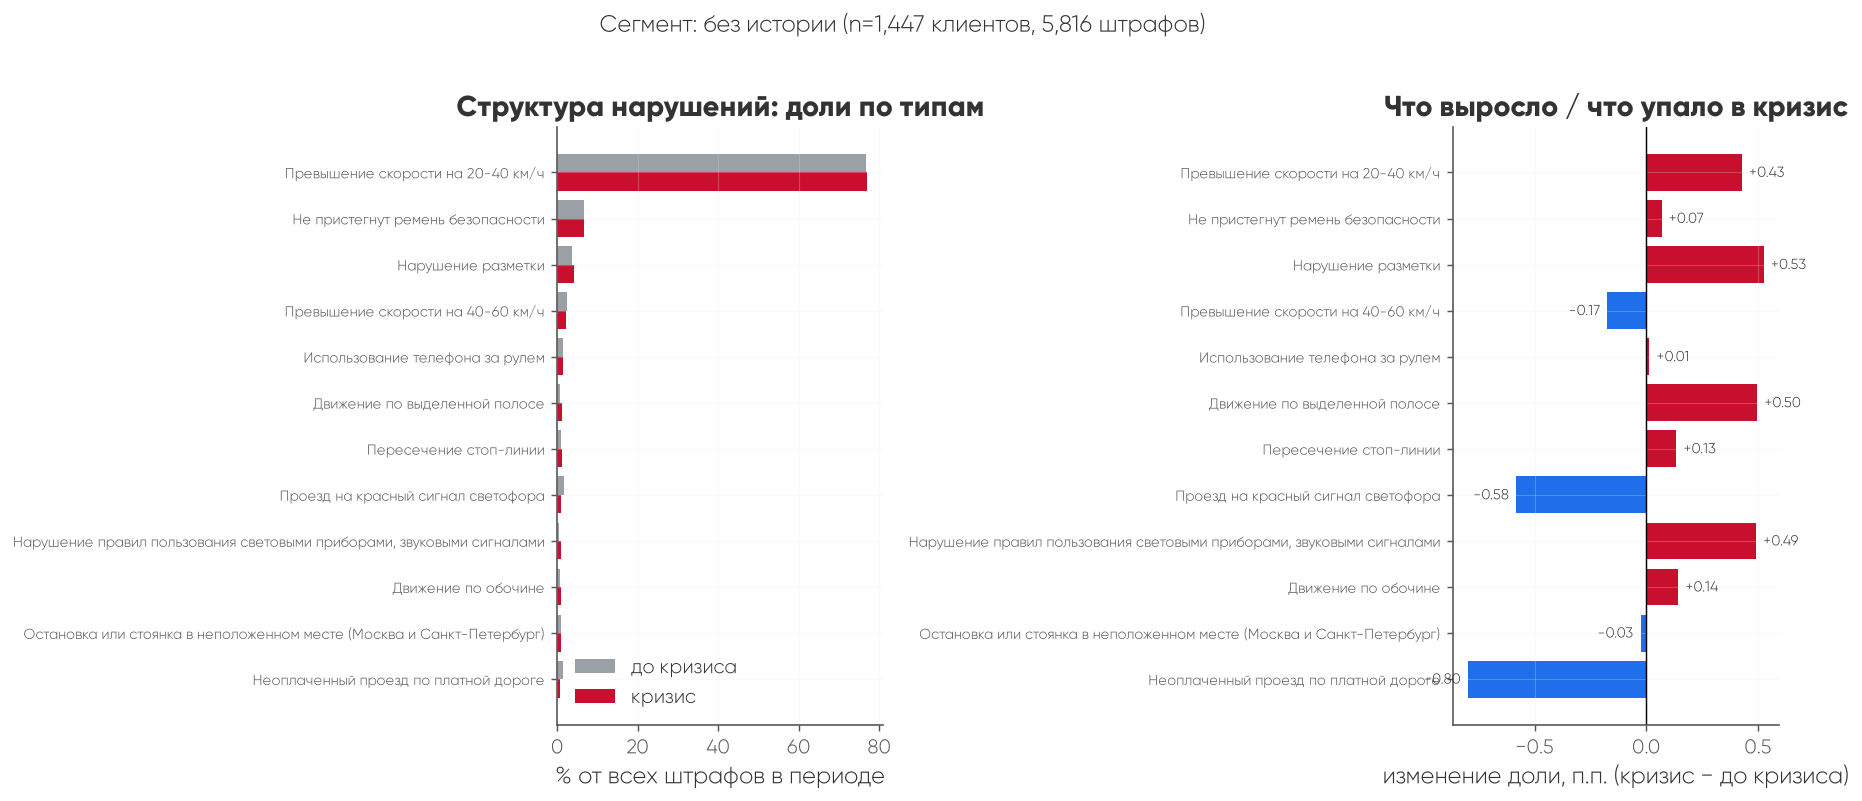

без истории: хи-квадрат на структуру нарушений: chi2=45.6, p=1.44e-03



In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

# --- на всякий случай приводим дату к datetime
fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

# --- классификация клиентов по времени подключения подписки
cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['сегмент'] = cl.sub_date.apply(classify)

f_all = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(cl[['client_id', 'сегмент']], on='client_id', how='inner')
f_all['период'] = np.where(f_all.bill_offence_date.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-авг)')

for seg in ['полная история', 'частичная история', 'без истории']:
    f = f_all[f_all.сегмент == seg]
    n = f.client_id.nunique()

    ct = pd.crosstab(f.offence_short_statement, f.период, normalize='columns') * 100
    ct['разница_пп'] = ct['кризис (июн-авг)'] - ct['до кризиса (апр-май)']
    ct = ct.sort_values('кризис (июн-авг)', ascending=False).head(12)

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Сегмент: {seg} (n={n:,} клиентов, {len(f):,} штрафов)', fontsize=13, y=1.02)

    y = np.arange(len(ct))
    ax[0].barh(y - .2, ct['до кризиса (апр-май)'], height=.4, color=GREY, label='до кризиса')
    ax[0].barh(y + .2, ct['кризис (июн-авг)'], height=.4, color=RED, label='кризис')
    ax[0].set_yticks(y); ax[0].set_yticklabels(ct.index, fontsize=8)
    ax[0].invert_yaxis()
    ax[0].set_xlabel('% от всех штрафов в периоде'); ax[0].set_title('Структура нарушений: доли по типам')
    ax[0].legend(frameon=False)

    colors = [RED if v > 0 else BLUE for v in ct['разница_пп']]
    ax[1].barh(y, ct['разница_пп'], color=colors)
    ax[1].set_yticks(y); ax[1].set_yticklabels(ct.index, fontsize=8)
    ax[1].invert_yaxis()
    ax[1].axvline(0, color='k', lw=.8)
    ax[1].set_xlabel('изменение доли, п.п. (кризис − до кризиса)')
    ax[1].set_title('Что выросло / что упало в кризис')
    for i, v in enumerate(ct['разница_пп']):
        ax[1].annotate(f'{v:+.2f}', (v, i), xytext=(4 if v > 0 else -4, 0), textcoords='offset points',
                       va='center', ha='left' if v > 0 else 'right', fontsize=8)

    plt.tight_layout()
    plt.show()

    chi2, pv, _, _ = stats.chi2_contingency(pd.crosstab(f.offence_short_statement, f.период))
    print(f'{seg}: хи-квадрат на структуру нарушений: chi2={chi2:.1f}, p={pv:.2e}\n')

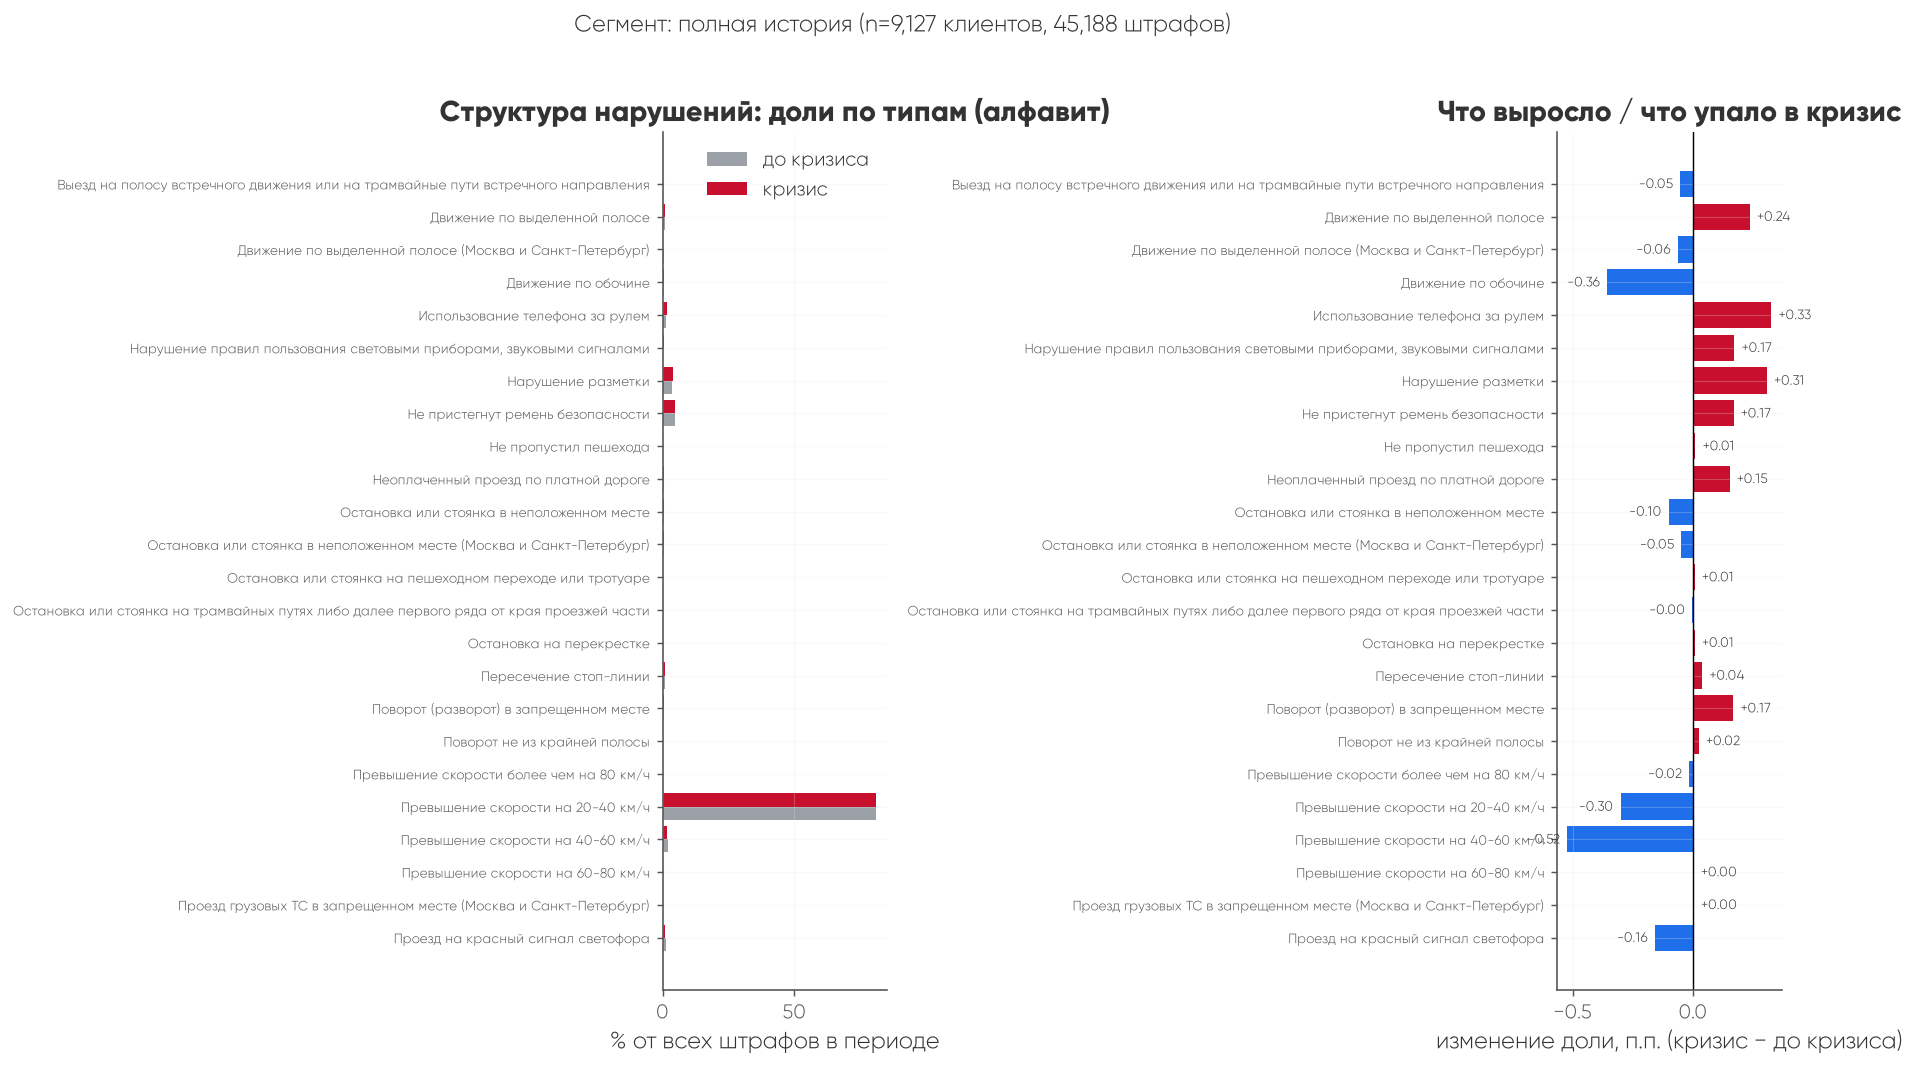

полная история: хи-квадрат на структуру нарушений: chi2=92.1, p=3.09e-10



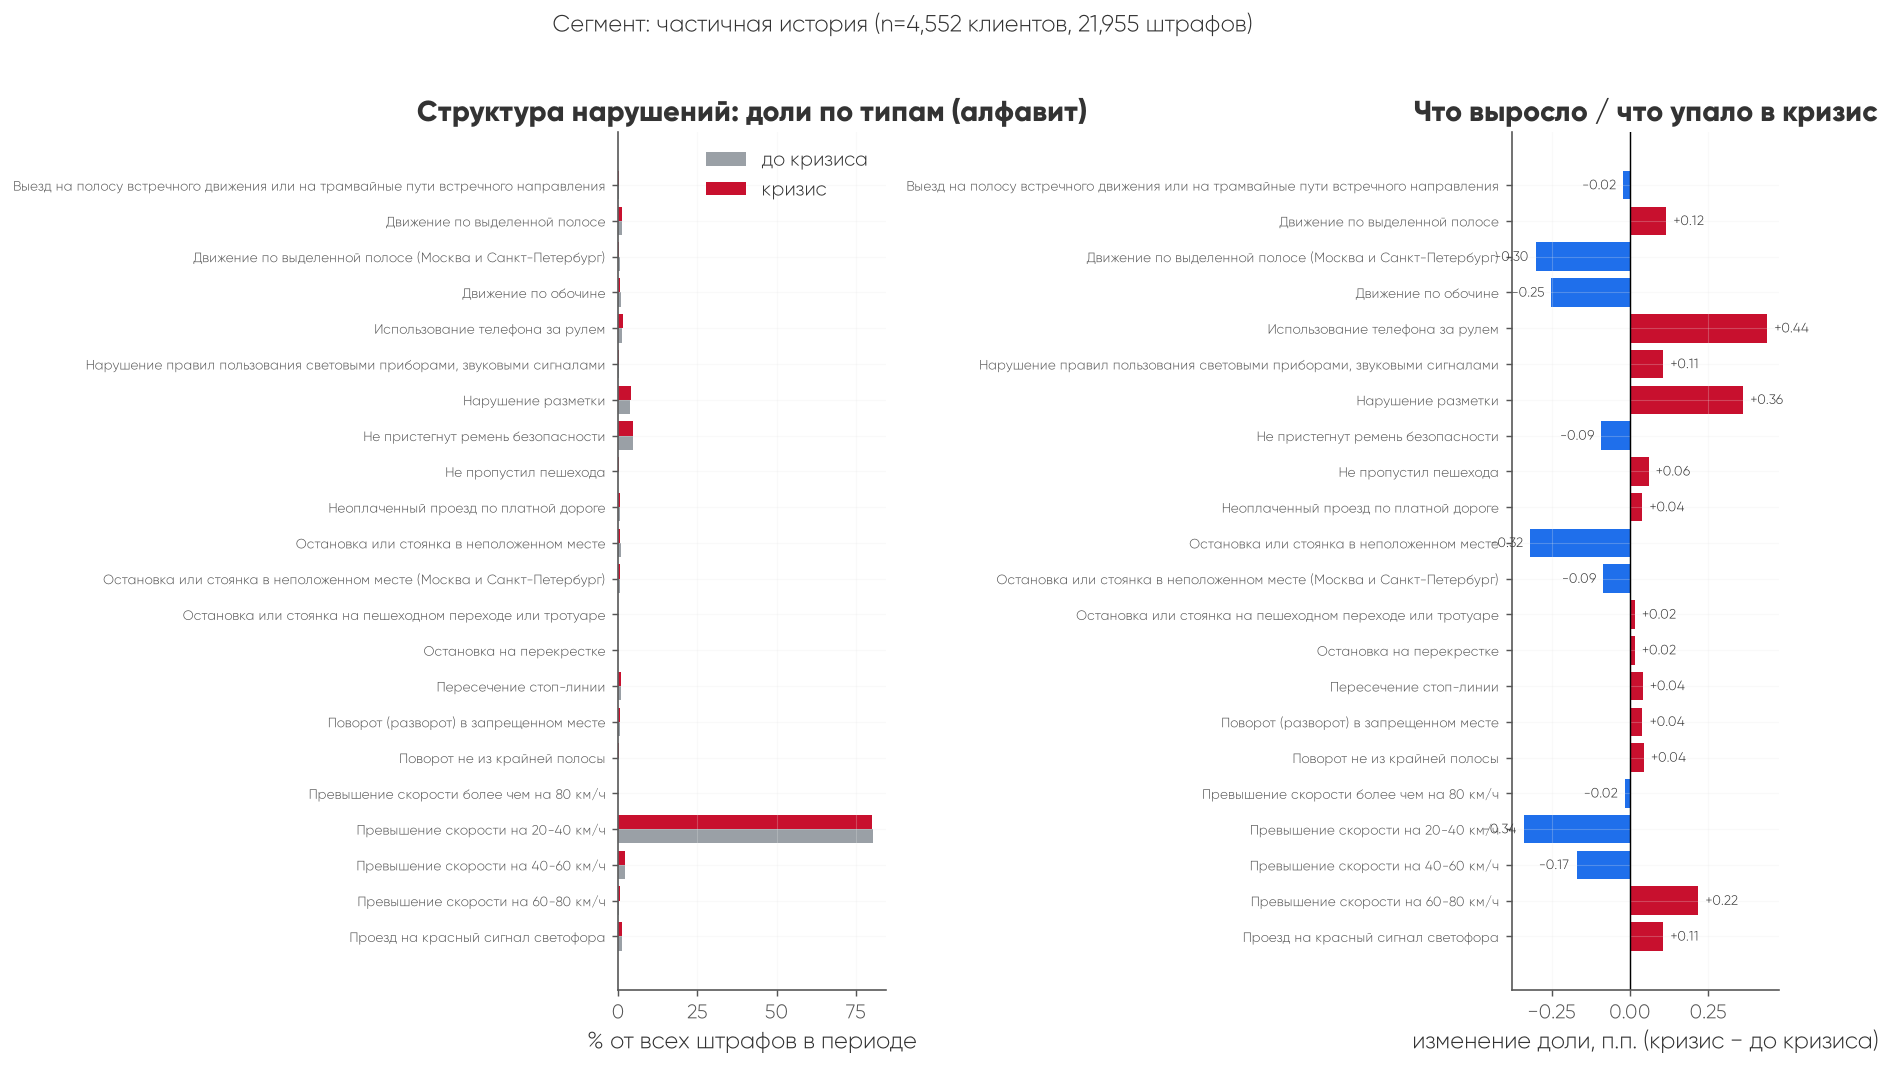

частичная история: хи-квадрат на структуру нарушений: chi2=52.2, p=1.81e-04



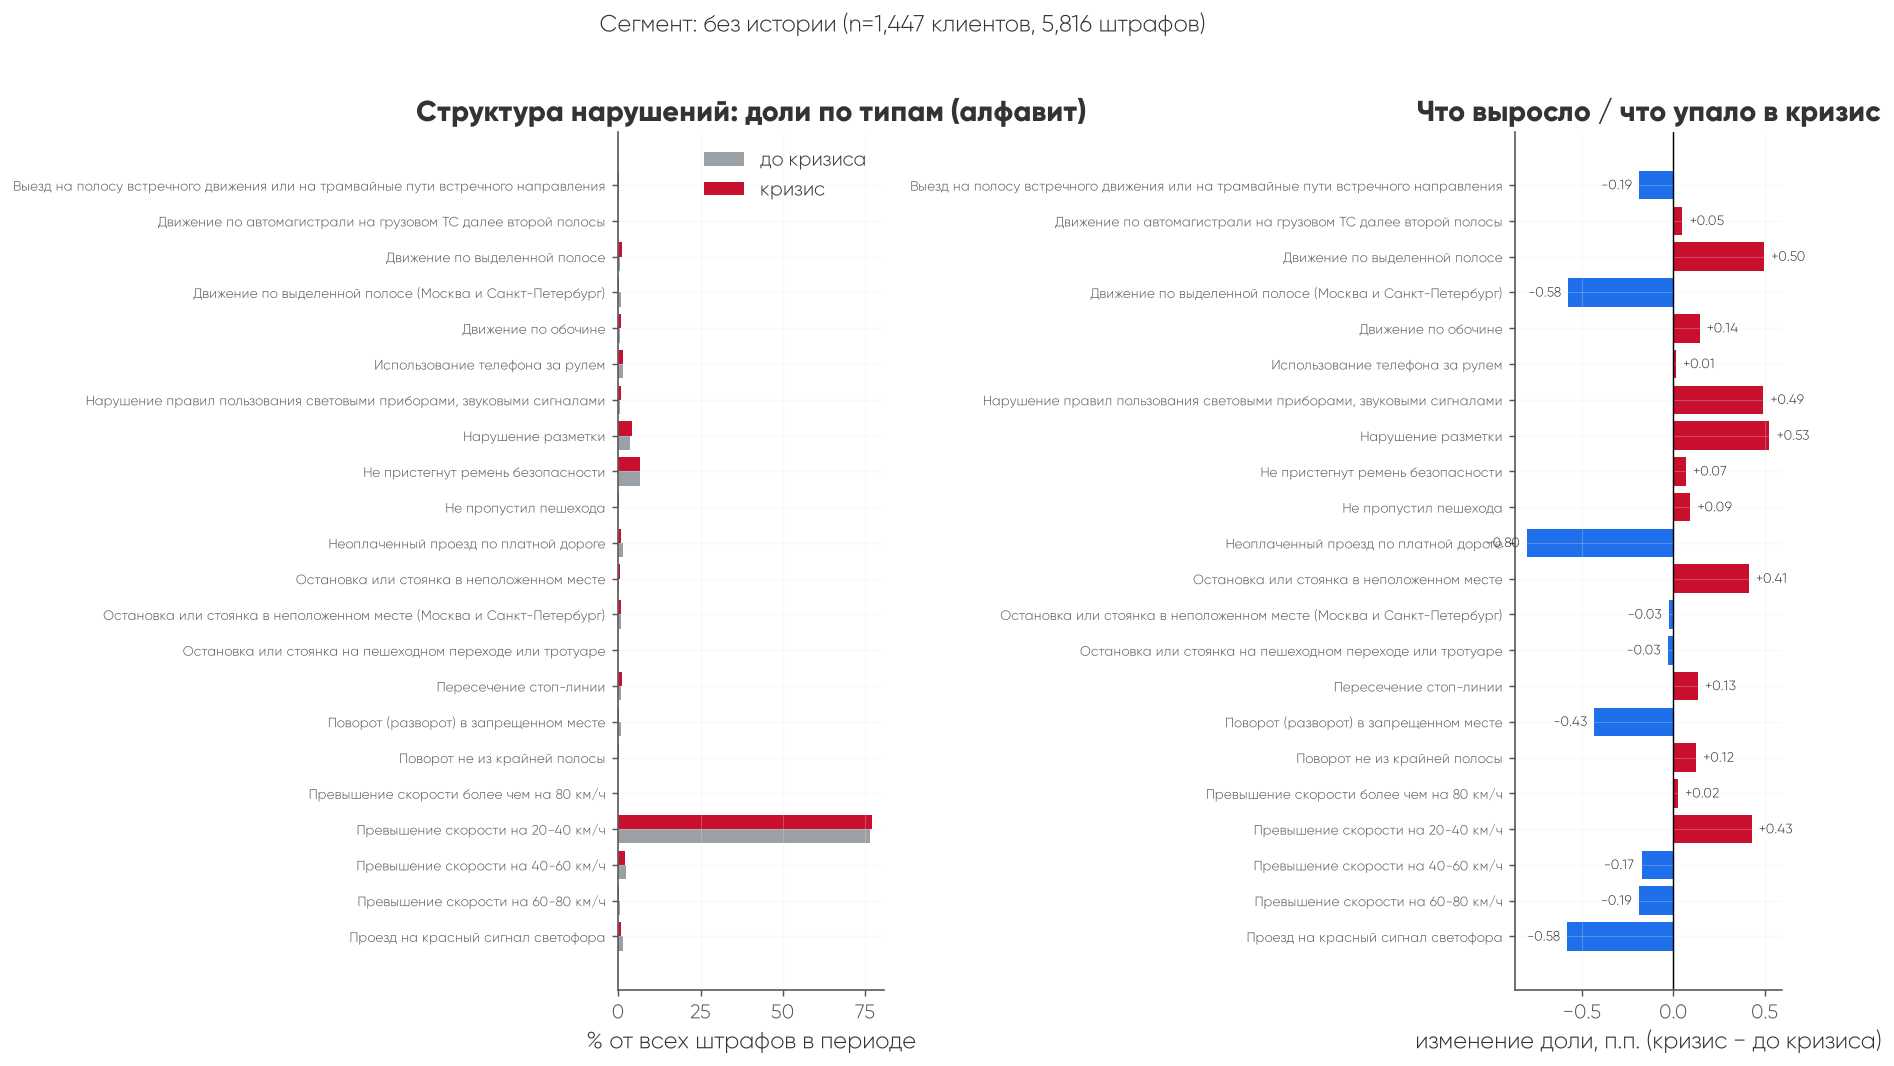

без истории: хи-квадрат на структуру нарушений: chi2=45.6, p=1.44e-03



In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10.5, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['сегмент'] = cl.sub_date.apply(classify)

f_all = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(cl[['client_id', 'сегмент']], on='client_id', how='inner')
f_all['период'] = np.where(f_all.bill_offence_date.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-авг)')

for seg in ['полная история', 'частичная история', 'без истории']:
    f = f_all[f_all.сегмент == seg]
    n = f.client_id.nunique()

    ct = pd.crosstab(f.offence_short_statement, f.период, normalize='columns') * 100
    ct['разница_пп'] = ct['кризис (июн-авг)'] - ct['до кризиса (апр-май)']
    ct = ct.sort_index(ascending=False)   # <-- по алфавиту (обратный порядок, т.к. barh рисует снизу вверх)

    fig, ax = plt.subplots(1, 2, figsize=(14, 8))
    fig.suptitle(f'Сегмент: {seg} (n={n:,} клиентов, {len(f):,} штрафов)', fontsize=13, y=1.02)

    y = np.arange(len(ct))
    ax[0].barh(y - .2, ct['до кризиса (апр-май)'], height=.4, color=GREY, label='до кризиса')
    ax[0].barh(y + .2, ct['кризис (июн-авг)'], height=.4, color=RED, label='кризис')
    ax[0].set_yticks(y); ax[0].set_yticklabels(ct.index, fontsize=7.5)
    ax[0].set_xlabel('% от всех штрафов в периоде'); ax[0].set_title('Структура нарушений: доли по типам (алфавит)')
    ax[0].legend(frameon=False)

    colors = [RED if v > 0 else BLUE for v in ct['разница_пп']]
    ax[1].barh(y, ct['разница_пп'], color=colors)
    ax[1].set_yticks(y); ax[1].set_yticklabels(ct.index, fontsize=7.5)
    ax[1].axvline(0, color='k', lw=.8)
    ax[1].set_xlabel('изменение доли, п.п. (кризис − до кризиса)')
    ax[1].set_title('Что выросло / что упало в кризис')
    for i, v in enumerate(ct['разница_пп']):
        ax[1].annotate(f'{v:+.2f}', (v, i), xytext=(4 if v > 0 else -4, 0), textcoords='offset points',
                       va='center', ha='left' if v > 0 else 'right', fontsize=7.5)

    plt.tight_layout()
    plt.show()

    chi2, pv, _, _ = stats.chi2_contingency(pd.crosstab(f.offence_short_statement, f.период))
    print(f'{seg}: хи-квадрат на структуру нарушений: chi2={chi2:.1f}, p={pv:.2e}\n')

findfont: Failed to find font weight regular for Gilroy, now using 300.


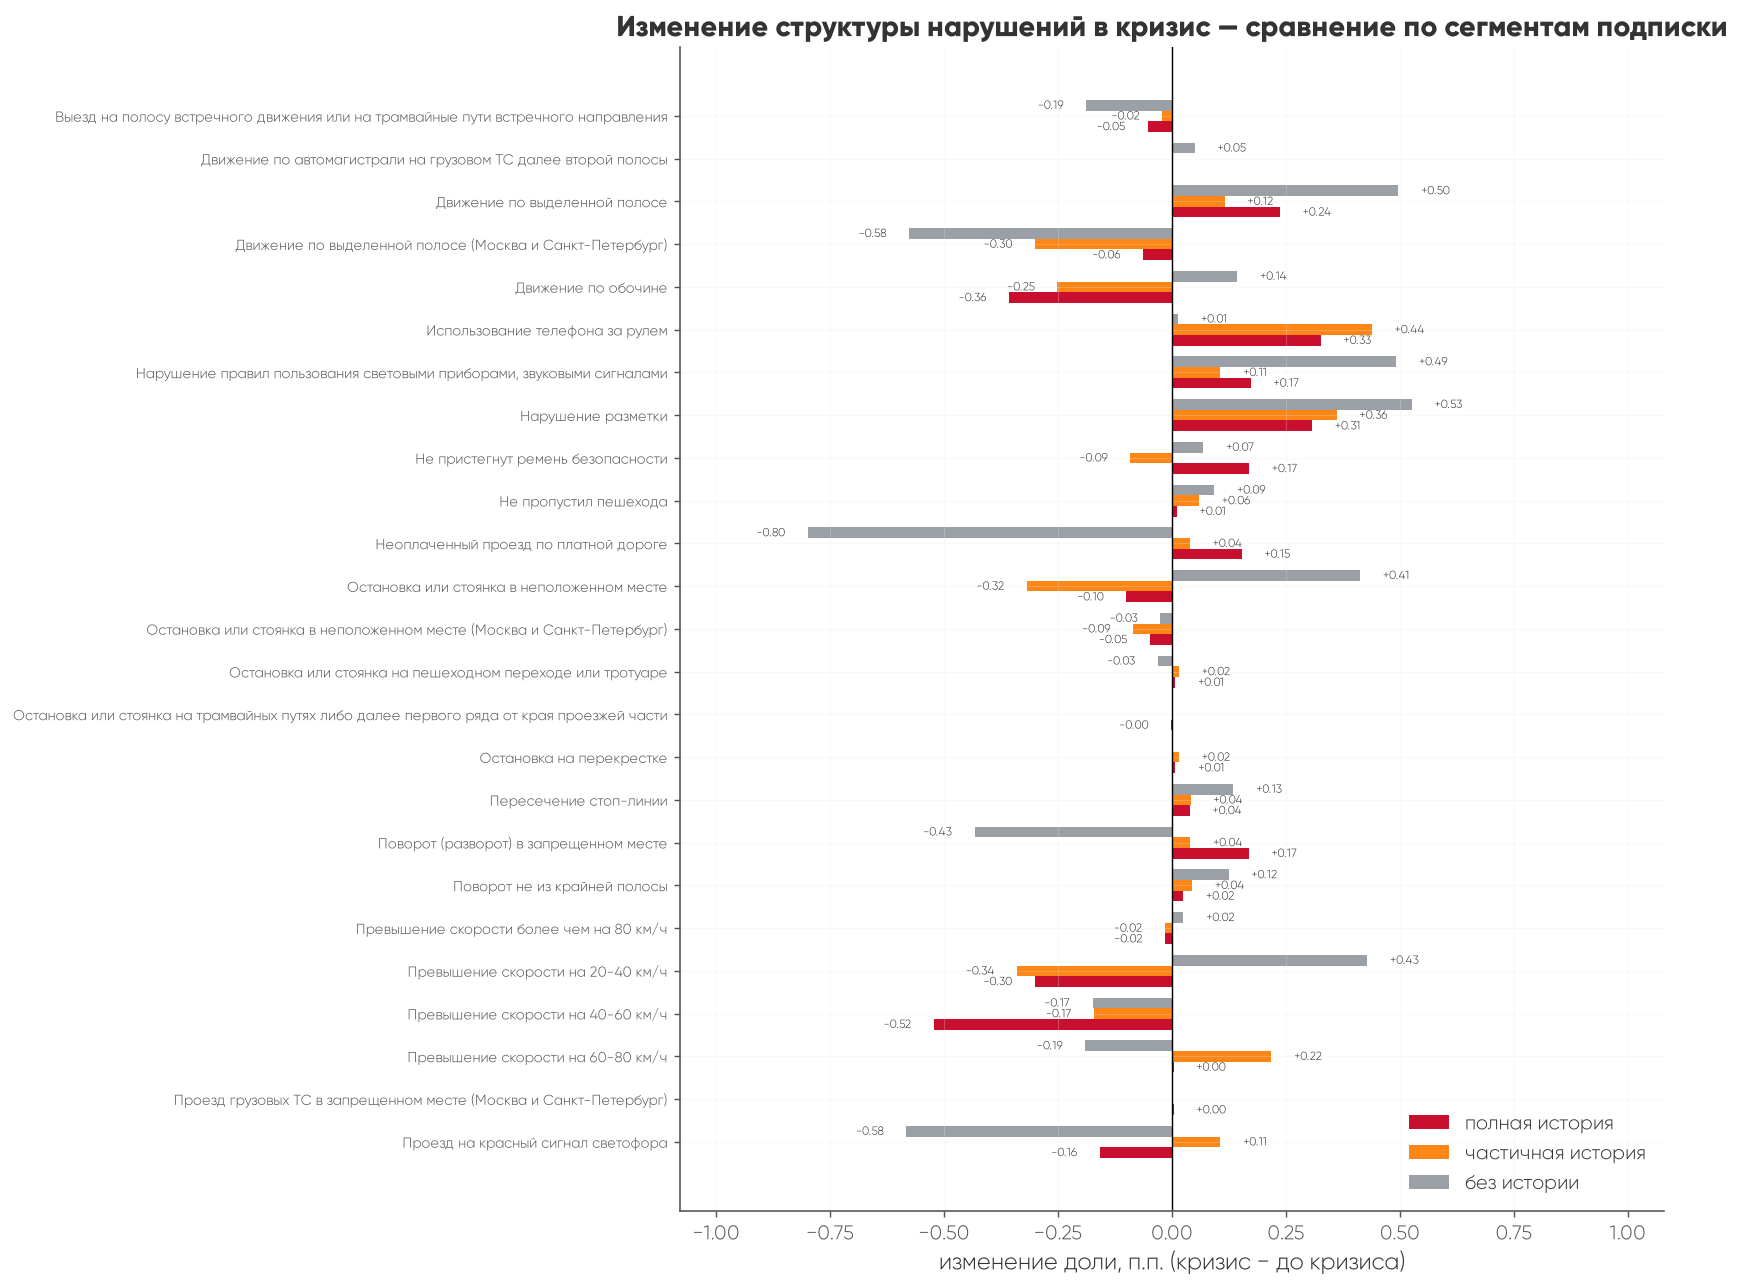

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY, ORANGE = '#1F6FEB', '#C8102E', '#9AA0A6', '#FD8616'

fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['сегмент'] = cl.sub_date.apply(classify)

f_all = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(cl[['client_id', 'сегмент']], on='client_id', how='inner')
f_all['период'] = np.where(f_all.bill_offence_date.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-авг)')

segments = ['полная история', 'частичная история', 'без истории']
deltas = {}
for seg in segments:
    f = f_all[f_all.сегмент == seg]
    ct = pd.crosstab(f.offence_short_statement, f.период, normalize='columns') * 100
    deltas[seg] = ct['кризис (июн-авг)'] - ct['до кризиса (апр-май)']

D = pd.DataFrame(deltas).sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(13, 10))
y = np.arange(len(D))
h = 0.25
colors = {'полная история': RED, 'частичная история': ORANGE, 'без истории': GREY}

for i, seg in enumerate(segments):
    offset = (i - 1) * h
    bars = ax.barh(y + offset, D[seg], height=h, color=colors[seg], label=seg)
    for rect, v in zip(bars, D[seg]):
        va = 'center'
        ha = 'left' if v >= 0 else 'right'
        pad = 0.05 if v >= 0 else -0.05
        ax.annotate(f'{v:+.2f}', (v + pad, rect.get_y() + rect.get_height() / 2),
                   ha=ha, va=va, fontsize=6.5, color='#333333')

ax.set_yticks(y); ax.set_yticklabels(D.index, fontsize=8)
ax.axvline(0, color='k', lw=.8)
ax.set_xlabel('изменение доли, п.п. (кризис − до кризиса)')
ax.set_title('Изменение структуры нарушений в кризис — сравнение по сегментам подписки')
ax.legend(frameon=False, loc='lower right')
# небольшой запас по X, чтобы подписи не обрезались
xmax = D.abs().max().max()
ax.set_xlim(-xmax * 1.35, xmax * 1.35)

plt.tight_layout()
plt.show()

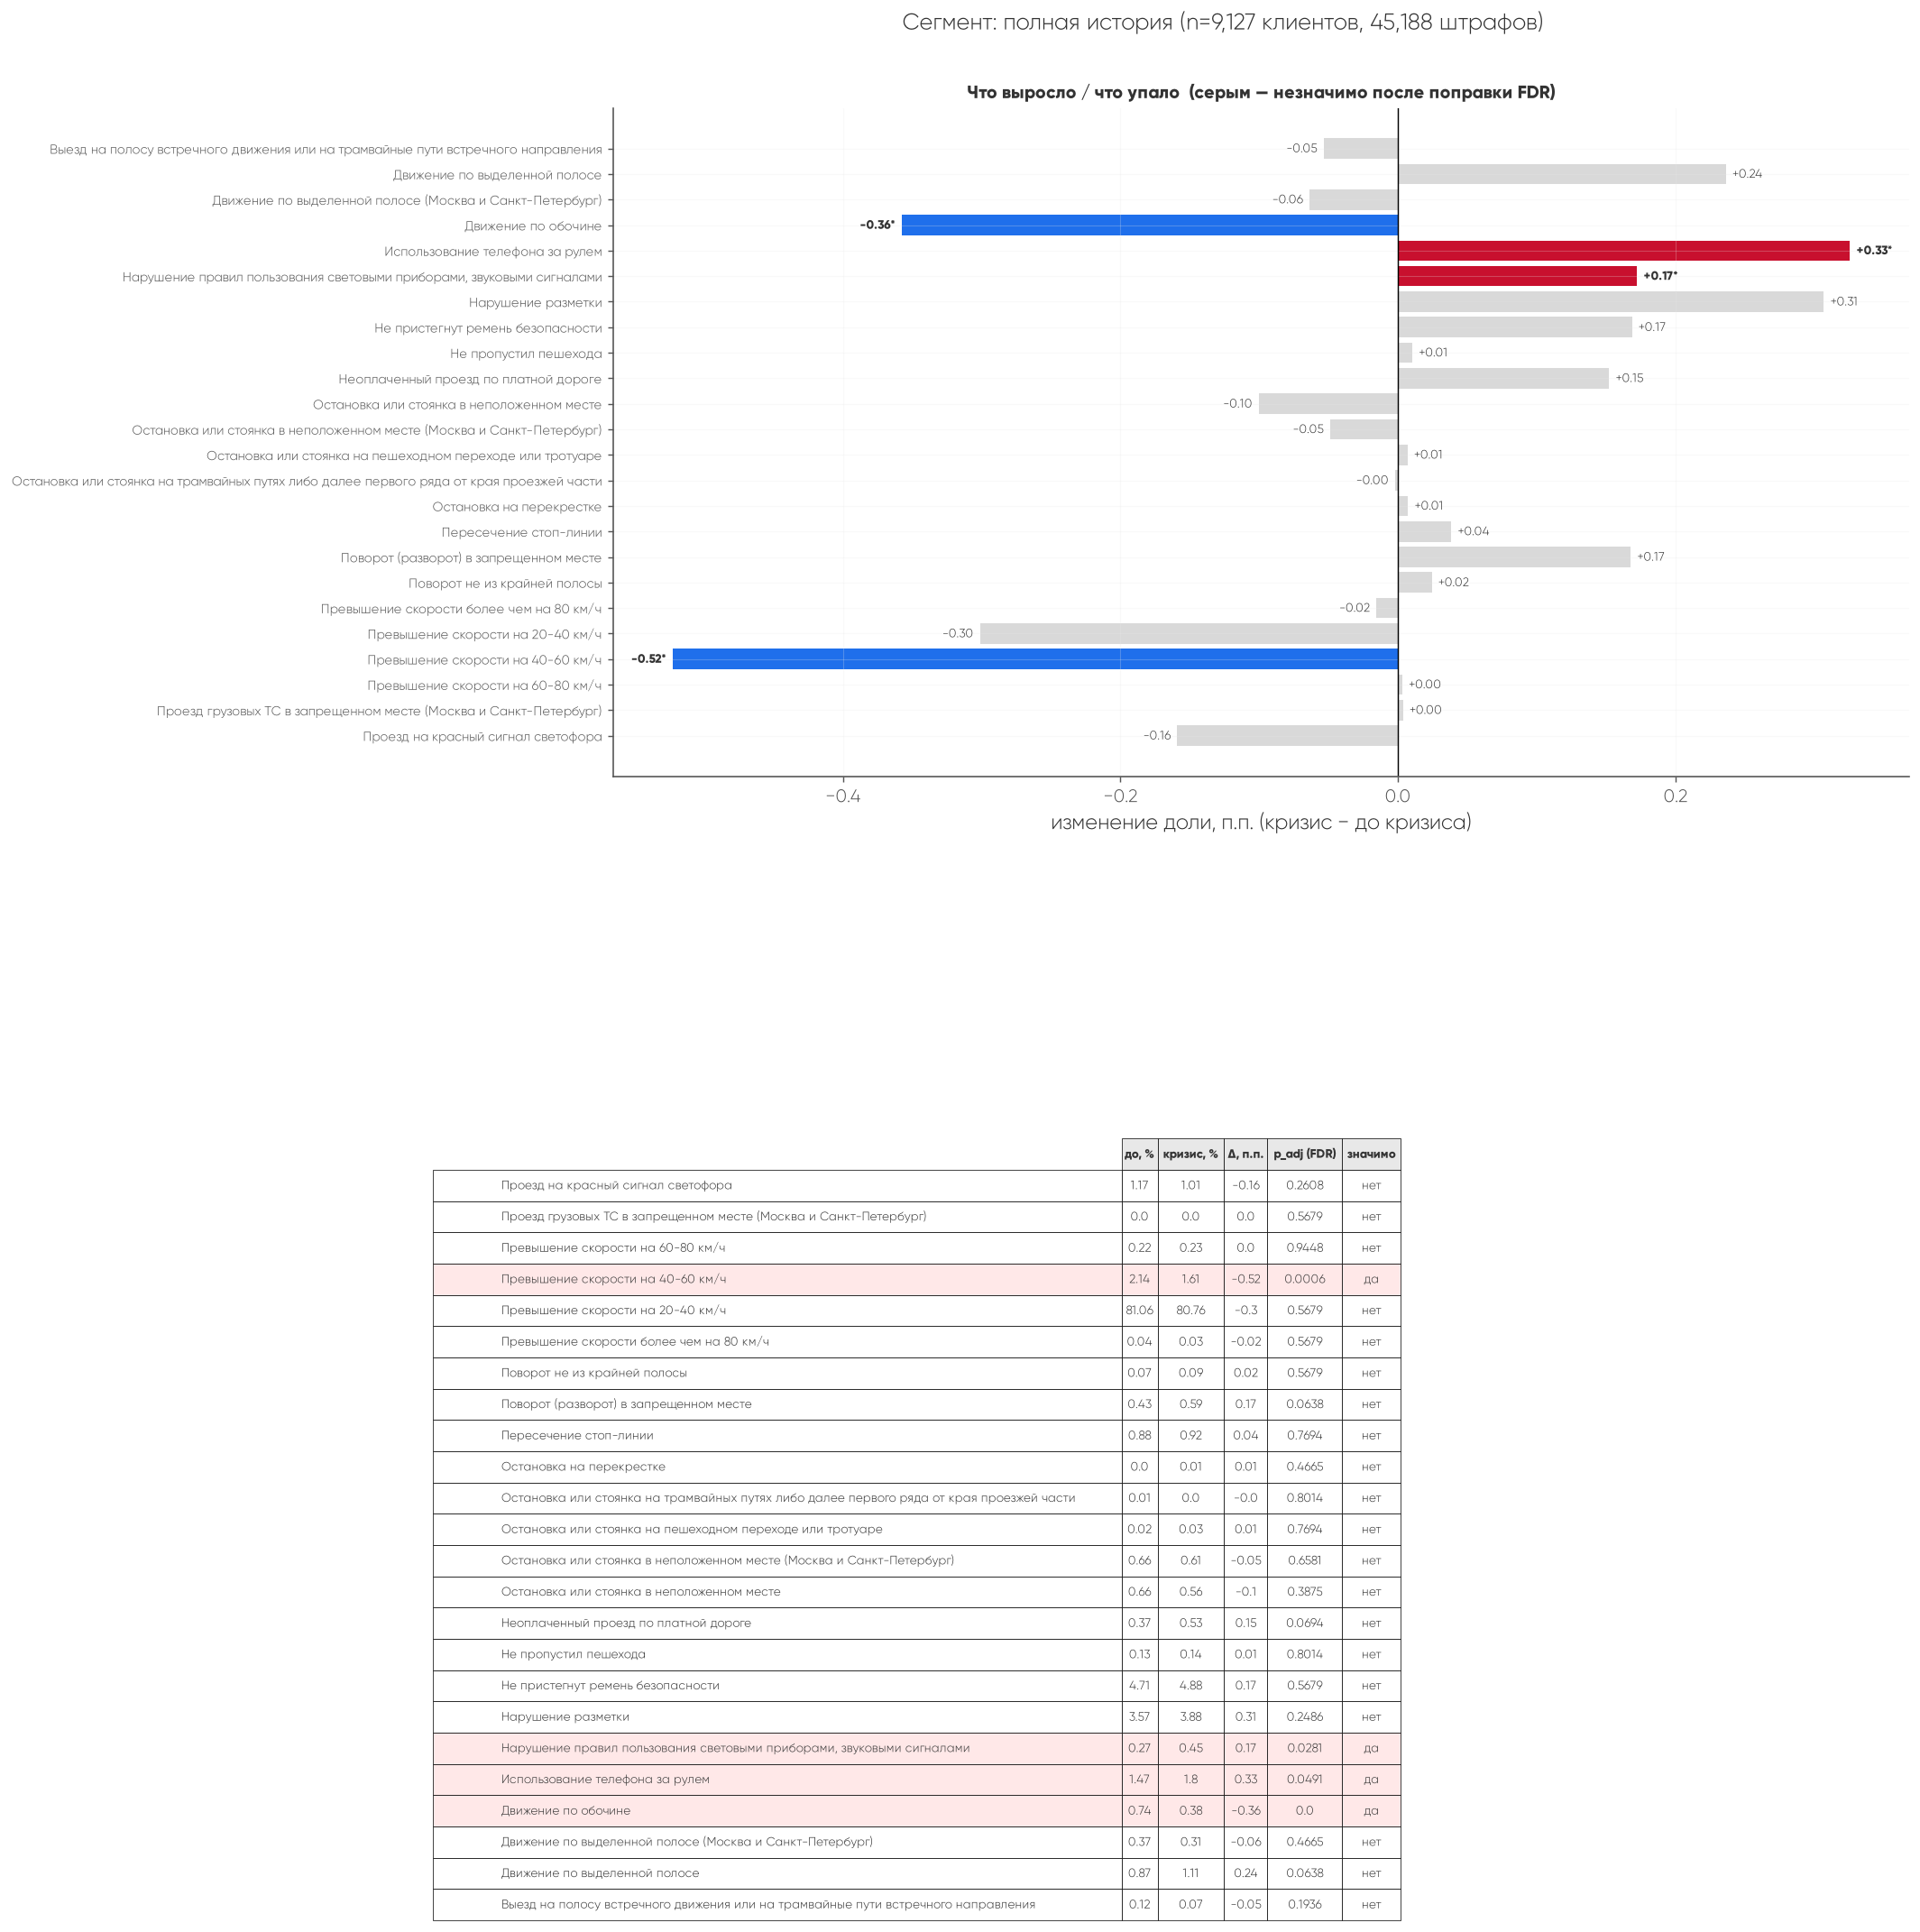

полная история: общий хи-квадрат chi2=92.1, p=3.09e-10; значимых типов: 4 из 24


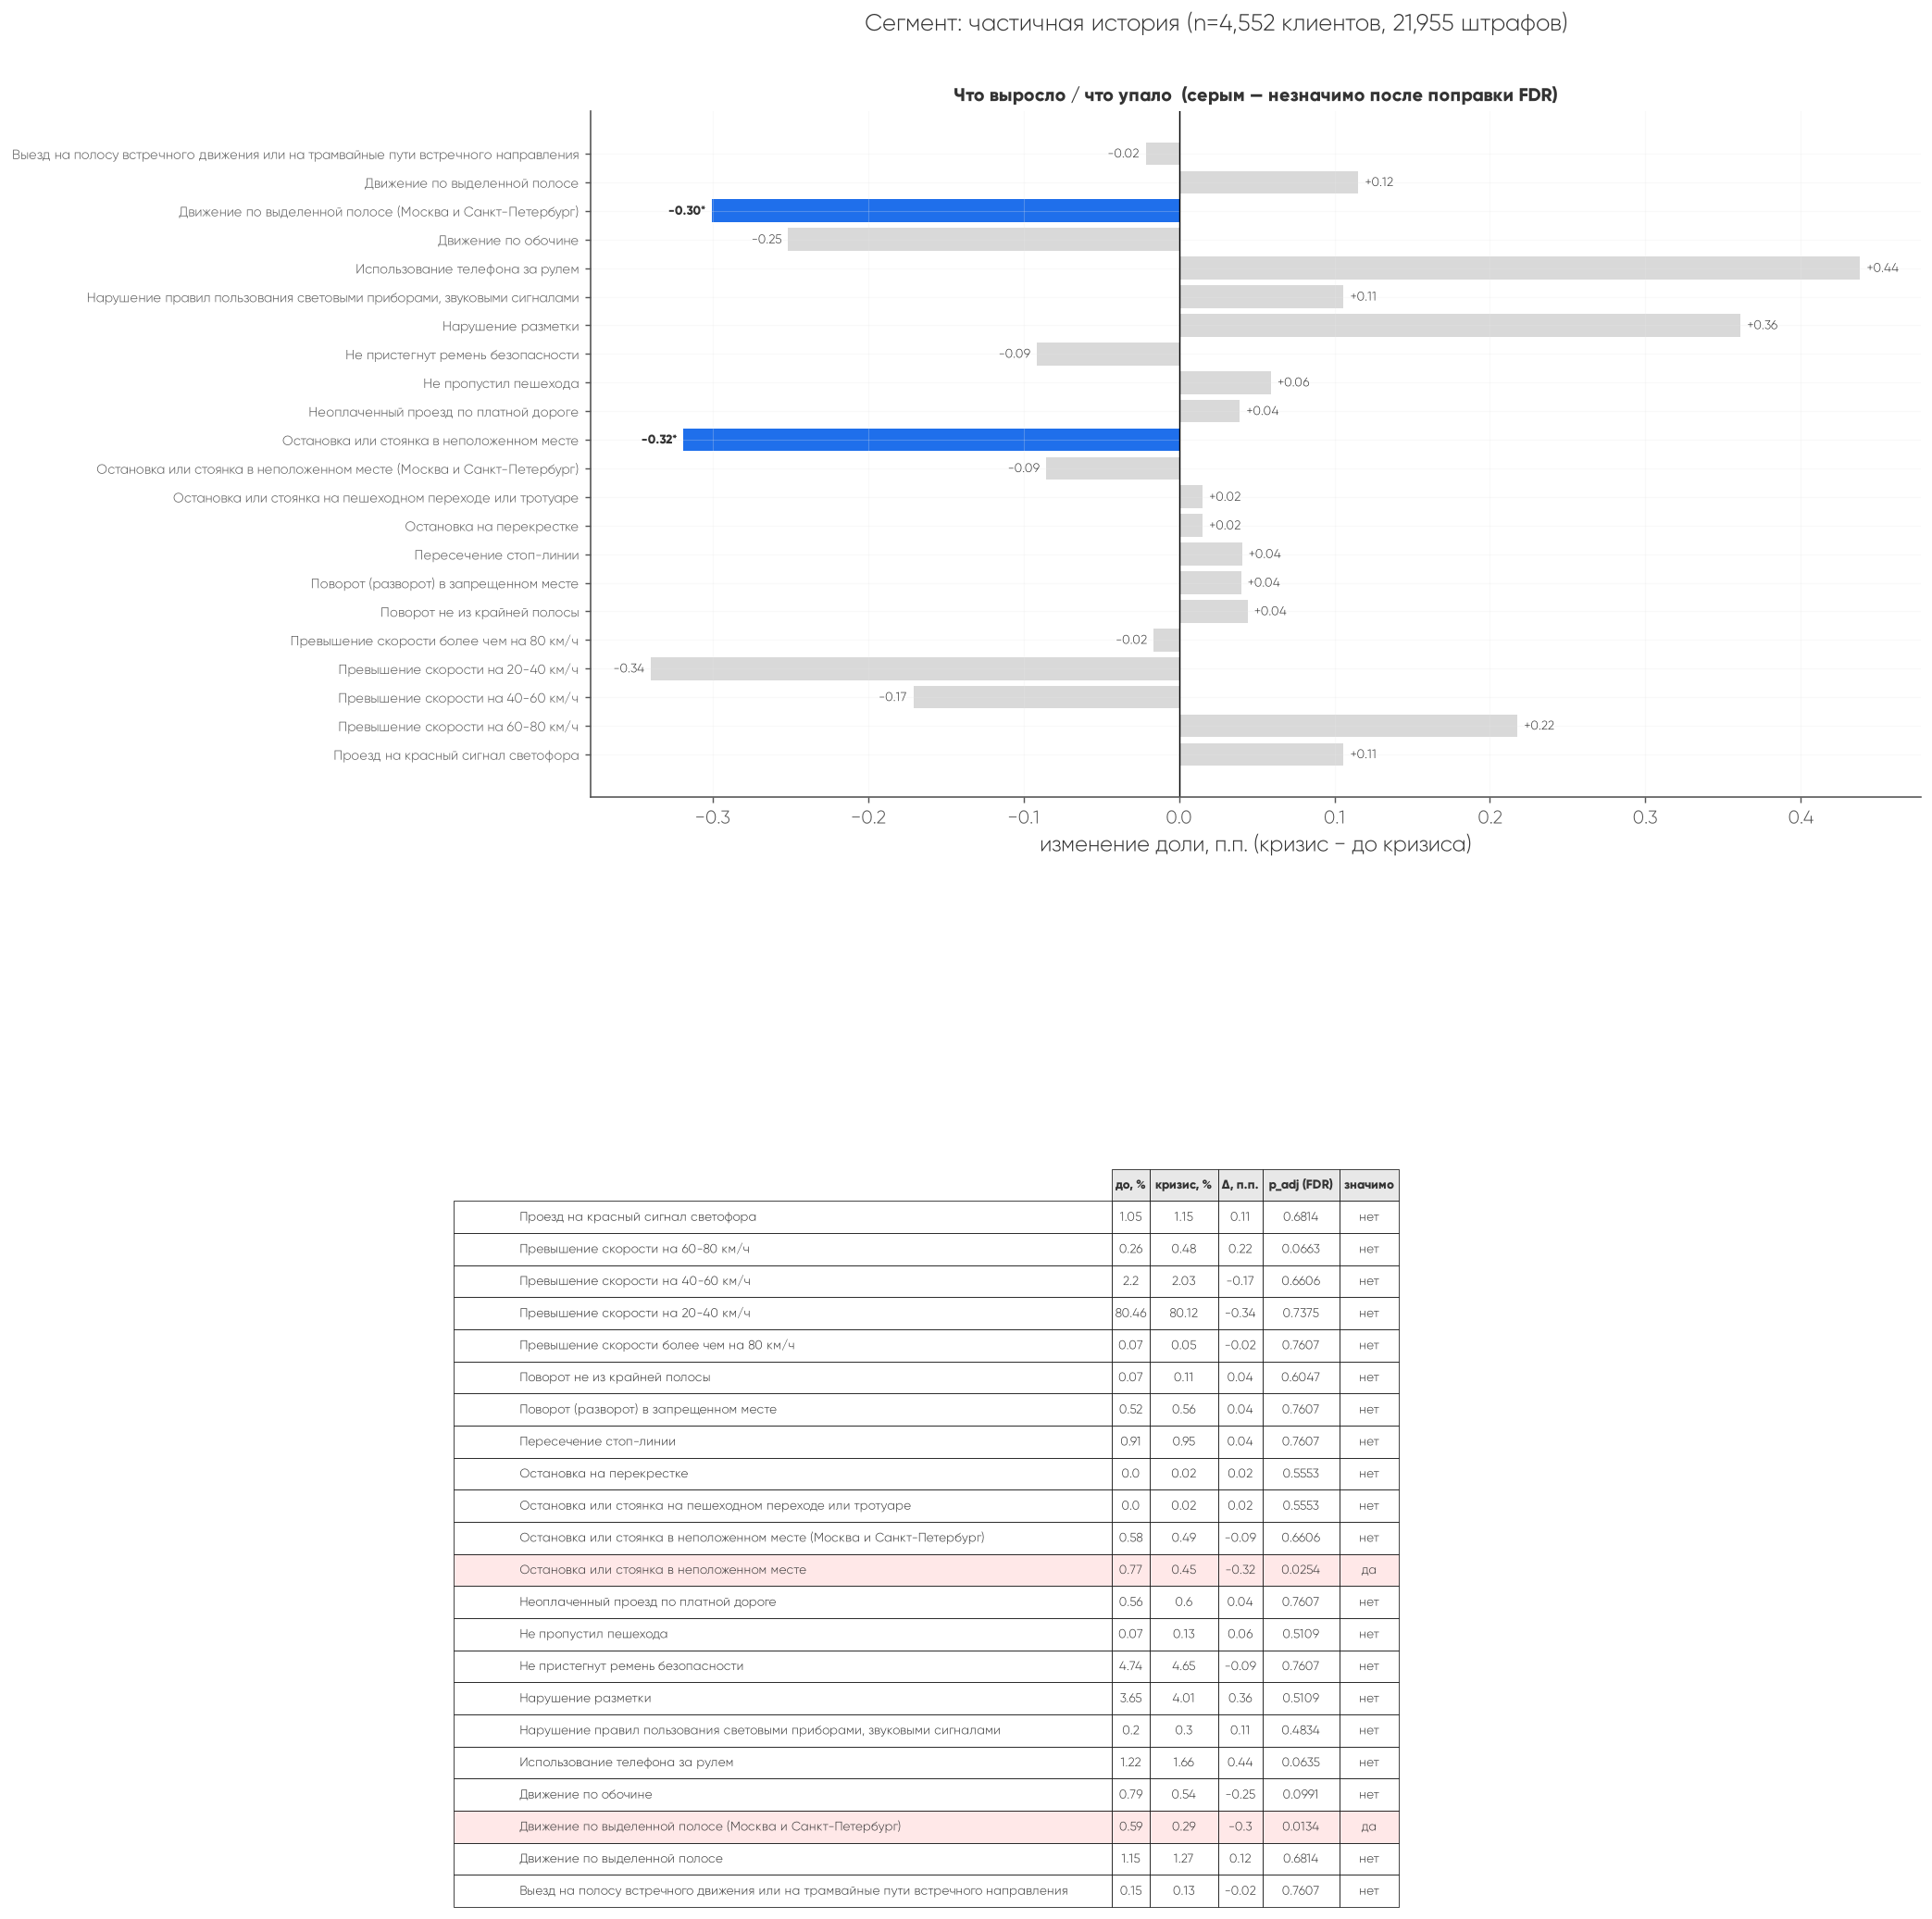

частичная история: общий хи-квадрат chi2=52.2, p=1.81e-04; значимых типов: 2 из 22


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['сегмент'] = cl.sub_date.apply(classify)

f_all = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(cl[['client_id', 'сегмент']], on='client_id', how='inner')
f_all['период'] = np.where(f_all.bill_offence_date.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-авг)')

for seg in ['полная история', 'частичная история']:
    f = f_all[f_all.сегмент == seg]
    n = f.client_id.nunique()

    ct = pd.crosstab(f.offence_short_statement, f.период, normalize='columns') * 100
    ct['разница_пп'] = ct['кризис (июн-авг)'] - ct['до кризиса (апр-май)']

    counts = pd.crosstab(f.offence_short_statement, f.период)
    n_pre, n_post = counts['до кризиса (апр-май)'].sum(), counts['кризис (июн-авг)'].sum()

    pvals = []
    for typ in counts.index:
        k = np.array([counts.loc[typ, 'кризис (июн-авг)'], counts.loc[typ, 'до кризиса (апр-май)']])
        nobs = np.array([n_post, n_pre])
        _, pv = proportions_ztest(k, nobs)
        pvals.append(pv)
    counts['p_value'] = pvals
    counts['p_adj'] = multipletests(counts.p_value, method='fdr_bh')[1]
    counts['значимо'] = counts.p_adj < 0.05

    ct = ct.join(counts[['p_value', 'p_adj', 'значимо']])
    ct = ct.sort_index(ascending=False)

    # --- единая фигура: явное позиционирование осей через add_axes, с большим отступом между блоками
    fig = plt.figure(figsize=(13, 15))
    fig.suptitle(f'Сегмент: {seg} (n={n:,} клиентов, {len(f):,} штрафов)', fontsize=14, y=0.985)

    ax_bar = fig.add_axes([0.10, 0.55, 0.85, 0.38])   # верхний блок — график
    ax_tab = fig.add_axes([0.10, 0.05, 0.85, 0.30])   # нижний блок — таблица, большой отступ от графика
    ax_tab.axis('off')

    y = np.arange(len(ct))
    colors = [(RED if v > 0 else BLUE) if sig else '#D9D9D9' for v, sig in zip(ct['разница_пп'], ct['значимо'])]
    ax_bar.barh(y, ct['разница_пп'], color=colors)
    ax_bar.set_yticks(y); ax_bar.set_yticklabels(ct.index, fontsize=8)
    ax_bar.axvline(0, color='k', lw=.8)
    ax_bar.set_xlabel('изменение доли, п.п. (кризис − до кризиса)')
    ax_bar.set_title('Что выросло / что упало  (серым — незначимо после поправки FDR)', fontsize=11)
    for i, (v, sig) in enumerate(zip(ct['разница_пп'], ct['значимо'])):
        mark = '*' if sig else ''
        ax_bar.annotate(f'{v:+.2f}{mark}', (v, i), xytext=(4 if v > 0 else -4, 0), textcoords='offset points',
                        va='center', ha='left' if v > 0 else 'right', fontsize=7.5,
                        fontweight='bold' if sig else 'normal')

    # --- таблица под графиком
    tab_data = ct[['до кризиса (апр-май)', 'кризис (июн-авг)', 'разница_пп', 'p_adj', 'значимо']].copy()
    tab_data = tab_data.round({'до кризиса (апр-май)': 2, 'кризис (июн-авг)': 2, 'разница_пп': 2, 'p_adj': 4})
    tab_data['значимо'] = tab_data['значимо'].map({True: 'да', False: 'нет'})
    tab_data.columns = ['до, %', 'кризис, %', 'Δ, п.п.', 'p_adj (FDR)', 'значимо']

    table = ax_tab.table(cellText=tab_data.values, rowLabels=tab_data.index, colLabels=tab_data.columns,
                         cellLoc='center', rowLoc='left', loc='upper center')
    table.auto_set_font_size(False)
    table.set_fontsize(7.5)
    table.scale(1, 1.6)
    table.auto_set_column_width(col=list(range(len(tab_data.columns))))

    for i, sig in enumerate(tab_data['значимо']):
        color = '#FFE8E8' if sig == 'да' else '#FFFFFF'
        for j in range(-1, len(tab_data.columns)):
            table[(i + 1, j)].set_facecolor(color)
    for j in range(len(tab_data.columns)):   # без -1: у заголовка нет ячейки для колонки row-labels
        table[(0, j)].set_facecolor('#E8E8E8')
        table[(0, j)].set_text_props(fontweight='bold')

    plt.show()

    chi2, pv_all, _, _ = stats.chi2_contingency(pd.crosstab(f.offence_short_statement, f.период))
    print(f'{seg}: общий хи-квадрат chi2={chi2:.1f}, p={pv_all:.2e}; значимых типов: {(tab_data["значимо"]=="да").sum()} из {len(tab_data)}')

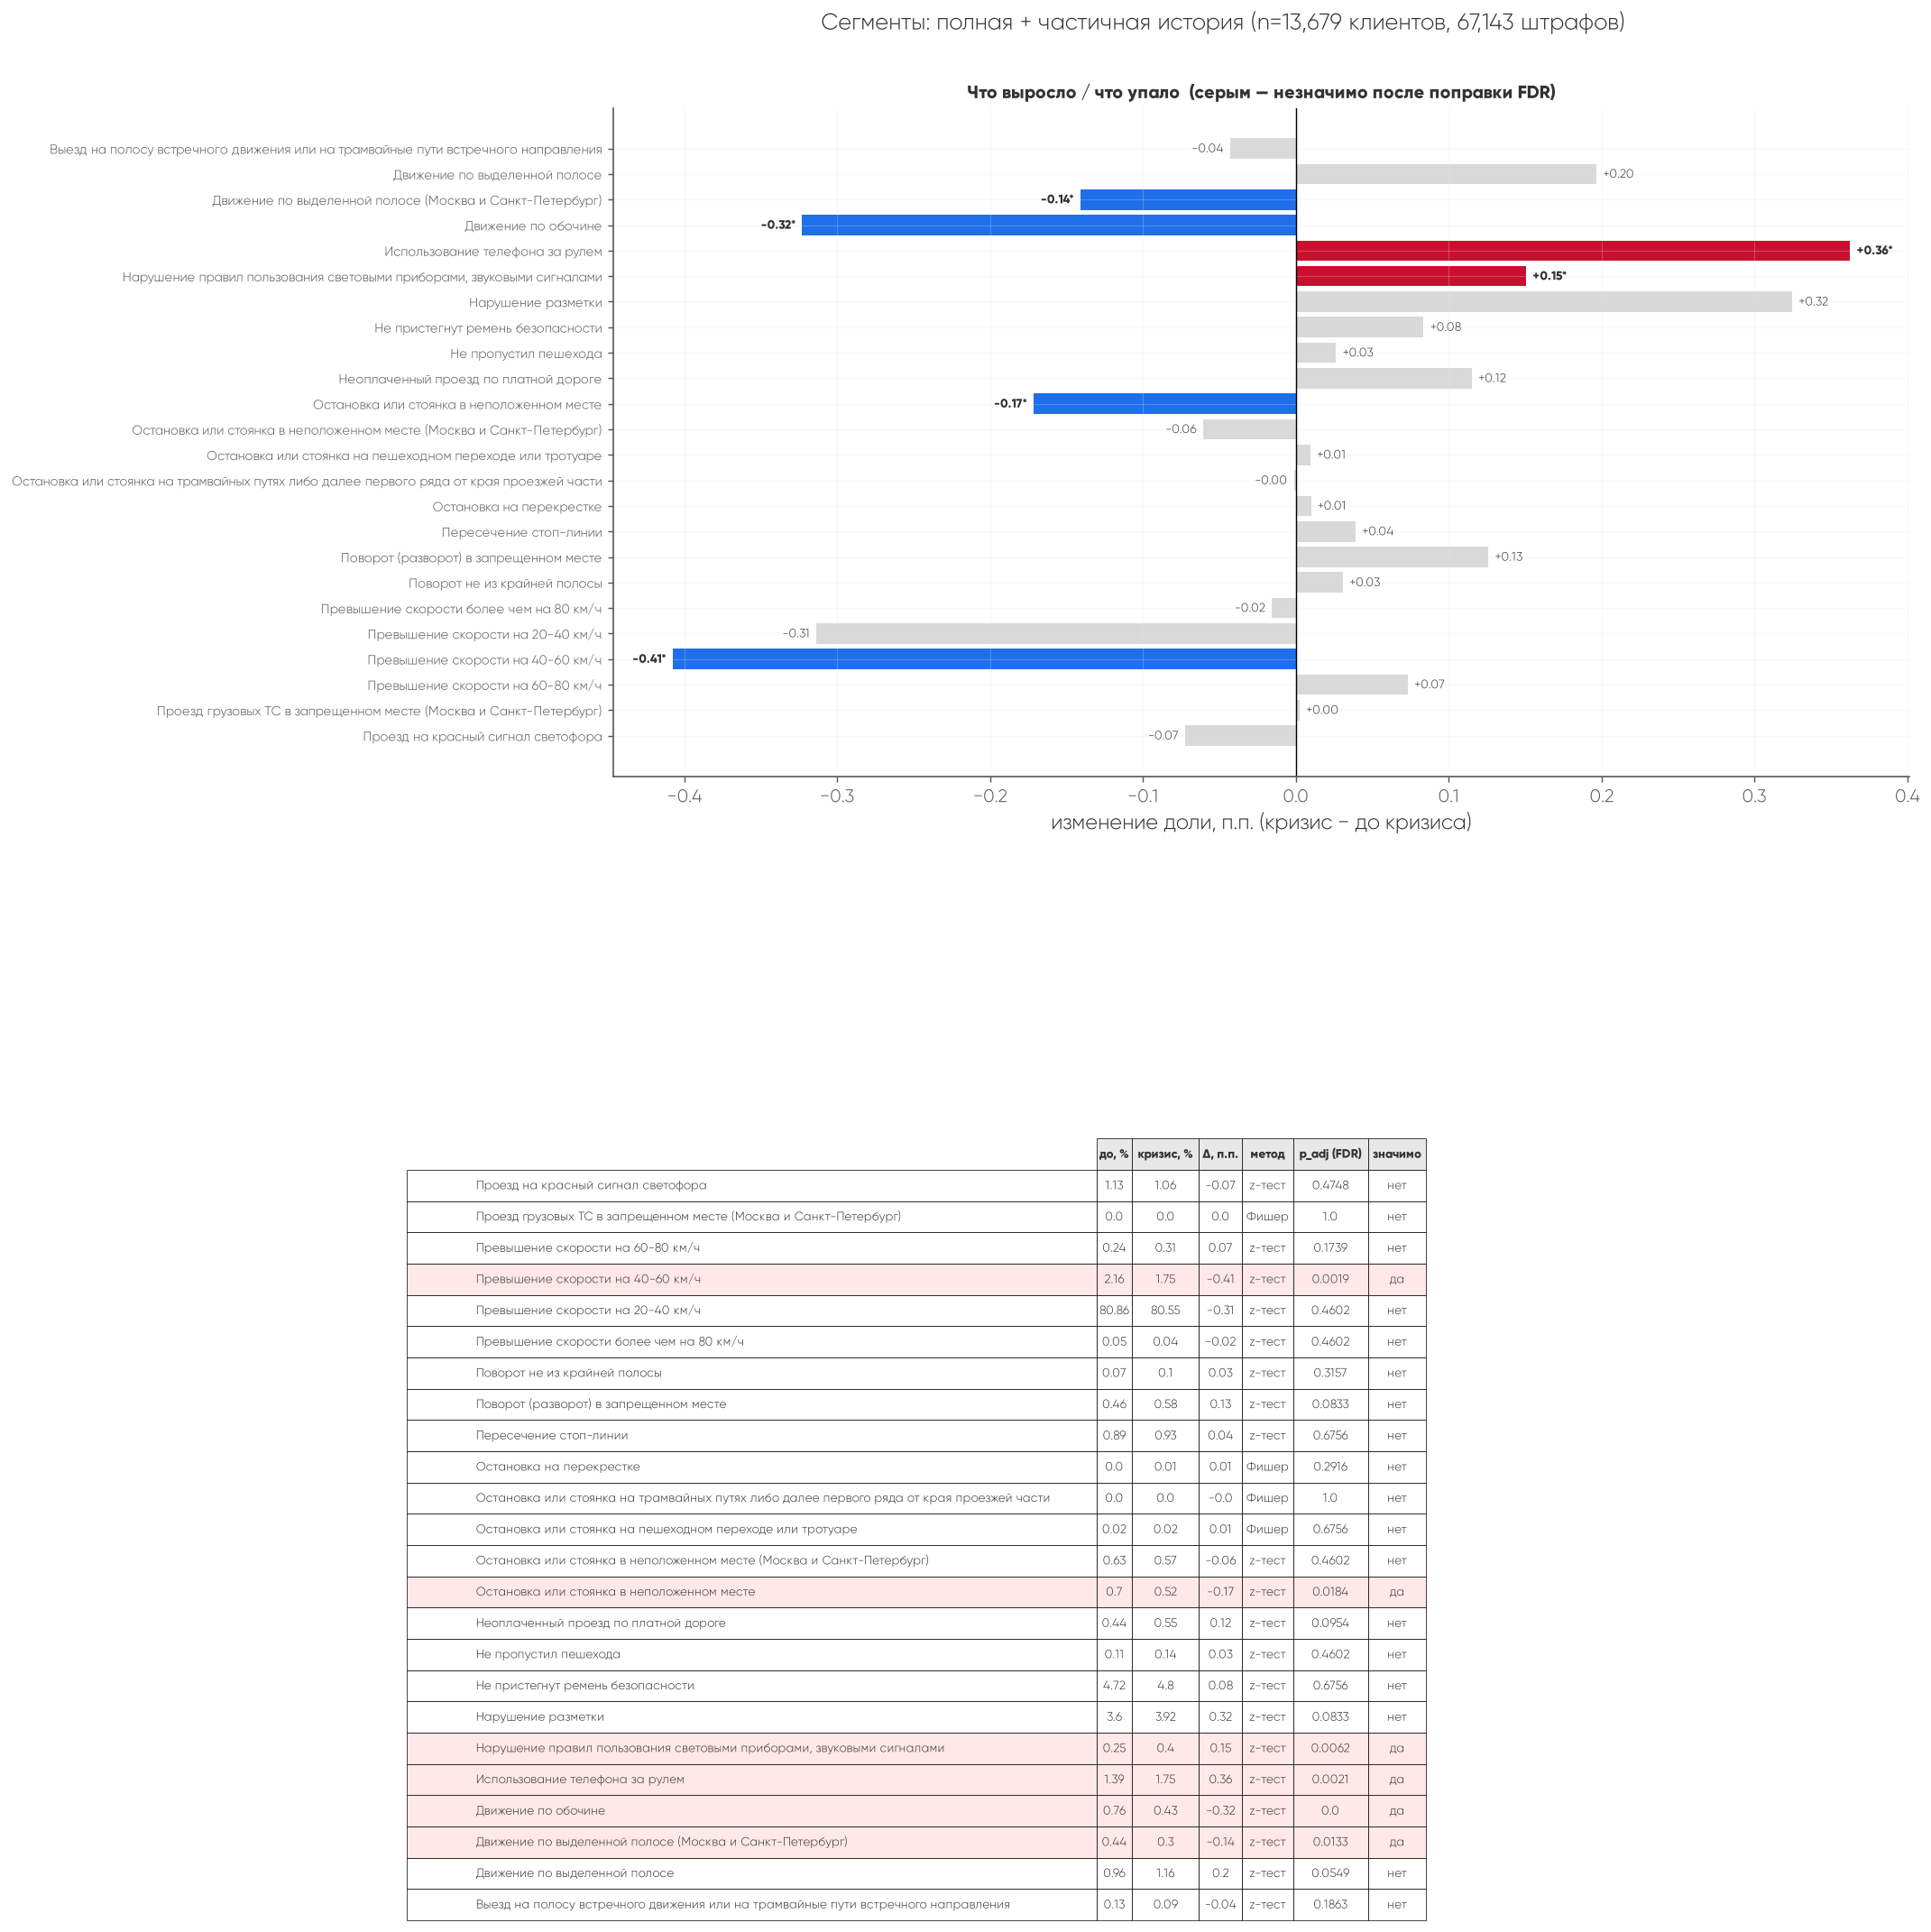

Полная + частичная история: общий хи-квадрат chi2=119.8, p=4.56e-15
Значимых типов (после FDR): 6 из 24
                                                    до, %  кризис, %  Δ, п.п.   метод  p_adj (FDR) значимо
offence_short_statement                                                                                   
Движение по обочине                                  0.76       0.43    -0.32  z-тест       0.0000      да
Превышение скорости на 40-60 км/ч                    2.16       1.75    -0.41  z-тест       0.0019      да
Использование телефона за рулем                      1.39       1.75     0.36  z-тест       0.0021      да
Нарушение правил пользования световыми приборам...   0.25       0.40     0.15  z-тест       0.0062      да
Движение по выделенной полосе (Москва и Санкт-П...   0.44       0.30    -0.14  z-тест       0.0133      да
Остановка или стоянка в неположенном месте           0.70       0.52    -0.17  z-тест       0.0184      да
Движение по выделенной полосе           

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .25,
                     'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREY = '#1F6FEB', '#C8102E', '#9AA0A6'

fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['сегмент'] = cl.sub_date.apply(classify)

f_all = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(cl[['client_id', 'сегмент']], on='client_id', how='inner')
f_all['период'] = np.where(f_all.bill_offence_date.dt.month <= 5, 'до кризиса (апр-май)', 'кризис (июн-авг)')

# --- объединяем "полная история" + "частичная история"
f = f_all[f_all.сегмент.isin(['полная история', 'частичная история'])]
n = f.client_id.nunique()

ct = pd.crosstab(f.offence_short_statement, f.период, normalize='columns') * 100
ct['разница_пп'] = ct['кризис (июн-авг)'] - ct['до кризиса (апр-май)']

counts = pd.crosstab(f.offence_short_statement, f.период)
n_pre, n_post = counts['до кризиса (апр-май)'].sum(), counts['кризис (июн-авг)'].sum()

pvals, methods = [], []
for typ in counts.index:
    k_post = counts.loc[typ, 'кризис (июн-авг)']
    k_pre = counts.loc[typ, 'до кризиса (апр-май)']
    # для малых частот (<5 в любой из групп) — точный тест Фишера вместо z-теста
    if min(k_post, k_pre) < 5:
        table2x2 = [[k_post, n_post - k_post], [k_pre, n_pre - k_pre]]
        _, pv = stats.fisher_exact(table2x2)
        methods.append('Фишер')
    else:
        k = np.array([k_post, k_pre])
        nobs = np.array([n_post, n_pre])
        _, pv = proportions_ztest(k, nobs)
        methods.append('z-тест')
    pvals.append(pv)

counts['p_value'] = pvals
counts['метод'] = methods
counts['p_adj'] = multipletests(counts.p_value, method='fdr_bh')[1]
counts['значимо'] = counts.p_adj < 0.05

ct = ct.join(counts[['p_value', 'метод', 'p_adj', 'значимо']])
ct = ct.sort_index(ascending=False)

# --- единая фигура: график сверху, таблица снизу с большим отступом
fig = plt.figure(figsize=(13, 15))
fig.suptitle(f'Сегменты: полная + частичная история (n={n:,} клиентов, {len(f):,} штрафов)', fontsize=14, y=0.985)

ax_bar = fig.add_axes([0.10, 0.55, 0.85, 0.38])
ax_tab = fig.add_axes([0.10, 0.05, 0.85, 0.30])
ax_tab.axis('off')

y = np.arange(len(ct))
colors = [(RED if v > 0 else BLUE) if sig else '#D9D9D9' for v, sig in zip(ct['разница_пп'], ct['значимо'])]
ax_bar.barh(y, ct['разница_пп'], color=colors)
ax_bar.set_yticks(y); ax_bar.set_yticklabels(ct.index, fontsize=8)
ax_bar.axvline(0, color='k', lw=.8)
ax_bar.set_xlabel('изменение доли, п.п. (кризис − до кризиса)')
ax_bar.set_title('Что выросло / что упало  (серым — незначимо после поправки FDR)', fontsize=11)
for i, (v, sig) in enumerate(zip(ct['разница_пп'], ct['значимо'])):
    mark = '*' if sig else ''
    ax_bar.annotate(f'{v:+.2f}{mark}', (v, i), xytext=(4 if v > 0 else -4, 0), textcoords='offset points',
                    va='center', ha='left' if v > 0 else 'right', fontsize=7.5,
                    fontweight='bold' if sig else 'normal')

tab_data = ct[['до кризиса (апр-май)', 'кризис (июн-авг)', 'разница_пп', 'метод', 'p_adj', 'значимо']].copy()
tab_data = tab_data.round({'до кризиса (апр-май)': 2, 'кризис (июн-авг)': 2, 'разница_пп': 2, 'p_adj': 4})
tab_data['значимо'] = tab_data['значимо'].map({True: 'да', False: 'нет'})
tab_data.columns = ['до, %', 'кризис, %', 'Δ, п.п.', 'метод', 'p_adj (FDR)', 'значимо']

table = ax_tab.table(cellText=tab_data.values, rowLabels=tab_data.index, colLabels=tab_data.columns,
                     cellLoc='center', rowLoc='left', loc='upper center')
table.auto_set_font_size(False)
table.set_fontsize(7.5)
table.scale(1, 1.6)
table.auto_set_column_width(col=list(range(len(tab_data.columns))))

for i, sig in enumerate(tab_data['значимо']):
    color = '#FFE8E8' if sig == 'да' else '#FFFFFF'
    for j in range(-1, len(tab_data.columns)):
        table[(i + 1, j)].set_facecolor(color)
for j in range(len(tab_data.columns)):
    table[(0, j)].set_facecolor('#E8E8E8')
    table[(0, j)].set_text_props(fontweight='bold')

plt.show()

chi2, pv_all, _, _ = stats.chi2_contingency(pd.crosstab(f.offence_short_statement, f.период))
print(f'Полная + частичная история: общий хи-квадрат chi2={chi2:.1f}, p={pv_all:.2e}')
print(f'Значимых типов (после FDR): {(tab_data["значимо"]=="да").sum()} из {len(tab_data)}')
print(tab_data.sort_values('p_adj (FDR)'))


In [40]:
pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pingouin]
Note: you may need to restart the kernel to use updated packages.


In [41]:
import numpy as np
import pandas as pd
import pingouin as pg
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from scipy import stats

fines['bill_offence_date'] = pd.to_datetime(fines.bill_offence_date)
clients['sub_date'] = pd.to_datetime(clients.subscription_creation_date)

cl = clients.drop_duplicates('client_id')[['client_id', 'sub_date']].copy()

def classify(sd):
    if sd < pd.Timestamp('2025-04-01'):
        return 'полная история'
    elif sd < pd.Timestamp('2026-04-01'):
        return 'частичная история'
    else:
        return 'без истории'

cl['сегмент'] = cl.sub_date.apply(classify)

f = fines[fines.bill_offence_date.dt.month.between(4, 8)].merge(cl[['client_id', 'сегмент']], on='client_id', how='inner')
f['период'] = np.where(f.bill_offence_date.dt.month <= 5, 'до_кризиса', 'кризис')

# число штрафов на клиента в каждом периоде, включая клиентов с 0 штрафами
grid = pd.MultiIndex.from_product([cl.client_id, ['до_кризиса', 'кризис']], names=['client_id', 'период']).to_frame(index=False)
cnt = f.groupby(['client_id', 'период']).size().rename('fines_n').reset_index()
d = grid.merge(cnt, on=['client_id', 'период'], how='left').fillna({'fines_n': 0})
d = d.merge(cl[['client_id', 'сегмент']], on='client_id')

print('средние по ячейкам (сегмент x период):')
print(d.groupby(['сегмент', 'период']).fines_n.mean().unstack().round(3))

# --- двухфакторный ANOVA (Type II): период x сегмент + взаимодействие
model = ols('fines_n ~ C(период) + C(сегмент) + C(период):C(сегмент)', data=d).fit()
table = anova_lm(model, typ=2)
print('\n=== Двухфакторный ANOVA ===')
print(table.round(5))

# --- проверка допущений
groups = [g.fines_n.values for _, g in d.groupby(['сегмент', 'период'])]
lev = stats.levene(*groups)
print(f'\nТест Левена (гомогенность дисперсий): p={lev.pvalue:.2e}')

# --- Welch ANOVA (устойчив к неравным дисперсиям) + post-hoc Games-Howell
aov_w = pg.welch_anova(data=d, dv='fines_n', between='сегмент')
print('\n=== Welch ANOVA по сегментам ===')
print(aov_w)

gh = pg.pairwise_gameshowell(data=d, dv='fines_n', between='сегмент')
print('\n=== Post-hoc Games-Howell (попарно) ===')
print(gh[['A', 'B', 'mean_A', 'mean_B', 'diff', 'pval']].round(4))

средние по ячейкам (сегмент x период):
период             до_кризиса  кризис
сегмент                              
без истории             0.744   1.688
полная история          1.193   1.823
частичная история       1.047   1.599

=== Двухфакторный ANOVA ===
                            sum_sq       df          F   PR(>F)
C(период)               5162.04403      1.0  566.08322  0.00000
C(сегмент)               584.85894      2.0   32.06858  0.00000
C(период):C(сегмент)     142.95514      2.0    7.83842  0.00039
Residual              468199.68754  51344.0        NaN      NaN

Тест Левена (гомогенность дисперсий): p=3.01e-147

=== Welch ANOVA по сегментам ===
    Source  ddof1         ddof2          F         p_unc       np2
0  сегмент      2  13048.383899  32.039538  1.316620e-14  0.001234

=== Post-hoc Games-Howell (попарно) ===
                A                  B  mean_A  mean_B    diff    pval
0     без истории     полная история  1.2157  1.5076 -0.2919  0.0000
1     без истории  части